In [3]:
# ============================================================
# 中文字体设置
# 目的：
# 让 Matplotlib 在 Windows 下正常显示中文
# ============================================================

import matplotlib.pyplot as plt
from matplotlib import font_manager

# Windows 微软雅黑字体路径
font_path = r"C:\Windows\Fonts\msyh.ttc"

# 创建中文字体对象
chinese_font = font_manager.FontProperties(
    fname=font_path
)

# 设置 Matplotlib 默认字体
plt.rcParams["font.family"] = chinese_font.get_name()

# 避免负号显示成方框
plt.rcParams["axes.unicode_minus"] = False

print("当前中文字体：", chinese_font.get_name())

当前中文字体： Microsoft YaHei


In [4]:
# ============================================================
# 0. 项目环境检查
# 目的：
# 1. 确认当前 Notebook 使用的是 Python 3.13
# 2. 确认数据分析和机器学习所需的核心库可以正常导入
# 3. 查看当前项目的工作目录
# ============================================================

import sys
import os

import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
import matplotlib
import seaborn as sns

# 查看 Python 版本
print("Python 版本：")
print(sys.version)

# 查看主要第三方库版本
print("\n主要库版本：")
print("NumPy：", np.__version__)
print("Pandas：", pd.__version__)
print("Scikit-learn：", sklearn.__version__)
print("XGBoost：", xgb.__version__)
print("Matplotlib：", matplotlib.__version__)
print("Seaborn：", sns.__version__)

# 查看 Notebook 当前工作目录
print("\n当前工作目录：")
print(os.getcwd())

print("\n✅ 项目环境检查完成")

Python 版本：
3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]

主要库版本：
NumPy： 2.5.3
Pandas： 3.0.6
Scikit-learn： 1.9.1
XGBoost： 3.4.1
Matplotlib： 3.11.2
Seaborn： 0.13.2

当前工作目录：
d:\桌面\天猫复购预测\TMALL_Repurchase

✅ 项目环境检查完成


In [5]:
# ============================================================
# 1. 查看项目目录结构
# 目的：
# 先确认 data 和 feature 文件夹中已经有哪些文件，
# 避免直接运行原教程时因为缺文件而报错。
# ============================================================

from pathlib import Path

# 当前项目根目录
project_dir = Path.cwd()

# 需要重点检查的文件夹
folders = ["data", "feature", "model", "images"]

for folder_name in folders:
    folder_path = project_dir / folder_name

    print(f"\n{'=' * 60}")
    print(f"📁 {folder_name}")
    print("=" * 60)

    if not folder_path.exists():
        print("❌ 文件夹不存在")
        continue

    files = list(folder_path.iterdir())

    if len(files) == 0:
        print("⚠️ 文件夹为空")
        continue

    for file in files:
        # 如果是文件，同时显示文件大小
        if file.is_file():
            size_mb = file.stat().st_size / 1024 / 1024
            print(f"{file.name:<50} {size_mb:>10.2f} MB")
        else:
            print(f"[文件夹] {file.name}")


📁 data
[文件夹] data_format1
sample_submission.csv                                    4.12 MB
submission_0101_stack_lr_138iter.csv                     8.18 MB
submission_0130_randomforest_maxdepth14_133trees_entropy_14features.csv       8.15 MB
submission_0131_adaboost_n50_lr1.csv                     8.32 MB
submission_0131_stack_lr_138iter.csv                     8.24 MB
submission_0131_stack_perceptron_alpha0.0001_1000iter.csv       8.25 MB
submission_1228.csv                                      8.14 MB
submission_1229_adaboost_n50_lr1.csv                     7.96 MB
submission_1229_LinearSVC.csv                            8.14 MB
submission_1229_logireg.csv                              8.14 MB
submission_1229_mlp_adam_700nodes.csv                    8.39 MB
submission_1229_mlp_sgd_700nodes.csv                     8.16 MB
submission_1229_randomforest_maxdepth8_100trees.csv       8.14 MB
submission_1230_xgboost_n100_maxdepth8_lr0.1.csv         5.99 MB
submission_1231_logireg.csv       

In [6]:
# ============================================================
# 2. 单独查看核心数据文件
# 目的：
# 只检查真正与项目分析有关的两个目录：
# 1. data/data_format1：原始比赛数据
# 2. feature：作者已经生成好的特征数据
# 避免被大量 submission 文件干扰
# ============================================================

from pathlib import Path

project_dir = Path.cwd()

# 原始数据目录
raw_data_dir = project_dir / "data" / "data_format1"

# 特征数据目录
feature_dir = project_dir / "feature"


def show_files(folder_path, folder_name):
    """打印指定文件夹中的文件名、大小和文件类型"""

    print("\n" + "=" * 70)
    print(f"📁 {folder_name}")
    print("=" * 70)

    if not folder_path.exists():
        print("❌ 文件夹不存在")
        return

    files = sorted(folder_path.iterdir())

    if not files:
        print("⚠️ 文件夹为空")
        return

    for file in files:
        if file.is_file():
            size_mb = file.stat().st_size / 1024 / 1024

            print(
                f"{file.name:<55}"
                f"{size_mb:>10.2f} MB"
            )
        else:
            print(f"[文件夹] {file.name}")


# 查看原始数据
show_files(
    raw_data_dir,
    "data/data_format1 —— 原始比赛数据"
)

# 查看作者生成的特征
show_files(
    feature_dir,
    "feature —— 已生成特征"
)


📁 data/data_format1 —— 原始比赛数据
brand_id_value_counts.csv                                    0.10 MB
cat_id_value_counts.csv                                      0.02 MB
item_id_value_counts.csv                                    10.96 MB
seller_id_value_counts.csv                                   0.05 MB
test_format1.csv                                             3.38 MB
test_format2.csv                                           733.05 MB
train_format1.csv                                            3.62 MB
train_format2.csv                                          731.89 MB
user_id_value_counts.csv                                     4.50 MB
user_info_format1.csv                                        6.34 MB
user_log_format1.csv                                      1954.25 MB
user_log_format1_1.csv                                    1314.22 MB
user_log_format1_2.csv                                    1100.86 MB
user_log_format1_samples.csv                                 0.04 MB

📁 

In [7]:
# ============================================================
# 3. 检查两份用户行为日志分片
# 目的：
# 1. 确认两个文件都放在正确位置
# 2. 检查字段是否一致
# 3. 查看前几行数据，确认数据结构
# 4. 在真正合并前避免格式问题
# ============================================================

from pathlib import Path
import pandas as pd

# 原始数据所在目录
data_dir = Path("data/data_format1")

# 两份行为日志分片
file_1 = data_dir / "user_log_format1_1.csv"
file_2 = data_dir / "user_log_format1_2.csv"

# 检查文件是否存在
print("文件 1 是否存在：", file_1.exists())
print("文件 2 是否存在：", file_2.exists())

# 查看文件大小
if file_1.exists():
    print(
        "文件 1 大小：",
        round(file_1.stat().st_size / 1024 / 1024 / 1024, 2),
        "GB"
    )

if file_2.exists():
    print(
        "文件 2 大小：",
        round(file_2.stat().st_size / 1024 / 1024 / 1024, 2),
        "GB"
    )

# 只读取前 5 行，不会把整个大文件载入内存
sample_1 = pd.read_csv(file_1, nrows=5)
sample_2 = pd.read_csv(file_2, nrows=5)

print("\n================ 文件 1 ================")
display(sample_1)

print("\n文件 1 字段：")
print(sample_1.columns.tolist())

print("\n================ 文件 2 ================")
display(sample_2)

print("\n文件 2 字段：")
print(sample_2.columns.tolist())

# 检查两个文件字段是否完全一致
print("\n两份文件字段是否一致：")
print(sample_1.columns.tolist() == sample_2.columns.tolist())

文件 1 是否存在： True
文件 2 是否存在： True
文件 1 大小： 1.28 GB
文件 2 大小： 1.08 GB

================ 文件 1 ================


,Unnamed: 0,user_id,item_id,cat_id,seller_id,brand_id,time_stamp,action_type
0,0,328862,323294,833,2882,2661.0,829,0
1,1,328862,844400,1271,2882,2661.0,829,0
2,2,328862,575153,1271,2882,2661.0,829,0
3,3,328862,996875,1271,2882,2661.0,829,0
4,4,328862,1086186,1271,1253,1049.0,829,0



文件 1 字段：
['Unnamed: 0', 'user_id', 'item_id', 'cat_id', 'seller_id', 'brand_id', 'time_stamp', 'action_type']

================ 文件 2 ================


,Unnamed: 0,user_id,item_id,cat_id,seller_id,brand_id,time_stamp,action_type
0,30000000,284456,167191,692,2011,1287.0,713,0
1,30000001,284456,330306,1438,1418,7141.0,713,0
2,30000002,284456,239397,1438,2877,7141.0,713,0
3,30000003,284456,323284,142,2266,8102.0,630,0
4,30000004,284456,2956,407,3255,7141.0,630,0



文件 2 字段：
['Unnamed: 0', 'user_id', 'item_id', 'cat_id', 'seller_id', 'brand_id', 'time_stamp', 'action_type']

两份文件字段是否一致：
True


In [8]:
# ============================================================
# 4. 合并两份用户行为日志
#
# 目的：
# 1. 将 user_log_format1_1.csv 和 user_log_format1_2.csv
#    合并成完整的 user_log_format1.csv
# 2. 删除无业务意义的 "Unnamed: 0" 索引列
# 3. 使用分块读取，避免一次性读取 5000 多万行导致内存不足
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 1. 设置文件路径
# ------------------------------------------------------------

data_dir = Path("data/data_format1")

input_files = [
    data_dir / "user_log_format1_1.csv",
    data_dir / "user_log_format1_2.csv"
]

output_file = data_dir / "user_log_format1.csv"


# ------------------------------------------------------------
# 2. 设置每次读取的数据量
# ------------------------------------------------------------
# 每次读取 100 万行。
# 这样不会把 5000 多万行一次性全部加载进内存。

chunk_size = 1_000_000


# ------------------------------------------------------------
# 3. 指定字段的数据类型
# ------------------------------------------------------------
# 使用较小的数据类型可以明显降低内存占用。

dtype_dict = {
    "user_id": "int32",
    "item_id": "int32",
    "cat_id": "int32",
    "seller_id": "int32",
    "brand_id": "float32",   # brand_id 存在缺失值，因此暂时使用 float
    "time_stamp": "int16",
    "action_type": "int8"
}


# ------------------------------------------------------------
# 4. 如果之前生成过不完整文件，先删除
# ------------------------------------------------------------

if output_file.exists():
    output_file.unlink()
    print("⚠️ 已删除之前存在的 user_log_format1.csv")


# ------------------------------------------------------------
# 5. 开始分块合并
# ------------------------------------------------------------

total_rows = 0
first_chunk = True

for file_number, input_file in enumerate(input_files, start=1):

    print("\n" + "=" * 70)
    print(f"开始处理文件 {file_number}：{input_file.name}")
    print("=" * 70)

    # 分块读取 CSV
    reader = pd.read_csv(
        input_file,
        chunksize=chunk_size,
        dtype=dtype_dict
    )

    for chunk_number, chunk in enumerate(reader, start=1):

        # 删除 CSV 中无业务意义的旧索引列
        if "Unnamed: 0" in chunk.columns:
            chunk = chunk.drop(columns=["Unnamed: 0"])

        # 将当前数据块追加写入最终文件
        chunk.to_csv(
            output_file,
            mode="w" if first_chunk else "a",
            header=first_chunk,
            index=False
        )

        # 第一块之后，后续数据不再写表头
        first_chunk = False

        # 统计已经处理的总行数
        total_rows += len(chunk)

        print(
            f"文件 {file_number} - 第 {chunk_number} 块完成，"
            f"累计处理：{total_rows:,} 行"
        )


# ------------------------------------------------------------
# 6. 输出合并结果
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ 用户行为日志合并完成")
print("=" * 70)

print(f"总行数：{total_rows:,}")

print(
    "文件大小：",
    round(output_file.stat().st_size / 1024 / 1024 / 1024, 2),
    "GB"
)

print("生成文件：")
print(output_file)

⚠️ 已删除之前存在的 user_log_format1.csv

开始处理文件 1：user_log_format1_1.csv
文件 1 - 第 1 块完成，累计处理：1,000,000 行
文件 1 - 第 2 块完成，累计处理：2,000,000 行
文件 1 - 第 3 块完成，累计处理：3,000,000 行
文件 1 - 第 4 块完成，累计处理：4,000,000 行
文件 1 - 第 5 块完成，累计处理：5,000,000 行
文件 1 - 第 6 块完成，累计处理：6,000,000 行
文件 1 - 第 7 块完成，累计处理：7,000,000 行
文件 1 - 第 8 块完成，累计处理：8,000,000 行
文件 1 - 第 9 块完成，累计处理：9,000,000 行
文件 1 - 第 10 块完成，累计处理：10,000,000 行
文件 1 - 第 11 块完成，累计处理：11,000,000 行
文件 1 - 第 12 块完成，累计处理：12,000,000 行
文件 1 - 第 13 块完成，累计处理：13,000,000 行
文件 1 - 第 14 块完成，累计处理：14,000,000 行
文件 1 - 第 15 块完成，累计处理：15,000,000 行
文件 1 - 第 16 块完成，累计处理：16,000,000 行
文件 1 - 第 17 块完成，累计处理：17,000,000 行
文件 1 - 第 18 块完成，累计处理：18,000,000 行
文件 1 - 第 19 块完成，累计处理：19,000,000 行
文件 1 - 第 20 块完成，累计处理：20,000,000 行
文件 1 - 第 21 块完成，累计处理：21,000,000 行
文件 1 - 第 22 块完成，累计处理：22,000,000 行
文件 1 - 第 23 块完成，累计处理：23,000,000 行
文件 1 - 第 24 块完成，累计处理：24,000,000 行
文件 1 - 第 25 块完成，累计处理：25,000,000 行
文件 1 - 第 26 块完成，累计处理：26,000,000 行
文件 1 - 第 27 块完成，累计处理：27,000,000 行
文件 1 - 第 28 块完成，累计处理：28,000,000 行


In [9]:
# ============================================================
# 5. 检查合并后的用户行为日志
# 目的：
# 1. 确认字段正确
# 2. 确认无多余索引列
# 3. 查看前几行数据
# ============================================================

import pandas as pd
from pathlib import Path

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

# 只读取前 10 行，不会加载整个 1.91 GB 文件
log_sample = pd.read_csv(log_file, nrows=10)

print("字段列表：")
print(log_sample.columns.tolist())

print("\n前 10 行数据：")
display(log_sample)

字段列表：
['user_id', 'item_id', 'cat_id', 'seller_id', 'brand_id', 'time_stamp', 'action_type']

前 10 行数据：


,user_id,item_id,cat_id,seller_id,brand_id,time_stamp,action_type
0,328862,323294,833,2882,2661.0,829,0
1,328862,844400,1271,2882,2661.0,829,0
2,328862,575153,1271,2882,2661.0,829,0
3,328862,996875,1271,2882,2661.0,829,0
4,328862,1086186,1271,1253,1049.0,829,0
5,328862,623866,1271,2882,2661.0,829,0
6,328862,542871,1467,2882,2661.0,829,0
7,328862,536347,1095,883,1647.0,829,0
8,328862,364513,1271,2882,2661.0,829,0
9,328862,575153,1271,2882,2661.0,829,0


In [10]:
# ============================================================
# 6. 检查 train_format2 和 test_format2 的数据结构
#
# 目的：
# 1. 确认两个官方文件读取正常
# 2. 查看训练集和测试集分别有哪些字段
# 3. 确认后续应该提取哪些字段生成 Format 1
#
# 注意：
# 这里只读取前 5 行，不会把 700 多 MB 的文件全部载入内存
# ============================================================

from pathlib import Path
import pandas as pd

# 数据目录
data_dir = Path("data/data_format1")

# 两个 Format 2 文件
train_f2_path = data_dir / "train_format2.csv"
test_f2_path = data_dir / "test_format2.csv"

# ------------------------------------------------------------
# 1. 检查文件是否存在
# ------------------------------------------------------------

print("train_format2.csv 是否存在：", train_f2_path.exists())
print("test_format2.csv 是否存在：", test_f2_path.exists())

# ------------------------------------------------------------
# 2. 查看文件大小
# ------------------------------------------------------------

if train_f2_path.exists():
    print(
        "train_format2.csv 大小：",
        round(train_f2_path.stat().st_size / 1024 / 1024, 2),
        "MB"
    )

if test_f2_path.exists():
    print(
        "test_format2.csv 大小：",
        round(test_f2_path.stat().st_size / 1024 / 1024, 2),
        "MB"
    )

# ------------------------------------------------------------
# 3. 只读取前 5 行
# ------------------------------------------------------------

train_f2_sample = pd.read_csv(
    train_f2_path,
    nrows=5
)

test_f2_sample = pd.read_csv(
    test_f2_path,
    nrows=5
)

# ------------------------------------------------------------
# 4. 查看字段
# ------------------------------------------------------------

print("\n================ 训练集字段 ================")
print(train_f2_sample.columns.tolist())

display(train_f2_sample)

print("\n================ 测试集字段 ================")
print(test_f2_sample.columns.tolist())

display(test_f2_sample)

train_format2.csv 是否存在： True
test_format2.csv 是否存在： True
train_format2.csv 大小： 731.89 MB
test_format2.csv 大小： 733.05 MB

================ 训练集字段 ================
['user_id', 'age_range', 'gender', 'merchant_id', 'label', 'activity_log']


,user_id,age_range,gender,merchant_id,label,activity_log
0,34176,6,0,944,-1,408895:1505:7370:1107:0
1,34176,6,0,412,-1,17235:1604:4396:0818:0#954723:1604:4396:0818:0...
2,34176,6,0,1945,-1,231901:662:2758:0818:0#231901:662:2758:0818:0#...
3,34176,6,0,4752,-1,174142:821:6938:1027:0
4,34176,6,0,643,-1,716371:1505:968:1024:3



================ 测试集字段 ================
['user_id', 'age_range', 'gender', 'merchant_id', 'label', 'activity_log']


,user_id,age_range,gender,merchant_id,label,activity_log
0,163968,0,0,4378,-1,101206:812:6968:0614:0
1,163968,0,0,2300,-1,588758:844:3833:0618:0#71782:844:3833:1111:2#7...
2,163968,0,0,1551,-1,312747:243:1954:0627:0#312747:243:1954:0627:0#...
3,163968,0,0,4343,-1,932390:1612:3201:0628:0
4,163968,0,0,4911,-1,957657:662:3089:0612:0


In [11]:
# ============================================================
# 7. 检查 train_format2 和 test_format2 的标签分布
#
# 目的：
# 1. 确认 label = 1 / 0 / -1 / 缺失值 各有多少行
# 2. 判断哪些记录是真正用于训练的样本
# 3. 判断哪些记录是真正需要预测的测试样本
#
# 注意：
# 只读取 user_id、merchant_id、label 三列，
# 不读取巨大的 activity_log，可以大幅降低内存占用。
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")

train_f2_path = data_dir / "train_format2.csv"
test_f2_path = data_dir / "test_format2.csv"


def inspect_label_distribution(file_path, file_name):
    """分块统计一个 Format 2 文件中的标签分布"""

    chunk_size = 100_000

    label_counts = {
        1: 0,
        0: 0,
        -1: 0,
        "缺失值": 0
    }

    total_rows = 0
    unique_pairs = set()

    reader = pd.read_csv(
        file_path,
        usecols=["user_id", "merchant_id", "label"],
        chunksize=chunk_size
    )

    for chunk in reader:

        total_rows += len(chunk)

        # 统计 1 / 0 / -1
        counts = chunk["label"].value_counts(dropna=False)

        label_counts[1] += int(counts.get(1, 0))
        label_counts[0] += int(counts.get(0, 0))
        label_counts[-1] += int(counts.get(-1, 0))
        label_counts["缺失值"] += int(chunk["label"].isna().sum())

    print("\n" + "=" * 60)
    print(file_name)
    print("=" * 60)

    print(f"总行数：{total_rows:,}")
    print(f"label = 1：{label_counts[1]:,}")
    print(f"label = 0：{label_counts[0]:,}")
    print(f"label = -1：{label_counts[-1]:,}")
    print(f"label 缺失：{label_counts['缺失值']:,}")


inspect_label_distribution(
    train_f2_path,
    "train_format2.csv"
)

inspect_label_distribution(
    test_f2_path,
    "test_format2.csv"
)


train_format2.csv
总行数：7,030,723
label = 1：15,952
label = 0：244,912
label = -1：6,769,859
label 缺失：0

test_format2.csv
总行数：7,027,943
label = 1：0
label = 0：0
label = -1：6,766,466
label 缺失：261,477


In [12]:
# ============================================================
# 8. 从 Format 2 生成 Format 1 的三张核心数据表
#
# 最终生成：
# 1. train_format1.csv
# 2. test_format1.csv
# 3. user_info_format1.csv
#
# 转换逻辑：
# train_format2：
#   label = 0 或 1 → 训练样本
#
# test_format2：
#   label 缺失 → 测试样本
#
# train + test：
#   提取 user_id、age_range、gender
#   → 去重后生成用户信息表
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 1. 文件路径
# ------------------------------------------------------------

data_dir = Path("data/data_format1")

train_f2_path = data_dir / "train_format2.csv"
test_f2_path = data_dir / "test_format2.csv"

train_f1_path = data_dir / "train_format1.csv"
test_f1_path = data_dir / "test_format1.csv"
user_info_path = data_dir / "user_info_format1.csv"


# ------------------------------------------------------------
# 2. 每次读取 50 万行
# ------------------------------------------------------------

chunk_size = 500_000


# ------------------------------------------------------------
# 3. 如果之前生成过结果文件，先删除
# 防止重复追加
# ------------------------------------------------------------

for file_path in [
    train_f1_path,
    test_f1_path,
    user_info_path
]:
    if file_path.exists():
        file_path.unlink()


# ------------------------------------------------------------
# 4. 用于暂存用户信息
#
# Format 2 中，同一个用户会对应多个商家，
# 所以用户的年龄、性别会重复出现。
#
# 我们先在每个数据块内按 user_id 去重，
# 最后再统一去重。
# ------------------------------------------------------------

user_info_parts = []


# ============================================================
# 5. 处理训练集
# ============================================================

print("=" * 70)
print("开始处理 train_format2.csv")
print("=" * 70)

train_first_chunk = True
train_rows = 0

train_reader = pd.read_csv(
    train_f2_path,

    # activity_log 非常大，这里完全不读取
    usecols=[
        "user_id",
        "age_range",
        "gender",
        "merchant_id",
        "label"
    ],

    chunksize=chunk_size
)

for chunk_number, chunk in enumerate(train_reader, start=1):

    # --------------------------------------------------------
    # 保存用户基本信息
    # --------------------------------------------------------

    user_part = (
        chunk[
            ["user_id", "age_range", "gender"]
        ]
        .drop_duplicates(subset=["user_id"])
    )

    user_info_parts.append(user_part)


    # --------------------------------------------------------
    # 训练集只保留 label = 0 或 1
    #
    # label = -1 不属于最终训练样本
    # --------------------------------------------------------

    train_chunk = chunk[
        chunk["label"].isin([0, 1])
    ][
        ["user_id", "merchant_id", "label"]
    ].copy()


    # label 现在已经没有缺失值，可以转换成整数
    train_chunk["label"] = train_chunk["label"].astype("int8")


    # --------------------------------------------------------
    # 写入 train_format1.csv
    # --------------------------------------------------------

    train_chunk.to_csv(
        train_f1_path,
        mode="w" if train_first_chunk else "a",
        header=train_first_chunk,
        index=False
    )

    train_first_chunk = False
    train_rows += len(train_chunk)

    print(
        f"训练文件第 {chunk_number} 块完成，"
        f"累计有效训练样本：{train_rows:,}"
    )


# ============================================================
# 6. 处理测试集
# ============================================================

print("\n" + "=" * 70)
print("开始处理 test_format2.csv")
print("=" * 70)

test_first_chunk = True
test_rows = 0

test_reader = pd.read_csv(
    test_f2_path,

    usecols=[
        "user_id",
        "age_range",
        "gender",
        "merchant_id",
        "label"
    ],

    chunksize=chunk_size
)

for chunk_number, chunk in enumerate(test_reader, start=1):

    # --------------------------------------------------------
    # 保存用户基本信息
    # --------------------------------------------------------

    user_part = (
        chunk[
            ["user_id", "age_range", "gender"]
        ]
        .drop_duplicates(subset=["user_id"])
    )

    user_info_parts.append(user_part)


    # --------------------------------------------------------
    # 测试集真正需要预测的是 label 缺失的记录
    # --------------------------------------------------------

    test_chunk = chunk[
        chunk["label"].isna()
    ][
        ["user_id", "merchant_id"]
    ].copy()


    # --------------------------------------------------------
    # 官方 Format 1 测试集有 prob 字段，
    # 用于后面填写模型预测概率
    #
    # 现在还没有模型结果，因此先设为空值
    # --------------------------------------------------------

    test_chunk["prob"] = float("nan")


    # --------------------------------------------------------
    # 写入 test_format1.csv
    # --------------------------------------------------------

    test_chunk.to_csv(
        test_f1_path,
        mode="w" if test_first_chunk else "a",
        header=test_first_chunk,
        index=False
    )

    test_first_chunk = False
    test_rows += len(test_chunk)

    print(
        f"测试文件第 {chunk_number} 块完成，"
        f"累计有效测试样本：{test_rows:,}"
    )


# ============================================================
# 7. 生成 user_info_format1.csv
# ============================================================

print("\n" + "=" * 70)
print("开始生成 user_info_format1.csv")
print("=" * 70)

# 合并前面各块提取出的用户信息
user_info = pd.concat(
    user_info_parts,
    ignore_index=True
)

# 同一个用户在 Format 2 中会重复出现，
# 最终每个 user_id 只保留一条记录
user_info = (
    user_info
    .drop_duplicates(subset=["user_id"])
    .sort_values("user_id")
    .reset_index(drop=True)
)

# 保存用户信息表
user_info.to_csv(
    user_info_path,
    index=False
)


# ============================================================
# 8. 输出最终结果
# ============================================================

print("\n" + "=" * 70)
print("✅ Format 1 数据生成完成")
print("=" * 70)

print(f"train_format1.csv：{train_rows:,} 行")
print(f"test_format1.csv：{test_rows:,} 行")
print(f"user_info_format1.csv：{len(user_info):,} 行")

开始处理 train_format2.csv
训练文件第 1 块完成，累计有效训练样本：18,687
训练文件第 2 块完成，累计有效训练样本：37,205
训练文件第 3 块完成，累计有效训练样本：55,787
训练文件第 4 块完成，累计有效训练样本：74,157
训练文件第 5 块完成，累计有效训练样本：92,749
训练文件第 6 块完成，累计有效训练样本：111,316
训练文件第 7 块完成，累计有效训练样本：129,859
训练文件第 8 块完成，累计有效训练样本：148,457
训练文件第 9 块完成，累计有效训练样本：167,176
训练文件第 10 块完成，累计有效训练样本：185,586
训练文件第 11 块完成，累计有效训练样本：204,271
训练文件第 12 块完成，累计有效训练样本：222,818
训练文件第 13 块完成，累计有效训练样本：241,255
训练文件第 14 块完成，累计有效训练样本：259,660
训练文件第 15 块完成，累计有效训练样本：260,864

开始处理 test_format2.csv
测试文件第 1 块完成，累计有效测试样本：18,569
测试文件第 2 块完成，累计有效测试样本：36,908
测试文件第 3 块完成，累计有效测试样本：55,957
测试文件第 4 块完成，累计有效测试样本：74,487
测试文件第 5 块完成，累计有效测试样本：93,293
测试文件第 6 块完成，累计有效测试样本：111,953
测试文件第 7 块完成，累计有效测试样本：130,585
测试文件第 8 块完成，累计有效测试样本：149,304
测试文件第 9 块完成，累计有效测试样本：167,906
测试文件第 10 块完成，累计有效测试样本：186,245
测试文件第 11 块完成，累计有效测试样本：204,975
测试文件第 12 块完成，累计有效测试样本：223,549
测试文件第 13 块完成，累计有效测试样本：241,943
测试文件第 14 块完成，累计有效测试样本：260,486
测试文件第 15 块完成，累计有效测试样本：261,477

开始生成 user_info_format1.csv

✅ Format 1 数据生成完成
train_format1.csv：260,864 行
test_fo

In [13]:
# ============================================================
# 8. 从 Format 2 生成 Format 1 的三张核心数据表
#
# 最终生成：
# 1. train_format1.csv
# 2. test_format1.csv
# 3. user_info_format1.csv
#
# 转换逻辑：
# train_format2：
#   label = 0 或 1 → 训练样本
#
# test_format2：
#   label 缺失 → 测试样本
#
# train + test：
#   提取 user_id、age_range、gender
#   → 去重后生成用户信息表
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 1. 文件路径
# ------------------------------------------------------------

data_dir = Path("data/data_format1")

train_f2_path = data_dir / "train_format2.csv"
test_f2_path = data_dir / "test_format2.csv"

train_f1_path = data_dir / "train_format1.csv"
test_f1_path = data_dir / "test_format1.csv"
user_info_path = data_dir / "user_info_format1.csv"


# ------------------------------------------------------------
# 2. 每次读取 50 万行
# ------------------------------------------------------------

chunk_size = 500_000


# ------------------------------------------------------------
# 3. 如果之前生成过结果文件，先删除
# 防止重复追加
# ------------------------------------------------------------

for file_path in [
    train_f1_path,
    test_f1_path,
    user_info_path
]:
    if file_path.exists():
        file_path.unlink()


# ------------------------------------------------------------
# 4. 用于暂存用户信息
#
# Format 2 中，同一个用户会对应多个商家，
# 所以用户的年龄、性别会重复出现。
#
# 我们先在每个数据块内按 user_id 去重，
# 最后再统一去重。
# ------------------------------------------------------------

user_info_parts = []


# ============================================================
# 5. 处理训练集
# ============================================================

print("=" * 70)
print("开始处理 train_format2.csv")
print("=" * 70)

train_first_chunk = True
train_rows = 0

train_reader = pd.read_csv(
    train_f2_path,

    # activity_log 非常大，这里完全不读取
    usecols=[
        "user_id",
        "age_range",
        "gender",
        "merchant_id",
        "label"
    ],

    chunksize=chunk_size
)

for chunk_number, chunk in enumerate(train_reader, start=1):

    # --------------------------------------------------------
    # 保存用户基本信息
    # --------------------------------------------------------

    user_part = (
        chunk[
            ["user_id", "age_range", "gender"]
        ]
        .drop_duplicates(subset=["user_id"])
    )

    user_info_parts.append(user_part)


    # --------------------------------------------------------
    # 训练集只保留 label = 0 或 1
    #
    # label = -1 不属于最终训练样本
    # --------------------------------------------------------

    train_chunk = chunk[
        chunk["label"].isin([0, 1])
    ][
        ["user_id", "merchant_id", "label"]
    ].copy()


    # label 现在已经没有缺失值，可以转换成整数
    train_chunk["label"] = train_chunk["label"].astype("int8")


    # --------------------------------------------------------
    # 写入 train_format1.csv
    # --------------------------------------------------------

    train_chunk.to_csv(
        train_f1_path,
        mode="w" if train_first_chunk else "a",
        header=train_first_chunk,
        index=False
    )

    train_first_chunk = False
    train_rows += len(train_chunk)

    print(
        f"训练文件第 {chunk_number} 块完成，"
        f"累计有效训练样本：{train_rows:,}"
    )


# ============================================================
# 6. 处理测试集
# ============================================================

print("\n" + "=" * 70)
print("开始处理 test_format2.csv")
print("=" * 70)

test_first_chunk = True
test_rows = 0

test_reader = pd.read_csv(
    test_f2_path,

    usecols=[
        "user_id",
        "age_range",
        "gender",
        "merchant_id",
        "label"
    ],

    chunksize=chunk_size
)

for chunk_number, chunk in enumerate(test_reader, start=1):

    # --------------------------------------------------------
    # 保存用户基本信息
    # --------------------------------------------------------

    user_part = (
        chunk[
            ["user_id", "age_range", "gender"]
        ]
        .drop_duplicates(subset=["user_id"])
    )

    user_info_parts.append(user_part)


    # --------------------------------------------------------
    # 测试集真正需要预测的是 label 缺失的记录
    # --------------------------------------------------------

    test_chunk = chunk[
        chunk["label"].isna()
    ][
        ["user_id", "merchant_id"]
    ].copy()


    # --------------------------------------------------------
    # 官方 Format 1 测试集有 prob 字段，
    # 用于后面填写模型预测概率
    #
    # 现在还没有模型结果，因此先设为空值
    # --------------------------------------------------------

    test_chunk["prob"] = float("nan")


    # --------------------------------------------------------
    # 写入 test_format1.csv
    # --------------------------------------------------------

    test_chunk.to_csv(
        test_f1_path,
        mode="w" if test_first_chunk else "a",
        header=test_first_chunk,
        index=False
    )

    test_first_chunk = False
    test_rows += len(test_chunk)

    print(
        f"测试文件第 {chunk_number} 块完成，"
        f"累计有效测试样本：{test_rows:,}"
    )


# ============================================================
# 7. 生成 user_info_format1.csv
# ============================================================

print("\n" + "=" * 70)
print("开始生成 user_info_format1.csv")
print("=" * 70)

# 合并前面各块提取出的用户信息
user_info = pd.concat(
    user_info_parts,
    ignore_index=True
)

# 同一个用户在 Format 2 中会重复出现，
# 最终每个 user_id 只保留一条记录
user_info = (
    user_info
    .drop_duplicates(subset=["user_id"])
    .sort_values("user_id")
    .reset_index(drop=True)
)

# 保存用户信息表
user_info.to_csv(
    user_info_path,
    index=False
)


# ============================================================
# 8. 输出最终结果
# ============================================================

print("\n" + "=" * 70)
print("✅ Format 1 数据生成完成")
print("=" * 70)

print(f"train_format1.csv：{train_rows:,} 行")
print(f"test_format1.csv：{test_rows:,} 行")
print(f"user_info_format1.csv：{len(user_info):,} 行")

开始处理 train_format2.csv
训练文件第 1 块完成，累计有效训练样本：18,687
训练文件第 2 块完成，累计有效训练样本：37,205
训练文件第 3 块完成，累计有效训练样本：55,787
训练文件第 4 块完成，累计有效训练样本：74,157
训练文件第 5 块完成，累计有效训练样本：92,749
训练文件第 6 块完成，累计有效训练样本：111,316
训练文件第 7 块完成，累计有效训练样本：129,859
训练文件第 8 块完成，累计有效训练样本：148,457
训练文件第 9 块完成，累计有效训练样本：167,176
训练文件第 10 块完成，累计有效训练样本：185,586
训练文件第 11 块完成，累计有效训练样本：204,271
训练文件第 12 块完成，累计有效训练样本：222,818
训练文件第 13 块完成，累计有效训练样本：241,255
训练文件第 14 块完成，累计有效训练样本：259,660
训练文件第 15 块完成，累计有效训练样本：260,864

开始处理 test_format2.csv
测试文件第 1 块完成，累计有效测试样本：18,569
测试文件第 2 块完成，累计有效测试样本：36,908
测试文件第 3 块完成，累计有效测试样本：55,957
测试文件第 4 块完成，累计有效测试样本：74,487
测试文件第 5 块完成，累计有效测试样本：93,293
测试文件第 6 块完成，累计有效测试样本：111,953
测试文件第 7 块完成，累计有效测试样本：130,585
测试文件第 8 块完成，累计有效测试样本：149,304
测试文件第 9 块完成，累计有效测试样本：167,906
测试文件第 10 块完成，累计有效测试样本：186,245
测试文件第 11 块完成，累计有效测试样本：204,975
测试文件第 12 块完成，累计有效测试样本：223,549
测试文件第 13 块完成，累计有效测试样本：241,943
测试文件第 14 块完成，累计有效测试样本：260,486
测试文件第 15 块完成，累计有效测试样本：261,477

开始生成 user_info_format1.csv

✅ Format 1 数据生成完成
train_format1.csv：260,864 行
test_fo

In [14]:
# ============================================================
# 9. Format 1 数据完整性检查
#
# 目的：
# 1. 检查三张表的行数和字段
# 2. 检查训练集标签分布
# 3. 检查 user_id × merchant_id 是否存在重复
# 4. 检查用户数量
# 5. 查看数据样例
# ============================================================

from pathlib import Path
import pandas as pd

# 数据目录
data_dir = Path("data/data_format1")

# ------------------------------------------------------------
# 1. 读取三张核心小表
# ------------------------------------------------------------

train = pd.read_csv(
    data_dir / "train_format1.csv"
)

test = pd.read_csv(
    data_dir / "test_format1.csv"
)

user_info = pd.read_csv(
    data_dir / "user_info_format1.csv"
)


# ------------------------------------------------------------
# 2. 检查数据规模
# ------------------------------------------------------------

print("=" * 70)
print("1. 数据规模")
print("=" * 70)

print(f"训练集：{len(train):,} 行")
print(f"测试集：{len(test):,} 行")
print(f"用户信息表：{len(user_info):,} 行")


# ------------------------------------------------------------
# 3. 检查字段
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2. 字段检查")
print("=" * 70)

print("训练集字段：", train.columns.tolist())
print("测试集字段：", test.columns.tolist())
print("用户信息表字段：", user_info.columns.tolist())


# ------------------------------------------------------------
# 4. 检查训练集标签分布
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("3. 训练集标签分布")
print("=" * 70)

label_counts = (
    train["label"]
    .value_counts()
    .sort_index()
)

print(label_counts)

positive_rate = train["label"].mean()

print(
    f"\n复购正样本率：{positive_rate:.2%}"
)


# ------------------------------------------------------------
# 5. 检查 user_id × merchant_id 是否重复
#
# 在这个项目里，一行数据的分析单位不是“用户”，
# 而是“用户 × 商家”组合。
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("4. user_id × merchant_id 重复检查")
print("=" * 70)

train_duplicates = train.duplicated(
    subset=["user_id", "merchant_id"]
).sum()

test_duplicates = test.duplicated(
    subset=["user_id", "merchant_id"]
).sum()

print(f"训练集重复 pair：{train_duplicates:,}")
print(f"测试集重复 pair：{test_duplicates:,}")


# ------------------------------------------------------------
# 6. 检查用户数量
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5. 用户数量")
print("=" * 70)

print(
    f"训练集用户数："
    f"{train['user_id'].nunique():,}"
)

print(
    f"测试集用户数："
    f"{test['user_id'].nunique():,}"
)

print(
    f"用户信息表用户数："
    f"{user_info['user_id'].nunique():,}"
)


# ------------------------------------------------------------
# 7. 检查用户信息表是否一人一行
# ------------------------------------------------------------

user_duplicates = user_info["user_id"].duplicated().sum()

print(
    f"用户信息表重复 user_id："
    f"{user_duplicates:,}"
)


# ------------------------------------------------------------
# 8. 查看数据样例
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("6. 数据样例")
print("=" * 70)

print("\n训练集前 5 行：")
display(train.head())

print("\n测试集前 5 行：")
display(test.head())

print("\n用户信息表前 5 行：")
display(user_info.head())

1. 数据规模
训练集：260,864 行
测试集：261,477 行
用户信息表：424,170 行

2. 字段检查
训练集字段： ['user_id', 'merchant_id', 'label']
测试集字段： ['user_id', 'merchant_id', 'prob']
用户信息表字段： ['user_id', 'age_range', 'gender']

3. 训练集标签分布
label
0    244912
1     15952
Name: count, dtype: int64

复购正样本率：6.12%

4. user_id × merchant_id 重复检查
训练集重复 pair：0
测试集重复 pair：0

5. 用户数量
训练集用户数：212,062
测试集用户数：212,108
用户信息表用户数：424,170
用户信息表重复 user_id：0

6. 数据样例

训练集前 5 行：


,user_id,merchant_id,label
0,34176,3906,0
1,34176,121,0
2,34176,4356,1
3,34176,2217,0
4,230784,4818,0



测试集前 5 行：


,user_id,merchant_id,prob
0,163968,4605,NaN
1,360576,1581,NaN
2,98688,1964,NaN
3,98688,3645,NaN
4,295296,3361,NaN



用户信息表前 5 行：


,user_id,age_range,gender
0,1,3.0,1.0
1,2,3.0,0.0
2,3,3.0,0.0
3,4,0.0,0.0
4,5,5.0,0.0


In [15]:
# ============================================================
# 10. 核心数据完整性检查
#
# 目的：
# 1. 检查 user_id × merchant_id 是否重复
# 2. 检查用户信息表是否一人一行
# 3. 检查训练集和测试集用户是否都能在用户信息表中找到
# 4. 查看年龄和性别字段的缺失情况
# ============================================================


# ------------------------------------------------------------
# 1. user_id × merchant_id 是否重复
# ------------------------------------------------------------

train_pair_duplicates = train.duplicated(
    subset=["user_id", "merchant_id"]
).sum()

test_pair_duplicates = test.duplicated(
    subset=["user_id", "merchant_id"]
).sum()

print("=" * 60)
print("1. user_id × merchant_id 重复检查")
print("=" * 60)

print(f"训练集重复 pair：{train_pair_duplicates:,}")
print(f"测试集重复 pair：{test_pair_duplicates:,}")


# ------------------------------------------------------------
# 2. 用户信息表是否一人一行
# ------------------------------------------------------------

user_duplicates = user_info["user_id"].duplicated().sum()

print("\n" + "=" * 60)
print("2. 用户信息表重复检查")
print("=" * 60)

print(f"重复 user_id：{user_duplicates:,}")


# ------------------------------------------------------------
# 3. 各数据集用户数量
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("3. 用户数量")
print("=" * 60)

print(
    f"训练集用户数："
    f"{train['user_id'].nunique():,}"
)

print(
    f"测试集用户数："
    f"{test['user_id'].nunique():,}"
)

print(
    f"用户信息表用户数："
    f"{user_info['user_id'].nunique():,}"
)


# ------------------------------------------------------------
# 4. 检查训练/测试用户是否都存在于用户信息表
# ------------------------------------------------------------

user_id_set = set(user_info["user_id"])

train_missing_users = (
    ~train["user_id"].isin(user_id_set)
).sum()

test_missing_users = (
    ~test["user_id"].isin(user_id_set)
).sum()

print("\n" + "=" * 60)
print("4. 用户信息覆盖检查")
print("=" * 60)

print(
    f"训练集中找不到用户信息的记录："
    f"{train_missing_users:,}"
)

print(
    f"测试集中找不到用户信息的记录："
    f"{test_missing_users:,}"
)


# ------------------------------------------------------------
# 5. 用户属性缺失情况
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("5. 用户属性缺失情况")
print("=" * 60)

missing_summary = pd.DataFrame({
    "缺失数量": user_info[["age_range", "gender"]].isna().sum(),
    "缺失率": user_info[["age_range", "gender"]].isna().mean()
})

missing_summary["缺失率"] = (
    missing_summary["缺失率"] * 100
).round(2)

display(missing_summary)

1. user_id × merchant_id 重复检查
训练集重复 pair：0
测试集重复 pair：0

2. 用户信息表重复检查
重复 user_id：0

3. 用户数量
训练集用户数：212,062
测试集用户数：212,108
用户信息表用户数：424,170

4. 用户信息覆盖检查
训练集中找不到用户信息的记录：0
测试集中找不到用户信息的记录：0

5. 用户属性缺失情况


,缺失数量,缺失率
age_range,2217,0.52
gender,6436,1.52


In [16]:
# ============================================================
# 11. 将用户属性合并到训练集
#
# 目的：
# 给每一个 user_id × merchant_id 训练样本
# 补充该用户的年龄和性别信息。
#
# 注意：
# 训练集一行代表“用户 × 商家”，不是单独一个用户。
# 因此后面计算的复购率也是 user × merchant 层面的复购率。
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. 将用户信息合并到训练集
# ------------------------------------------------------------

train_profile = train.merge(
    user_info,
    on="user_id",
    how="left",

    # many_to_one 表示：
    # train 中一个用户可以出现多次，
    # 但 user_info 中一个用户只能有一条信息。
    validate="many_to_one"
)

print("合并后的训练集规模：")
print(train_profile.shape)

print("\n字段：")
print(train_profile.columns.tolist())

print("\n前 5 行：")
display(train_profile.head())


# ------------------------------------------------------------
# 2. 再次确认合并没有增加或减少样本
# ------------------------------------------------------------

print("\n合并前训练集行数：", len(train))
print("合并后训练集行数：", len(train_profile))

print(
    "年龄缺失：",
    train_profile["age_range"].isna().sum()
)

print(
    "性别缺失：",
    train_profile["gender"].isna().sum()
)

合并后的训练集规模：
(260864, 5)

字段：
['user_id', 'merchant_id', 'label', 'age_range', 'gender']

前 5 行：


,user_id,merchant_id,label,age_range,gender
0,34176,3906,0,6.0,0.0
1,34176,121,0,6.0,0.0
2,34176,4356,1,6.0,0.0
3,34176,2217,0,6.0,0.0
4,230784,4818,0,0.0,0.0



合并前训练集行数： 260864
合并后训练集行数： 260864
年龄缺失： 1253
性别缺失： 3711


,label,样本数,占比
0,0,244912,0.938849
1,1,15952,0.061151


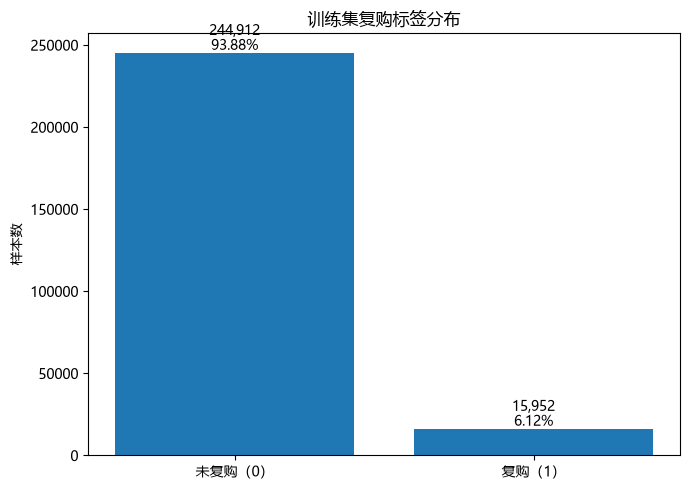

In [17]:
# ============================================================
# 12. 目标变量 label 分布
#
# label = 0：没有复购
# label = 1：发生复购
#
# 目的：
# 判断训练数据是否存在类别不平衡。
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. 统计标签数量
# ------------------------------------------------------------

label_summary = (
    train["label"]
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="样本数")
)

label_summary["占比"] = (
    label_summary["样本数"] / len(train)
)

display(label_summary)


# ------------------------------------------------------------
# 2. 绘制标签分布
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["未复购（0）", "复购（1）"],
    label_summary["样本数"]
)

ax.set_title("训练集复购标签分布")
ax.set_ylabel("样本数")

# 在柱子顶部标注数量和比例
for bar, count, rate in zip(
    bars,
    label_summary["样本数"],
    label_summary["占比"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n{rate:.2%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 13. 年龄段与复购率分析
#
# 目的：
# 比较不同年龄段：
# 1. 有多少训练样本
# 2. 有多少复购样本
# 3. 复购率是否存在明显差异
# ============================================================

# ------------------------------------------------------------
# 1. 创建用于分析的年龄字段
# ------------------------------------------------------------

train_profile["age_code"] = (
    train_profile["age_range"]
    .fillna(0)
    .astype(int)
)


# 官方年龄编码对应关系
age_mapping = {
    0: "未知",
    1: "<18",
    2: "18-24",
    3: "25-29",
    4: "30-34",
    5: "35-39",
    6: "40-49",
    7: "≥50（编码7）",
    8: "≥50（编码8）"
}

train_profile["年龄段"] = (
    train_profile["age_code"]
    .map(age_mapping)
)


# ------------------------------------------------------------
# 2. 统计每个年龄段的样本数和复购率
# ------------------------------------------------------------

age_summary = (
    train_profile
    .groupby(
        ["age_code", "年龄段"],
        observed=True
    )
    .agg(
        样本数=("label", "size"),
        复购样本数=("label", "sum"),
        复购率=("label", "mean"),
        用户数=("user_id", "nunique")
    )
    .reset_index()
    .sort_values("age_code")
)

display(
    age_summary.style.format({
        "样本数": "{:,}",
        "复购样本数": "{:,}",
        "用户数": "{:,}",
        "复购率": "{:.2%}"
    })
)

,age_code,年龄段,样本数,复购样本数,复购率,用户数
0,0,未知,"57,062","3,322",5.82%,"47,580"
1,1,<18,13,0,0.00%,11
2,2,18-24,"31,026","1,531",4.93%,"26,376"
3,3,25-29,"69,369","4,080",5.88%,"55,873"
4,4,30-34,"51,235","3,444",6.72%,"39,939"
5,5,35-39,"25,618","1,793",7.00%,"20,435"
6,6,40-49,"21,701","1,483",6.83%,"17,783"
7,7,≥50（编码7）,"4,120",249,6.04%,"3,460"
8,8,≥50（编码8）,720,50,6.94%,605


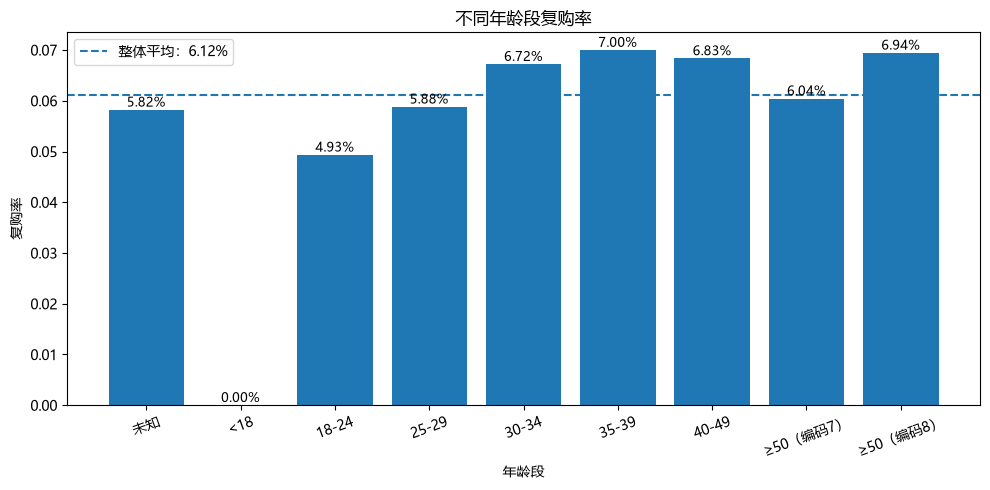

In [19]:
# ============================================================
# 14. 不同年龄段复购率
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    age_summary["年龄段"],
    age_summary["复购率"]
)

# 全体平均复购率
overall_rate = train["label"].mean()

ax.axhline(
    overall_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"整体平均：{overall_rate:.2%}"
)

ax.set_title("不同年龄段复购率")
ax.set_xlabel("年龄段")
ax.set_ylabel("复购率")

ax.legend()

# 添加数据标签
for bar, rate in zip(
    bars,
    age_summary["复购率"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2%}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 15. 性别与复购率分析
# ============================================================

# ------------------------------------------------------------
# 1. 处理性别编码
# ------------------------------------------------------------

train_profile["gender_code"] = (
    train_profile["gender"]
    .fillna(2)
    .astype(int)
)

gender_mapping = {
    0: "女性",
    1: "男性",
    2: "未知"
}

train_profile["性别"] = (
    train_profile["gender_code"]
    .map(gender_mapping)
)


# ------------------------------------------------------------
# 2. 统计样本量和复购率
# ------------------------------------------------------------

gender_summary = (
    train_profile
    .groupby(
        ["gender_code", "性别"],
        observed=True
    )
    .agg(
        样本数=("label", "size"),
        复购样本数=("label", "sum"),
        复购率=("label", "mean"),
        用户数=("user_id", "nunique")
    )
    .reset_index()
    .sort_values("gender_code")
)

display(
    gender_summary.style.format({
        "样本数": "{:,}",
        "复购样本数": "{:,}",
        "用户数": "{:,}",
        "复购率": "{:.2%}"
    })
)

,gender_code,性别,样本数,复购样本数,复购率,用户数
0,0,女性,"176,414","11,387",6.45%,"143,091"
1,1,男性,"73,756","3,969",5.38%,"60,683"
2,2,未知,"10,694",596,5.57%,"8,288"


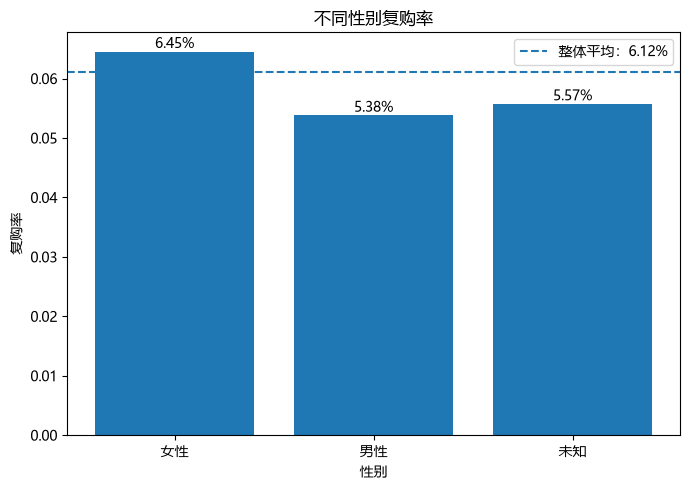

In [21]:
# ============================================================
# 16. 不同性别复购率
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    gender_summary["性别"],
    gender_summary["复购率"]
)

overall_rate = train["label"].mean()

ax.axhline(
    overall_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"整体平均：{overall_rate:.2%}"
)

ax.set_title("不同性别复购率")
ax.set_xlabel("性别")
ax.set_ylabel("复购率")

ax.legend()

for bar, rate in zip(
    bars,
    gender_summary["复购率"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 17. 用户行为类型分布
#
# 目的：
# 统计 5492 万条历史行为中：
# 0 = 点击
# 1 = 加购
# 2 = 购买
# 3 = 收藏
#
# 使用分块读取，避免一次性加载 1.91GB 数据。
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

# 每次读取 100 万行
chunk_size = 1_000_000

# 初始化行为计数
action_counts = {
    0: 0,   # 点击
    1: 0,   # 加购
    2: 0,   # 购买
    3: 0    # 收藏
}

total_rows = 0


# ------------------------------------------------------------
# 分块读取，只读取 action_type 一列
# ------------------------------------------------------------

reader = pd.read_csv(
    log_file,
    usecols=["action_type"],
    chunksize=chunk_size,
    dtype={"action_type": "int8"}
)

for chunk_number, chunk in enumerate(reader, start=1):

    # 当前数据块中各种行为的数量
    counts = chunk["action_type"].value_counts()

    # 累加到总计数
    for action in action_counts:
        action_counts[action] += int(
            counts.get(action, 0)
        )

    total_rows += len(chunk)

    # 每处理 10 个数据块打印一次进度
    if chunk_number % 10 == 0:
        print(
            f"已处理：{total_rows:,} 行"
        )


# ------------------------------------------------------------
# 整理统计结果
# ------------------------------------------------------------

action_mapping = {
    0: "点击",
    1: "加购",
    2: "购买",
    3: "收藏"
}

action_summary = pd.DataFrame({
    "action_type": list(action_counts.keys()),
    "行为": [
        action_mapping[i]
        for i in action_counts.keys()
    ],
    "行为次数": list(action_counts.values())
})

action_summary["占比"] = (
    action_summary["行为次数"]
    / action_summary["行为次数"].sum()
)


print("\n用户行为分布：")

display(
    action_summary.style.format({
        "行为次数": "{:,}",
        "占比": "{:.2%}"
    })
)

已处理：10,000,000 行
已处理：20,000,000 行
已处理：30,000,000 行
已处理：40,000,000 行
已处理：50,000,000 行

用户行为分布：


,action_type,行为,行为次数,占比
0,0,点击,"48,550,713",88.39%
1,1,加购,"76,750",0.14%
2,2,购买,"3,292,144",5.99%
3,3,收藏,"3,005,723",5.47%


In [23]:
# ============================================================
# 19. 按日期统计四类用户行为
#
# 目的：
# 观察点击、加购、购买、收藏在不同日期的变化趋势
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

chunk_size = 1_000_000

# 用于累计每个“日期 × 行为类型”的次数
daily_action_counts = None

reader = pd.read_csv(
    log_file,
    usecols=["time_stamp", "action_type"],
    chunksize=chunk_size,
    dtype={
        "time_stamp": "int16",
        "action_type": "int8"
    }
)

for chunk_number, chunk in enumerate(reader, start=1):

    # 当前数据块：
    # 按日期和行为类型统计次数
    chunk_counts = (
        chunk
        .groupby(["time_stamp", "action_type"])
        .size()
    )

    # 将不同数据块的统计结果累加
    if daily_action_counts is None:
        daily_action_counts = chunk_counts
    else:
        daily_action_counts = (
            daily_action_counts
            .add(chunk_counts, fill_value=0)
        )

    if chunk_number % 10 == 0:
        print(
            f"已处理约 {chunk_number * chunk_size:,} 行"
        )


# ------------------------------------------------------------
# 整理成 DataFrame
# ------------------------------------------------------------

daily_action = (
    daily_action_counts
    .reset_index(name="行为次数")
)

daily_action["行为次数"] = (
    daily_action["行为次数"]
    .astype("int64")
)

# 映射行为名称
action_mapping = {
    0: "点击",
    1: "加购",
    2: "购买",
    3: "收藏"
}

daily_action["行为"] = (
    daily_action["action_type"]
    .map(action_mapping)
)

# 按日期排序
daily_action = (
    daily_action
    .sort_values(
        ["time_stamp", "action_type"]
    )
    .reset_index(drop=True)
)

print("日期范围：")
print(
    daily_action["time_stamp"].min(),
    "→",
    daily_action["time_stamp"].max()
)

print("\n前 10 行：")
display(daily_action.head(10))

已处理约 10,000,000 行
已处理约 20,000,000 行
已处理约 30,000,000 行
已处理约 40,000,000 行
已处理约 50,000,000 行
日期范围：
511 → 1112

前 10 行：


,time_stamp,action_type,行为次数,行为
0,511,1,62,加购
1,511,2,9597,购买
2,511,3,10385,收藏
3,512,1,89,加购
4,512,2,10421,购买
5,512,3,10194,收藏
6,513,1,84,加购
7,513,2,12601,购买
8,513,3,11045,收藏
9,514,1,107,加购


In [24]:
# ============================================================
# 20. 将 time_stamp 转换为可读日期
#
# 原始格式示例：
# 511  → 05-11
# 829  → 08-29
# 1011 → 10-11
# 1111 → 11-11
# ============================================================

# 将数字统一补成 4 位字符串
# 例如：
# 511 → "0511"
# 1111 → "1111"
daily_action["date_str"] = (
    daily_action["time_stamp"]
    .astype(str)
    .str.zfill(4)
)

# 拆分月份和日期
daily_action["month"] = (
    daily_action["date_str"]
    .str[:2]
    .astype(int)
)

daily_action["day"] = (
    daily_action["date_str"]
    .str[2:]
    .astype(int)
)

# ------------------------------------------------------------
# 创建真正的日期变量
#
# 这里使用 2014 年，是因为这套天猫双11数据对应的是
# 2014 年的行为记录。
# ------------------------------------------------------------

daily_action["date"] = pd.to_datetime(
    {
        "year": 2014,
        "month": daily_action["month"],
        "day": daily_action["day"]
    }
)

print(
    "转换后的日期范围：",
    daily_action["date"].min().date(),
    "→",
    daily_action["date"].max().date()
)

display(
    daily_action[
        [
            "time_stamp",
            "date",
            "action_type",
            "行为",
            "行为次数"
        ]
    ].head(10)
)

转换后的日期范围： 2014-05-11 → 2014-11-12


,time_stamp,date,action_type,行为,行为次数
0,511,2014-05-11,1,加购,62
1,511,2014-05-11,2,购买,9597
2,511,2014-05-11,3,收藏,10385
3,512,2014-05-12,1,加购,89
4,512,2014-05-12,2,购买,10421
5,512,2014-05-12,3,收藏,10194
6,513,2014-05-13,1,加购,84
7,513,2014-05-13,2,购买,12601
8,513,2014-05-13,3,收藏,11045
9,514,2014-05-14,1,加购,107


In [25]:
# ============================================================
# 21. 构造每日行为宽表
# ============================================================

daily_pivot = (
    daily_action
    .pivot_table(
        index="date",
        columns="行为",
        values="行为次数",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index()
)

# 确保四类行为列都存在
for action in ["点击", "加购", "购买", "收藏"]:
    if action not in daily_pivot.columns:
        daily_pivot[action] = 0

# 固定列顺序
daily_pivot = daily_pivot[
    ["点击", "加购", "购买", "收藏"]
]

print("每日行为数据：")
display(daily_pivot.head())

print("\n双11附近：")
display(
    daily_pivot.loc[
        "2014-11-07":"2014-11-12"
    ]
)

每日行为数据：


行为,点击,加购,购买,收藏
date,,,,
2014-05-11,0,62,9597,10385
2014-05-12,0,89,10421,10194
2014-05-13,0,84,12601,11045
2014-05-14,0,107,12671,11610
2014-05-15,0,90,12220,11803



双11附近：


行为,点击,加购,购买,收藏
date,,,,
2014-11-07,777904,3068,12820,64054
2014-11-08,879656,3452,11721,73270
2014-11-09,1102507,4825,11393,88548
2014-11-10,2750192,11711,17249,161674
2014-11-11,9188104,14725,1223354,156450
2014-11-12,46,0,0,0


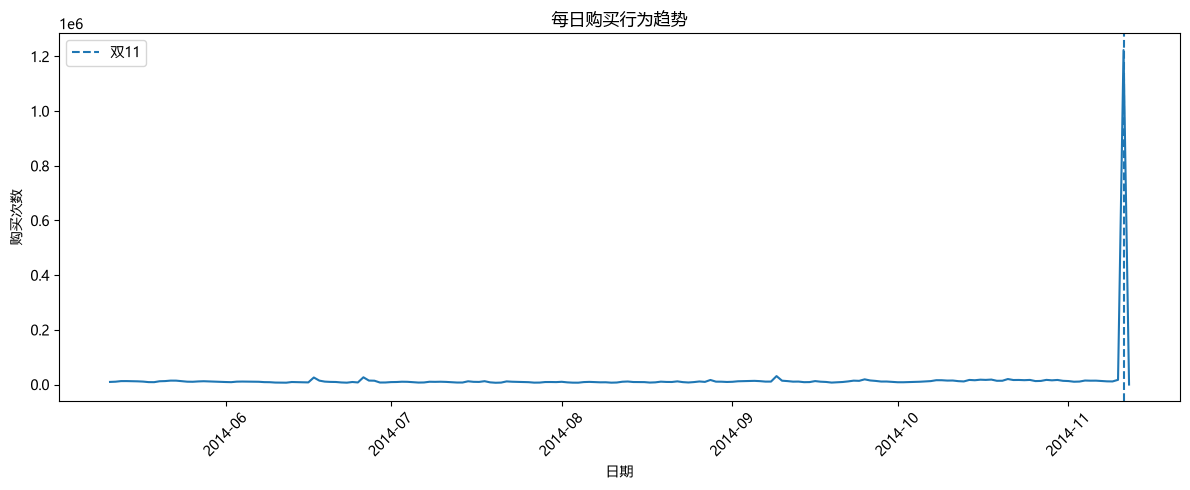

In [26]:
# ============================================================
# 22. 每日购买行为趋势
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_pivot.index,
    daily_pivot["购买"],
    linewidth=1.5
)

# 标出双11
ax.axvline(
    pd.Timestamp("2014-11-11"),
    linestyle="--",
    linewidth=1.5,
    label="双11"
)

ax.set_title("每日购买行为趋势")
ax.set_xlabel("日期")
ax.set_ylabel("购买次数")

ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 23. 找出四类行为的峰值日期
# ============================================================

peak_results = []

for action in ["点击", "加购", "购买", "收藏"]:

    peak_date = daily_pivot[action].idxmax()
    peak_count = daily_pivot[action].max()

    peak_results.append({
        "行为": action,
        "峰值日期": peak_date.date(),
        "峰值次数": int(peak_count)
    })

peak_summary = pd.DataFrame(peak_results)

display(
    peak_summary.style.format({
        "峰值次数": "{:,}"
    })
)

,行为,峰值日期,峰值次数
0,点击,2014-11-11,"9,188,104"
1,加购,2014-11-11,"14,725"
2,购买,2014-11-11,"1,223,354"
3,收藏,2014-11-10,"161,674"


In [28]:
# ============================================================
# 24. 双11行为放大效应
#
# 目的：
# 比较双11当天与双11前常态期（11月1日-11月9日）的行为水平
#
# 为什么不使用11月10日作为基准？
# 因为11月10日已经出现明显的预热效应，
# 特别是收藏行为已经达到峰值。
#
# 为什么不使用11月12日？
# 因为11月12日明显属于不完整日志日。
# ============================================================

# ------------------------------------------------------------
# 1. 定义双11前的基准期
# ------------------------------------------------------------

baseline = daily_pivot.loc[
    "2014-11-01":"2014-11-09"
]

# 计算基准期每日平均行为次数
baseline_mean = baseline.mean()


# ------------------------------------------------------------
# 2. 获取11月10日和11月11日数据
# ------------------------------------------------------------

nov10 = daily_pivot.loc["2014-11-10"]
nov11 = daily_pivot.loc["2014-11-11"]


# ------------------------------------------------------------
# 3. 计算相对基准期的放大倍数
# ------------------------------------------------------------

double11_summary = pd.DataFrame({
    "双11前日均": baseline_mean,
    "11月10日": nov10,
    "11月11日": nov11
})

double11_summary["11月10日放大倍数"] = (
    double11_summary["11月10日"]
    / double11_summary["双11前日均"]
)

double11_summary["11月11日放大倍数"] = (
    double11_summary["11月11日"]
    / double11_summary["双11前日均"]
)

# 行为名称放到普通列
double11_summary = (
    double11_summary
    .reset_index()
    .rename(columns={"行为": "行为类型"})
)

display(
    double11_summary.style.format({
        "双11前日均": "{:,.0f}",
        "11月10日": "{:,.0f}",
        "11月11日": "{:,.0f}",
        "11月10日放大倍数": "{:.2f}×",
        "11月11日放大倍数": "{:.2f}×"
    })
)

,行为类型,双11前日均,11月10日,11月11日,11月10日放大倍数,11月11日放大倍数
0,点击,"711,001","2,750,192","9,188,104",3.87×,12.92×
1,加购,"2,707","11,711","14,725",4.33×,5.44×
2,购买,"12,560","17,249","1,223,354",1.37×,97.40×
3,收藏,"60,242","161,674","156,450",2.68×,2.60×


In [29]:
# ============================================================
# 25. 双11前一天到双11当天的行为变化
# ============================================================

day_change = pd.DataFrame({
    "11月10日": nov10,
    "11月11日": nov11
})

day_change["变化率"] = (
    day_change["11月11日"]
    / day_change["11月10日"]
    - 1
)

day_change = (
    day_change
    .reset_index()
    .rename(columns={"行为": "行为类型"})
)

display(
    day_change.style.format({
        "11月10日": "{:,.0f}",
        "11月11日": "{:,.0f}",
        "变化率": "{:+.2%}"
    })
)

,行为类型,11月10日,11月11日,变化率
0,点击,"2,750,192","9,188,104",+234.09%
1,加购,"11,711","14,725",+25.74%
2,购买,"17,249","1,223,354",+6992.32%
3,收藏,"161,674","156,450",-3.23%


In [30]:
# ============================================================
# 26. 构造用户层面的行为次数特征
#
# 目的：
# 对每个用户统计：
# 1. 点击次数
# 2. 加购次数
# 3. 购买次数
# 4. 收藏次数
# 5. 总交互次数
#
# 这些是后续用户特征工程的基础。
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

chunk_size = 1_000_000

# ------------------------------------------------------------
# 初始化结果
# index = user_id
# columns = 四种行为
# ------------------------------------------------------------

user_action_counts = None


# ------------------------------------------------------------
# 分块读取日志
# ------------------------------------------------------------

reader = pd.read_csv(
    log_file,
    usecols=["user_id", "action_type"],
    chunksize=chunk_size,
    dtype={
        "user_id": "int32",
        "action_type": "int8"
    }
)

for chunk_number, chunk in enumerate(reader, start=1):

    # 当前数据块中：
    # 统计每个用户四种行为分别发生多少次
    chunk_counts = (
        chunk
        .groupby(
            ["user_id", "action_type"]
        )
        .size()
        .unstack(
            fill_value=0
        )
    )

    # 将各个数据块的统计结果累加
    if user_action_counts is None:
        user_action_counts = chunk_counts
    else:
        user_action_counts = (
            user_action_counts
            .add(
                chunk_counts,
                fill_value=0
            )
        )

    if chunk_number % 10 == 0:
        print(
            f"已处理约 "
            f"{chunk_number * chunk_size:,} 行"
        )


# ------------------------------------------------------------
# 整理字段
# ------------------------------------------------------------

# 确保四类行为列都存在
for action in [0, 1, 2, 3]:
    if action not in user_action_counts.columns:
        user_action_counts[action] = 0

# 固定列顺序
user_action_counts = user_action_counts[
    [0, 1, 2, 3]
]

# 修改成容易理解的字段名
user_action_counts.columns = [
    "user_click_count",
    "user_cart_count",
    "user_buy_count",
    "user_favorite_count"
]

# user_id 从索引恢复为普通列
user_action_counts = (
    user_action_counts
    .reset_index()
)

# 计数统一转成整数
count_columns = [
    "user_click_count",
    "user_cart_count",
    "user_buy_count",
    "user_favorite_count"
]

user_action_counts[count_columns] = (
    user_action_counts[count_columns]
    .astype("int32")
)

# ------------------------------------------------------------
# 计算总交互次数
# ------------------------------------------------------------

user_action_counts["user_total_action_count"] = (
    user_action_counts[
        count_columns
    ].sum(axis=1)
)


print("用户行为特征规模：")
print(user_action_counts.shape)

print("\n前 5 行：")
display(user_action_counts.head())

已处理约 10,000,000 行
已处理约 20,000,000 行
已处理约 30,000,000 行
已处理约 40,000,000 行
已处理约 50,000,000 行
用户行为特征规模：
(424170, 6)

前 5 行：


,user_id,user_click_count,user_cart_count,user_buy_count,user_favorite_count,user_total_action_count
0,1,27,0,6,0,33
1,2,47,0,14,2,63
2,3,63,0,4,1,68
3,4,49,0,1,0,50
4,5,150,0,13,10,173


In [31]:
# ============================================================
# 27. 用户行为特征完整性验证
# ============================================================

print("=" * 60)
print("用户行为次数合计检查")
print("=" * 60)

print(
    "点击总次数：",
    f"{user_action_counts['user_click_count'].sum():,}"
)

print(
    "加购总次数：",
    f"{user_action_counts['user_cart_count'].sum():,}"
)

print(
    "购买总次数：",
    f"{user_action_counts['user_buy_count'].sum():,}"
)

print(
    "收藏总次数：",
    f"{user_action_counts['user_favorite_count'].sum():,}"
)

print(
    "总交互次数：",
    f"{user_action_counts['user_total_action_count'].sum():,}"
)

print("\n用户数量：")
print(f"{user_action_counts['user_id'].nunique():,}")

用户行为次数合计检查
点击总次数： 48,550,713
加购总次数： 76,750
购买总次数： 3,292,144
收藏总次数： 3,005,723
总交互次数： 54,925,330

用户数量：
424,170


In [32]:
# ============================================================
# 28. 构造用户行为占比特征
#
# 这些特征用于描述：
# 一个用户的历史行为结构更偏向浏览，
# 还是更偏向实际购买。
# ============================================================

user_action_counts["user_click_ratio"] = (
    user_action_counts["user_click_count"]
    / user_action_counts["user_total_action_count"]
)

user_action_counts["user_cart_ratio"] = (
    user_action_counts["user_cart_count"]
    / user_action_counts["user_total_action_count"]
)

user_action_counts["user_buy_ratio"] = (
    user_action_counts["user_buy_count"]
    / user_action_counts["user_total_action_count"]
)

user_action_counts["user_favorite_ratio"] = (
    user_action_counts["user_favorite_count"]
    / user_action_counts["user_total_action_count"]
)

display(
    user_action_counts.head()
)

,user_id,user_click_count,user_cart_count,user_buy_count,user_favorite_count,user_total_action_count,user_click_ratio,user_cart_ratio,user_buy_ratio,user_favorite_ratio
0,1,27,0,6,0,33,0.818182,0.0,0.181818,0.000000
1,2,47,0,14,2,63,0.746032,0.0,0.222222,0.031746
2,3,63,0,4,1,68,0.926471,0.0,0.058824,0.014706
3,4,49,0,1,0,50,0.980000,0.0,0.020000,0.000000
4,5,150,0,13,10,173,0.867052,0.0,0.075145,0.057803


In [33]:
# ============================================================
# 29. 用户行为特征 × 复购标签
# ============================================================

train_user_feature = train.merge(
    user_action_counts,
    on="user_id",
    how="left",
    validate="many_to_one"
)

print("合并后规模：")
print(train_user_feature.shape)

# ------------------------------------------------------------
# 按 label 比较两类用户的平均行为水平
# ------------------------------------------------------------

compare_columns = [
    "user_total_action_count",
    "user_click_count",
    "user_cart_count",
    "user_buy_count",
    "user_favorite_count",
    "user_buy_ratio"
]

user_feature_compare = (
    train_user_feature
    .groupby("label")[compare_columns]
    .mean()
    .T
)

user_feature_compare.columns = [
    "未复购用户",
    "复购用户"
]

user_feature_compare["复购/未复购倍数"] = (
    user_feature_compare["复购用户"]
    / user_feature_compare["未复购用户"]
)

display(
    user_feature_compare.style.format({
        "未复购用户": "{:.3f}",
        "复购用户": "{:.3f}",
        "复购/未复购倍数": "{:.2f}×"
    })
)

合并后规模：
(260864, 12)


,未复购用户,复购用户,复购/未复购倍数
user_total_action_count,140.558,171.501,1.22×
user_click_count,124.069,151.389,1.22×
user_cart_count,0.185,0.156,0.84×
user_buy_count,8.595,10.430,1.21×
user_favorite_count,7.709,9.526,1.24×
user_buy_ratio,0.100,0.101,1.01×


In [34]:
# ============================================================
# 30. 比较复购 / 未复购用户行为特征的中位数
#
# 为什么要看中位数？
# 电商用户行为通常存在明显长尾：
# 少量超级活跃用户可能把平均值拉得很高。
#
# 因此同时比较均值和中位数，可以判断结论是否稳健。
# ============================================================

compare_columns = [
    "user_total_action_count",
    "user_click_count",
    "user_cart_count",
    "user_buy_count",
    "user_favorite_count",
    "user_buy_ratio"
]

user_feature_median = (
    train_user_feature
    .groupby("label")[compare_columns]
    .median()
    .T
)

user_feature_median.columns = [
    "未复购用户中位数",
    "复购用户中位数"
]

user_feature_median["复购/未复购倍数"] = (
    user_feature_median["复购用户中位数"]
    / user_feature_median["未复购用户中位数"]
)

display(
    user_feature_median.style.format({
        "未复购用户中位数": "{:.3f}",
        "复购用户中位数": "{:.3f}",
        "复购/未复购倍数": "{:.2f}×"
    })
)

,未复购用户中位数,复购用户中位数,复购/未复购倍数
user_total_action_count,80.000,98.000,1.23×
user_click_count,68.000,83.000,1.22×
user_cart_count,0.000,0.000,nan×
user_buy_count,6.000,7.000,1.17×
user_favorite_count,1.000,1.000,1.00×
user_buy_ratio,0.075,0.075,1.00×


In [35]:
# ============================================================
# 31. 保存用户层面的基础行为特征
#
# 目的：
# 避免以后每次打开 Notebook 都重新扫描
# 5492 万条行为日志。
# ============================================================

from pathlib import Path

feature_dir = Path("feature")

# 如果文件夹不存在则创建
feature_dir.mkdir(exist_ok=True)

user_feature_path = (
    feature_dir / "user_basic_features_2026.csv"
)

user_action_counts.to_csv(
    user_feature_path,
    index=False
)

print("✅ 用户基础行为特征已保存")
print("保存位置：", user_feature_path)
print("数据规模：", user_action_counts.shape)

✅ 用户基础行为特征已保存
保存位置： feature\user_basic_features_2026.csv
数据规模： (424170, 10)


In [36]:
# ============================================================
# 32. 构造目标 user × merchant 列表
#
# 目的：
# 只保留训练集和测试集中真正需要建模的
# user_id × merchant_id 组合。
#
# 这样后面处理5492万条日志时，
# 不需要为无关的用户 × 商家组合计算特征。
# ============================================================

target_pairs = pd.concat(
    [
        train[["user_id", "merchant_id"]],
        test[["user_id", "merchant_id"]]
    ],
    ignore_index=True
)

# 理论上训练集和测试集之间不会存在重复目标 pair，
# 但这里仍做一次保险去重。
target_pairs = (
    target_pairs
    .drop_duplicates(
        subset=["user_id", "merchant_id"]
    )
    .reset_index(drop=True)
)

print("需要构造特征的 user × merchant 数量：")
print(f"{len(target_pairs):,}")

print("\n前 5 行：")
display(target_pairs.head())

需要构造特征的 user × merchant 数量：
522,341

前 5 行：


,user_id,merchant_id
0,34176,3906
1,34176,121
2,34176,4356
3,34176,2217
4,230784,4818


In [37]:
# ============================================================
# 33. 构造 user × merchant 行为次数特征
#
# 对每一个目标 user × merchant 统计：
# 1. 对该商家的点击次数
# 2. 对该商家的加购次数
# 3. 对该商家的购买次数
# 4. 对该商家的收藏次数
#
# 这是整个项目非常核心的一类特征。
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

chunk_size = 1_000_000

# ------------------------------------------------------------
# 为了加快 merge，先压缩整数类型
# ------------------------------------------------------------

target_pairs_small = target_pairs.copy()

target_pairs_small["user_id"] = (
    target_pairs_small["user_id"]
    .astype("int32")
)

target_pairs_small["merchant_id"] = (
    target_pairs_small["merchant_id"]
    .astype("int32")
)


# ------------------------------------------------------------
# 用于累计不同数据块的 user × merchant × action 计数
# ------------------------------------------------------------

pair_action_counts = None


reader = pd.read_csv(
    log_file,
    usecols=[
        "user_id",
        "seller_id",
        "action_type"
    ],
    chunksize=chunk_size,
    dtype={
        "user_id": "int32",
        "seller_id": "int32",
        "action_type": "int8"
    }
)


for chunk_number, chunk in enumerate(reader, start=1):

    # seller_id 与训练集里的 merchant_id
    # 表示同一个商家维度，因此统一字段名称
    chunk = chunk.rename(
        columns={"seller_id": "merchant_id"}
    )

    # --------------------------------------------------------
    # 只保留训练/测试集中真正需要预测的目标 pair
    # --------------------------------------------------------

    matched = chunk.merge(
        target_pairs_small,
        on=["user_id", "merchant_id"],
        how="inner"
    )

    # --------------------------------------------------------
    # 当前数据块中：
    # 统计每个 user × merchant 的四类行为次数
    # --------------------------------------------------------

    if not matched.empty:

        chunk_counts = (
            matched
            .groupby(
                [
                    "user_id",
                    "merchant_id",
                    "action_type"
                ]
            )
            .size()
            .unstack(fill_value=0)
        )

        # 不同数据块之间累计
        if pair_action_counts is None:
            pair_action_counts = chunk_counts
        else:
            pair_action_counts = (
                pair_action_counts
                .add(
                    chunk_counts,
                    fill_value=0
                )
            )

    if chunk_number % 10 == 0:
        print(
            f"已处理约 "
            f"{chunk_number * chunk_size:,} 行"
        )

已处理约 10,000,000 行
已处理约 20,000,000 行
已处理约 30,000,000 行
已处理约 40,000,000 行
已处理约 50,000,000 行


In [38]:
# ============================================================
# 34. 整理 user × merchant 行为次数特征
# ============================================================

# 确保四种行为列都存在
for action in [0, 1, 2, 3]:
    if action not in pair_action_counts.columns:
        pair_action_counts[action] = 0

# 固定列顺序
pair_action_counts = pair_action_counts[
    [0, 1, 2, 3]
]

# 重命名
pair_action_counts.columns = [
    "um_click_count",
    "um_cart_count",
    "um_buy_count",
    "um_favorite_count"
]

# 恢复普通列
pair_action_counts = (
    pair_action_counts
    .reset_index()
)

# 计数转为整数
um_count_columns = [
    "um_click_count",
    "um_cart_count",
    "um_buy_count",
    "um_favorite_count"
]

pair_action_counts[um_count_columns] = (
    pair_action_counts[um_count_columns]
    .astype("int32")
)

# ------------------------------------------------------------
# 与完整目标 pair 合并
#
# 理论上某些目标 pair 可能没有相应行为记录，
# 这时行为次数应该填 0。
# ------------------------------------------------------------

user_merchant_features = target_pairs.merge(
    pair_action_counts,
    on=["user_id", "merchant_id"],
    how="left",
    validate="one_to_one"
)

user_merchant_features[um_count_columns] = (
    user_merchant_features[um_count_columns]
    .fillna(0)
    .astype("int32")
)

# 总互动次数
user_merchant_features["um_total_action_count"] = (
    user_merchant_features[
        um_count_columns
    ].sum(axis=1)
)

print("user × merchant 特征规模：")
print(user_merchant_features.shape)

print("\n前 10 行：")
display(user_merchant_features.head(10))

user × merchant 特征规模：
(522341, 7)

前 10 行：


,user_id,merchant_id,um_click_count,um_cart_count,um_buy_count,um_favorite_count,um_total_action_count
0,34176,3906,36,0,1,2,39
1,34176,121,13,0,1,0,14
2,34176,4356,12,0,6,0,18
3,34176,2217,1,0,1,0,2
4,230784,4818,7,0,1,0,8
5,362112,2618,0,0,1,0,1
6,34944,2051,2,0,1,0,3
7,231552,3828,78,0,5,0,83
8,231552,2124,6,0,1,0,7
9,232320,1168,2,0,1,1,4


In [39]:
# ============================================================
# 35. 用户 × 商家历史互动与未来复购
#
# 目的：
# 比较未来复购 / 未复购样本，
# 在历史上与目标商家的互动深度是否不同。
# ============================================================

train_um = train.merge(
    user_merchant_features,
    on=["user_id", "merchant_id"],
    how="left",
    validate="one_to_one"
)

compare_columns = [
    "um_total_action_count",
    "um_click_count",
    "um_cart_count",
    "um_buy_count",
    "um_favorite_count"
]

um_feature_compare = (
    train_um
    .groupby("label")[compare_columns]
    .mean()
    .T
)

um_feature_compare.columns = [
    "未复购",
    "复购"
]

um_feature_compare["复购/未复购倍数"] = (
    um_feature_compare["复购"]
    / um_feature_compare["未复购"]
)

display(
    um_feature_compare.style.format({
        "未复购": "{:.3f}",
        "复购": "{:.3f}",
        "复购/未复购倍数": "{:.2f}×"
    })
)

,未复购,复购,复购/未复购倍数
um_total_action_count,10.415,17.149,1.65×
um_click_count,8.703,14.825,1.70×
um_cart_count,0.024,0.021,0.88×
um_buy_count,1.321,1.623,1.23×
um_favorite_count,0.367,0.679,1.85×


In [40]:
# ============================================================
# 36. 保存基础 user × merchant 行为特征
#
# 目的：
# 避免以后重新扫描 5492 万条日志来计算基础行为次数。
# ============================================================

from pathlib import Path

feature_dir = Path("feature")
feature_dir.mkdir(exist_ok=True)

um_basic_path = (
    feature_dir / "user_merchant_basic_features_2026.csv"
)

user_merchant_features.to_csv(
    um_basic_path,
    index=False
)

print("✅ user × merchant 基础特征已保存")
print("保存位置：", um_basic_path)
print("数据规模：", user_merchant_features.shape)

✅ user × merchant 基础特征已保存
保存位置： feature\user_merchant_basic_features_2026.csv
数据规模： (522341, 7)


In [41]:
# ============================================================
# 37. 提取目标 user × merchant 的详细互动日志
#
# 目的：
# 从全部 5492 万条日志中，只保留训练集和测试集涉及的
# 52.2 万个目标 user × merchant 的历史互动。
#
# 后续用于计算：
# - 互动天数
# - 不同商品数
# - 不同品类数
# - 不同品牌数
# - 各行为对应的商品/品类/品牌广度
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

chunk_size = 1_000_000

matched_parts = []

reader = pd.read_csv(
    log_file,
    usecols=[
        "user_id",
        "item_id",
        "cat_id",
        "seller_id",
        "brand_id",
        "time_stamp",
        "action_type"
    ],
    chunksize=chunk_size,
    dtype={
        "user_id": "int32",
        "item_id": "int32",
        "cat_id": "int32",
        "seller_id": "int32",
        "brand_id": "float32",
        "time_stamp": "int16",
        "action_type": "int8"
    }
)

for chunk_number, chunk in enumerate(reader, start=1):

    # seller_id 和 merchant_id 表示同一商家维度
    chunk = chunk.rename(
        columns={"seller_id": "merchant_id"}
    )

    # --------------------------------------------------------
    # 11月12日只有46条异常/不完整日志。
    # 我们的预测节点是双11，因此特征统一截止到11月11日，
    # 避免把不完整的11月12日记录混入模型。
    # --------------------------------------------------------
    chunk = chunk[
        chunk["time_stamp"] <= 1111
    ]

    # 只保留需要预测的 user × merchant
    matched = chunk.merge(
        target_pairs_small,
        on=["user_id", "merchant_id"],
        how="inner"
    )

    if not matched.empty:
        matched_parts.append(matched)

    if chunk_number % 10 == 0:
        print(
            f"已处理约 "
            f"{chunk_number * chunk_size:,} 行"
        )


# ------------------------------------------------------------
# 合并所有目标 pair 的详细日志
# ------------------------------------------------------------

target_logs = pd.concat(
    matched_parts,
    ignore_index=True
)

# 释放列表占用的内存
del matched_parts

print("\n✅ 目标 user × merchant 日志提取完成")
print(f"保留日志：{len(target_logs):,} 行")
print("字段：", target_logs.columns.tolist())

display(target_logs.head())

已处理约 10,000,000 行
已处理约 20,000,000 行
已处理约 30,000,000 行
已处理约 40,000,000 行
已处理约 50,000,000 行

✅ 目标 user × merchant 日志提取完成
保留日志：5,662,511 行
字段： ['user_id', 'item_id', 'cat_id', 'merchant_id', 'brand_id', 'time_stamp', 'action_type']


,user_id,item_id,cat_id,merchant_id,brand_id,time_stamp,action_type
0,328862,406349,1280,2700,5476.0,1111,0
1,328862,406349,1280,2700,5476.0,1111,0
2,328862,406349,1280,2700,5476.0,1111,2
3,328862,406349,1280,2700,5476.0,1111,0
4,328862,406349,1280,2700,5476.0,1111,0


In [42]:
# ============================================================
# 38. user × merchant 各类行为天数
#
# 同样是点击20次：
# A 用户可能一天内点20次；
# B 用户可能连续10天每天点2次。
#
# 因此“互动天数”能补充纯次数无法表达的持续性。
# ============================================================

# 每个 user × merchant × 行为类型
# 分别统计发生行为的不同日期数量
um_action_days = (
    target_logs
    .groupby(
        ["user_id", "merchant_id", "action_type"]
    )["time_stamp"]
    .nunique()
    .unstack(fill_value=0)
)

# 确保四个行为类型都有列
for action in [0, 1, 2, 3]:
    if action not in um_action_days.columns:
        um_action_days[action] = 0

um_action_days = um_action_days[
    [0, 1, 2, 3]
]

um_action_days.columns = [
    "um_click_days",
    "um_cart_days",
    "um_buy_days",
    "um_favorite_days"
]

um_action_days = (
    um_action_days
    .reset_index()
)

display(um_action_days.head())

,user_id,merchant_id,um_click_days,um_cart_days,um_buy_days,um_favorite_days
0,1,1019,1,0,1,0
1,2,1679,0,0,1,0
2,2,1784,0,0,1,0
3,3,2313,1,0,1,1
4,4,1186,1,0,1,0


In [43]:
# ============================================================
# 39. user × merchant 互动广度特征
#
# 统计用户在目标商家中接触过多少：
# - 不同商品
# - 不同品类
# - 不同品牌
# - 不同日期
# ============================================================

um_breadth = (
    target_logs
    .groupby(
        ["user_id", "merchant_id"]
    )
    .agg(
        um_item_count=(
            "item_id",
            "nunique"
        ),
        um_cat_count=(
            "cat_id",
            "nunique"
        ),
        um_brand_count=(
            "brand_id",
            "nunique"
        ),
        um_active_days=(
            "time_stamp",
            "nunique"
        )
    )
    .reset_index()
)

display(um_breadth.head())

,user_id,merchant_id,um_item_count,um_cat_count,um_brand_count,um_active_days
0,1,1019,1,1,1,1
1,2,1679,2,1,1,1
2,2,1784,1,1,1,1
3,3,2313,2,2,1,2
4,4,1186,1,1,1,1


In [44]:
# ============================================================
# 40. 修正用户整体基础行为特征
#
# 口径统一：
# 所有用于建模的历史行为特征截止到 2014-11-11。
#
# 原因：
# 11月12日只有46条点击记录，属于不完整尾日，
# 不应该进入模型特征。
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

chunk_size = 1_000_000

user_action_counts = None

reader = pd.read_csv(
    log_file,
    usecols=[
        "user_id",
        "time_stamp",
        "action_type"
    ],
    chunksize=chunk_size,
    dtype={
        "user_id": "int32",
        "time_stamp": "int16",
        "action_type": "int8"
    }
)

for chunk_number, chunk in enumerate(reader, start=1):

    # 只使用双11及以前的行为
    chunk = chunk[
        chunk["time_stamp"] <= 1111
    ]

    chunk_counts = (
        chunk
        .groupby(["user_id", "action_type"])
        .size()
        .unstack(fill_value=0)
    )

    if user_action_counts is None:
        user_action_counts = chunk_counts
    else:
        user_action_counts = (
            user_action_counts
            .add(chunk_counts, fill_value=0)
        )

    if chunk_number % 10 == 0:
        print(
            f"已处理约 {chunk_number * chunk_size:,} 行"
        )


# 确保四类行为都存在
for action in [0, 1, 2, 3]:
    if action not in user_action_counts.columns:
        user_action_counts[action] = 0

user_action_counts = user_action_counts[
    [0, 1, 2, 3]
]

user_action_counts.columns = [
    "user_click_count",
    "user_cart_count",
    "user_buy_count",
    "user_favorite_count"
]

user_action_counts = (
    user_action_counts
    .reset_index()
)

count_columns = [
    "user_click_count",
    "user_cart_count",
    "user_buy_count",
    "user_favorite_count"
]

user_action_counts[count_columns] = (
    user_action_counts[count_columns]
    .astype("int32")
)

# 总行为次数
user_action_counts["user_total_action_count"] = (
    user_action_counts[count_columns]
    .sum(axis=1)
)

# 各类行为占比
user_action_counts["user_click_ratio"] = (
    user_action_counts["user_click_count"]
    / user_action_counts["user_total_action_count"]
)

user_action_counts["user_cart_ratio"] = (
    user_action_counts["user_cart_count"]
    / user_action_counts["user_total_action_count"]
)

user_action_counts["user_buy_ratio"] = (
    user_action_counts["user_buy_count"]
    / user_action_counts["user_total_action_count"]
)

user_action_counts["user_favorite_ratio"] = (
    user_action_counts["user_favorite_count"]
    / user_action_counts["user_total_action_count"]
)

print("修正后的用户特征规模：")
print(user_action_counts.shape)

print("\n双11及以前总行为次数：")
print(
    f"{user_action_counts['user_total_action_count'].sum():,}"
)

已处理约 10,000,000 行
已处理约 20,000,000 行
已处理约 30,000,000 行
已处理约 40,000,000 行
已处理约 50,000,000 行
修正后的用户特征规模：
(424170, 10)

双11及以前总行为次数：
54,925,284


In [45]:
# ============================================================
# 41. 基于 target_logs 重建 user × merchant 基础行为次数
#
# target_logs 已经限定：
# time_stamp <= 1111
#
# 因此直接从它生成基础行为次数，
# 保证与后面的天数、商品数、品类数等特征口径完全一致。
# ============================================================

pair_action_counts = (
    target_logs
    .groupby(
        ["user_id", "merchant_id", "action_type"]
    )
    .size()
    .unstack(fill_value=0)
)

# 确保四类行为都存在
for action in [0, 1, 2, 3]:
    if action not in pair_action_counts.columns:
        pair_action_counts[action] = 0

pair_action_counts = pair_action_counts[
    [0, 1, 2, 3]
]

pair_action_counts.columns = [
    "um_click_count",
    "um_cart_count",
    "um_buy_count",
    "um_favorite_count"
]

pair_action_counts = (
    pair_action_counts
    .reset_index()
)

um_count_columns = [
    "um_click_count",
    "um_cart_count",
    "um_buy_count",
    "um_favorite_count"
]

pair_action_counts[um_count_columns] = (
    pair_action_counts[um_count_columns]
    .astype("int32")
)

# 与完整目标 pair 合并
user_merchant_features = target_pairs.merge(
    pair_action_counts,
    on=["user_id", "merchant_id"],
    how="left",
    validate="one_to_one"
)

user_merchant_features[um_count_columns] = (
    user_merchant_features[um_count_columns]
    .fillna(0)
    .astype("int32")
)

user_merchant_features["um_total_action_count"] = (
    user_merchant_features[
        um_count_columns
    ].sum(axis=1)
)

print("修正后的 user × merchant 基础特征：")
print(user_merchant_features.shape)

display(user_merchant_features.head())

修正后的 user × merchant 基础特征：
(522341, 7)


,user_id,merchant_id,um_click_count,um_cart_count,um_buy_count,um_favorite_count,um_total_action_count
0,34176,3906,36,0,1,2,39
1,34176,121,13,0,1,0,14
2,34176,4356,12,0,6,0,18
3,34176,2217,1,0,1,0,2
4,230784,4818,7,0,1,0,8


In [46]:
# ============================================================
# 42. 检查各类行为天数特征的取值分布
#
# 如果某个变量所有样本都完全相同，
# 它就没有任何模型区分能力。
# ============================================================

day_columns = [
    "um_click_days",
    "um_cart_days",
    "um_buy_days",
    "um_favorite_days"
]

day_feature_check = pd.DataFrame({
    "不同取值数量": [
        um_action_days[col].nunique()
        for col in day_columns
    ],
    "最小值": [
        um_action_days[col].min()
        for col in day_columns
    ],
    "最大值": [
        um_action_days[col].max()
        for col in day_columns
    ]
}, index=day_columns)

display(day_feature_check)

,不同取值数量,最小值,最大值
um_click_days,54,0,66
um_cart_days,6,0,5
um_buy_days,1,1,1
um_favorite_days,24,0,32


In [47]:
# ============================================================
# 42A. 构造不同用户行为下的商品 / 品类 / 品牌广度特征
#
# 目的：
# 对每一个 user × merchant，分别统计：
#
# 点击时：
# - 接触过多少不同商品
# - 接触过多少不同品类
# - 接触过多少不同品牌
#
# 加购、购买、收藏同理。
#
# 注意：
# 这里直接使用已经提取好的 target_logs，
# 不需要重新扫描 5492 万条原始日志。
# ============================================================

import pandas as pd


# 行为编码及对应英文名称
action_names = {
    0: "click",
    1: "cart",
    2: "buy",
    3: "favorite"
}

# 用于逐步合并四类行为特征
um_detail_features = None


for action_type, action_name in action_names.items():

    print(f"正在处理：{action_name}")

    # --------------------------------------------------------
    # 1. 只保留当前行为
    # --------------------------------------------------------

    action_data = target_logs[
        target_logs["action_type"] == action_type
    ]


    # --------------------------------------------------------
    # 2. 对每个 user × merchant 统计互动广度
    # --------------------------------------------------------

    action_features = (
        action_data
        .groupby(
            ["user_id", "merchant_id"]
        )
        .agg(
            **{
                # 不同商品数量
                f"um_{action_name}_item_count":
                    ("item_id", "nunique"),

                # 不同品类数量
                f"um_{action_name}_cat_count":
                    ("cat_id", "nunique"),

                # 不同品牌数量
                f"um_{action_name}_brand_count":
                    ("brand_id", "nunique")
            }
        )
        .reset_index()
    )


    # --------------------------------------------------------
    # 3. 将四类行为特征逐步合并
    # --------------------------------------------------------

    if um_detail_features is None:

        um_detail_features = action_features

    else:

        um_detail_features = (
            um_detail_features
            .merge(
                action_features,
                on=["user_id", "merchant_id"],
                how="outer"
            )
        )


# ------------------------------------------------------------
# 4. 没有发生某类行为时，相应统计值填0
# ------------------------------------------------------------

detail_columns = [
    col
    for col in um_detail_features.columns
    if col not in ["user_id", "merchant_id"]
]

um_detail_features[detail_columns] = (
    um_detail_features[detail_columns]
    .fillna(0)
    .astype("int16")
)


# ------------------------------------------------------------
# 5. 查看结果
# ------------------------------------------------------------

print("\n✅ 分行为互动广度特征生成完成")

print(
    "数据规模：",
    um_detail_features.shape
)

print("\n字段：")
print(
    um_detail_features.columns.tolist()
)

print("\n前 5 行：")
display(
    um_detail_features.head()
)

正在处理：click
正在处理：cart
正在处理：buy
正在处理：favorite

✅ 分行为互动广度特征生成完成
数据规模： (522341, 14)

字段：
['user_id', 'merchant_id', 'um_click_item_count', 'um_click_cat_count', 'um_click_brand_count', 'um_cart_item_count', 'um_cart_cat_count', 'um_cart_brand_count', 'um_buy_item_count', 'um_buy_cat_count', 'um_buy_brand_count', 'um_favorite_item_count', 'um_favorite_cat_count', 'um_favorite_brand_count']

前 5 行：


,user_id,merchant_id,um_click_item_count,um_click_cat_count,um_click_brand_count,um_cart_item_count,um_cart_cat_count,um_cart_brand_count,um_buy_item_count,um_buy_cat_count,um_buy_brand_count,um_favorite_item_count,um_favorite_cat_count,um_favorite_brand_count
0,1,1019,1,1,1,0,0,0,1,1,1,0,0,0
1,2,1679,0,0,0,0,0,0,2,1,1,0,0,0
2,2,1784,0,0,0,0,0,0,1,1,1,0,0,0
3,3,2313,2,2,1,0,0,0,1,1,1,1,1,1
4,4,1186,1,1,1,0,0,0,1,1,1,0,0,0


In [48]:
# ============================================================
# 43. 合并第一版完整 User-Merchant 特征
#
# 合并四部分：
# 1. 基础行为次数
# 2. 行为发生天数
# 3. 整体互动广度
# 4. 各类行为下的商品 / 品类 / 品牌广度
# ============================================================

um_features_v1 = (
    user_merchant_features

    # --------------------------------------------------------
    # 四类行为发生天数
    # --------------------------------------------------------
    .merge(
        um_action_days,
        on=["user_id", "merchant_id"],
        how="left",
        validate="one_to_one"
    )

    # --------------------------------------------------------
    # 整体商品 / 品类 / 品牌 / 活跃天数
    # --------------------------------------------------------
    .merge(
        um_breadth,
        on=["user_id", "merchant_id"],
        how="left",
        validate="one_to_one"
    )

    # --------------------------------------------------------
    # 各类行为下的商品 / 品类 / 品牌广度
    # --------------------------------------------------------
    .merge(
        um_detail_features,
        on=["user_id", "merchant_id"],
        how="left",
        validate="one_to_one"
    )
)


# ------------------------------------------------------------
# 没有对应行为时，相关统计值应该为0
# ------------------------------------------------------------

feature_columns = [
    col
    for col in um_features_v1.columns
    if col not in ["user_id", "merchant_id"]
]

um_features_v1[feature_columns] = (
    um_features_v1[feature_columns]
    .fillna(0)
)


# ------------------------------------------------------------
# 检查结果
# ------------------------------------------------------------

print("第一版 User-Merchant 特征规模：")
print(um_features_v1.shape)

print("\n重复 user × merchant：")
print(
    um_features_v1.duplicated(
        subset=["user_id", "merchant_id"]
    ).sum()
)

print("\n目标 pair 数：")
print(
    f"{len(um_features_v1):,}"
)

print("\n前 5 行：")
display(
    um_features_v1.head()
)

第一版 User-Merchant 特征规模：
(522341, 27)

重复 user × merchant：
0

目标 pair 数：
522,341

前 5 行：


,user_id,merchant_id,um_click_count,um_cart_count,um_buy_count,um_favorite_count,um_total_action_count,um_click_days,um_cart_days,um_buy_days,...,um_click_brand_count,um_cart_item_count,um_cart_cat_count,um_cart_brand_count,um_buy_item_count,um_buy_cat_count,um_buy_brand_count,um_favorite_item_count,um_favorite_cat_count,um_favorite_brand_count
0,34176,3906,36,0,1,2,39,8,0,1,...,1,0,0,0,1,1,1,2,2,1
1,34176,121,13,0,1,0,14,3,0,1,...,1,0,0,0,1,1,1,0,0,0
2,34176,4356,12,0,6,0,18,2,0,1,...,1,0,0,0,2,1,1,0,0,0
3,34176,2217,1,0,1,0,2,1,0,1,...,1,0,0,0,1,1,1,0,0,0
4,230784,4818,7,0,1,0,8,3,0,1,...,1,0,0,0,1,1,1,0,0,0


In [49]:
# ============================================================
# 44. 保存第一版完整 User-Merchant 特征
# ============================================================

um_features_v1.to_csv(
    "feature/user_merchant_features_v1_2026.csv",
    index=False
)

print("✅ 第一版 User-Merchant 特征已保存")
print(
    "数据规模：",
    um_features_v1.shape
)

✅ 第一版 User-Merchant 特征已保存
数据规模： (522341, 27)


In [50]:
# ============================================================
# 45. 检查 User-Merchant 特征是否存在常量列
#
# 目的：
# 如果一个特征在所有样本中的取值完全相同，
# 它就没有任何区分能力，应该在建模前删除。
# ============================================================

# 除去两个主键，只检查真正的特征列
um_feature_columns = [
    col
    for col in um_features_v1.columns
    if col not in ["user_id", "merchant_id"]
]

feature_quality = pd.DataFrame({
    "不同取值数量": [
        um_features_v1[col].nunique(dropna=False)
        for col in um_feature_columns
    ],
    "最小值": [
        um_features_v1[col].min()
        for col in um_feature_columns
    ],
    "最大值": [
        um_features_v1[col].max()
        for col in um_feature_columns
    ],
    "缺失数量": [
        um_features_v1[col].isna().sum()
        for col in um_feature_columns
    ]
}, index=um_feature_columns)

# 按不同取值数量从少到多排列
feature_quality = (
    feature_quality
    .sort_values("不同取值数量")
)

display(feature_quality)

,不同取值数量,最小值,最大值,缺失数量
um_buy_days,1,1,1,0
um_cart_brand_count,2,0,1,0
um_cart_days,6,0,5,0
um_cart_cat_count,9,0,8,0
um_buy_brand_count,9,0,8,0
um_buy_item_count,10,1,10,0
um_buy_count,10,1,10,0
um_buy_cat_count,10,1,10,0
um_favorite_brand_count,12,0,17,0
um_cart_item_count,13,0,13,0


In [51]:
# ============================================================
# 46. User-Merchant 单变量区分度分析
#
# 对每一个特征：
# 1. 比较复购 / 未复购的平均值
# 2. 比较复购 / 未复购的中位数
# 3. 计算单变量 ROC-AUC
#
# AUC 用来衡量：
# 单独使用这个特征时，
# 是否能够把复购样本排在未复购样本前面。
# ============================================================

from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. 把 label 合并进 User-Merchant 特征表
# ------------------------------------------------------------

train_um_v1 = train.merge(
    um_features_v1,
    on=["user_id", "merchant_id"],
    how="left",
    validate="one_to_one"
)

print("训练集 + User-Merchant 特征规模：")
print(train_um_v1.shape)


# ------------------------------------------------------------
# 2. 找到真正的特征列
# ------------------------------------------------------------

feature_columns = [
    col
    for col in um_features_v1.columns
    if col not in ["user_id", "merchant_id"]
]


# ------------------------------------------------------------
# 3. 逐个特征计算区分度
# ------------------------------------------------------------

results = []

for feature in feature_columns:

    # 当前特征
    x = train_um_v1[feature]
    y = train_um_v1["label"]

    # 未复购 / 复购均值
    mean_0 = x[y == 0].mean()
    mean_1 = x[y == 1].mean()

    # 未复购 / 复购中位数
    median_0 = x[y == 0].median()
    median_1 = x[y == 1].median()

    # --------------------------------------------------------
    # 常量特征无法计算有效AUC
    # --------------------------------------------------------

    if x.nunique() <= 1:
        raw_auc = np.nan
        discrimination_auc = np.nan
        direction = "无区分度"

    else:

        raw_auc = roc_auc_score(
            y,
            x
        )

        # 如果 AUC < 0.5，
        # 说明特征值越小反而越容易复购。
        #
        # 为了只衡量“区分强弱”，取：
        # max(AUC, 1-AUC)
        discrimination_auc = max(
            raw_auc,
            1 - raw_auc
        )

        if raw_auc >= 0.5:
            direction = "值越大越容易复购"
        else:
            direction = "值越小越容易复购"


    results.append({
        "特征": feature,
        "未复购均值": mean_0,
        "复购均值": mean_1,
        "未复购中位数": median_0,
        "复购中位数": median_1,
        "原始AUC": raw_auc,
        "区分度AUC": discrimination_auc,
        "方向": direction
    })


# ------------------------------------------------------------
# 4. 整理结果
# ------------------------------------------------------------

um_feature_auc = pd.DataFrame(results)

um_feature_auc = (
    um_feature_auc
    .sort_values(
        "区分度AUC",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)


display(
    um_feature_auc.style.format({
        "未复购均值": "{:.3f}",
        "复购均值": "{:.3f}",
        "未复购中位数": "{:.3f}",
        "复购中位数": "{:.3f}",
        "原始AUC": "{:.4f}",
        "区分度AUC": "{:.4f}"
    })
)

训练集 + User-Merchant 特征规模：
(260864, 28)


,特征,未复购均值,复购均值,未复购中位数,复购中位数,原始AUC,区分度AUC,方向
0,um_item_count,4.179,7.471,2.000,3.000,0.6014,0.6014,值越大越容易复购
1,um_click_item_count,3.954,7.127,2.000,3.000,0.5872,0.5872,值越大越容易复购
2,um_total_action_count,10.415,17.149,6.000,8.000,0.5866,0.5866,值越大越容易复购
3,um_cat_count,1.832,2.630,1.000,1.000,0.5864,0.5864,值越大越容易复购
4,um_click_count,8.703,14.825,4.000,6.000,0.5765,0.5765,值越大越容易复购
5,um_click_cat_count,1.672,2.434,1.000,1.000,0.5750,0.5750,值越大越容易复购
6,um_buy_count,1.321,1.623,1.000,1.000,0.5698,0.5698,值越大越容易复购
7,um_buy_item_count,1.238,1.494,1.000,1.000,0.5632,0.5632,值越大越容易复购
8,um_active_days,1.855,2.399,1.000,2.000,0.5626,0.5626,值越大越容易复购
9,um_click_days,1.607,2.120,1.000,1.000,0.5551,0.5551,值越大越容易复购


In [52]:
# ============================================================
# 47. 保存 User-Merchant 单变量特征诊断结果
# ============================================================

um_feature_auc.to_csv(
    "feature/user_merchant_feature_diagnostics_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ User-Merchant 特征诊断结果已保存")

✅ User-Merchant 特征诊断结果已保存


In [53]:
# ============================================================
# 48. 安装 DuckDB
#
# DuckDB 可以直接对大型 CSV 执行 SQL 聚合，
# 不需要一次把 5492 万行全部加载进 Pandas 内存。
# ============================================================

%pip install duckdb

Note: you may need to restart the kernel to use updated packages.


In [54]:
# ============================================================
# 49. 检查 DuckDB
# ============================================================

import duckdb

print("DuckDB 版本：", duckdb.__version__)
print("✅ DuckDB 可以正常使用")

DuckDB 版本： 1.5.6
✅ DuckDB 可以正常使用


In [55]:
# ============================================================
# 50. 构造 Merchant / Seller 基础特征
#
# 数据口径：
# - 使用全部用户历史日志
# - 特征截止到 2014-11-11
#
# 目的：
# 描述每家商户本身的规模、流量和购买表现。
#
# 注意：
# 这里使用整个 user_log，而不是 target_logs。
# 因为商家特征应该反映商家的整体表现，
# 不能只看训练/测试目标用户。
# ============================================================

from pathlib import Path
import duckdb
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

# DuckDB 在 Windows 下使用正斜杠路径更稳妥
log_path_sql = log_file.resolve().as_posix()

# 创建 DuckDB 连接
con = duckdb.connect()


# ------------------------------------------------------------
# 使用 SQL 一次完成商家级聚合
# ------------------------------------------------------------

merchant_features = con.execute(
    f"""
    SELECT
        seller_id AS merchant_id,

        -- ================================================
        -- 商家整体覆盖规模
        -- ================================================

        COUNT(DISTINCT item_id) AS merchant_item_count,
        COUNT(DISTINCT cat_id) AS merchant_cat_count,
        COUNT(DISTINCT brand_id) AS merchant_brand_count,
        COUNT(DISTINCT user_id) AS merchant_user_count,

        -- ================================================
        -- 四类行为次数
        -- 0 = 点击
        -- 1 = 加购
        -- 2 = 购买
        -- 3 = 收藏
        -- ================================================

        SUM(CASE WHEN action_type = 0 THEN 1 ELSE 0 END)
            AS merchant_click_count,

        SUM(CASE WHEN action_type = 1 THEN 1 ELSE 0 END)
            AS merchant_cart_count,

        SUM(CASE WHEN action_type = 2 THEN 1 ELSE 0 END)
            AS merchant_buy_count,

        SUM(CASE WHEN action_type = 3 THEN 1 ELSE 0 END)
            AS merchant_favorite_count,

        COUNT(*) AS merchant_total_action_count,

        -- ================================================
        -- 各行为对应的不同用户数
        -- ================================================

        COUNT(
            DISTINCT CASE
                WHEN action_type = 0 THEN user_id
            END
        ) AS merchant_click_user_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 1 THEN user_id
            END
        ) AS merchant_cart_user_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 2 THEN user_id
            END
        ) AS merchant_buy_user_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 3 THEN user_id
            END
        ) AS merchant_favorite_user_count

    FROM read_csv_auto(
        '{log_path_sql}',
        header = true
    )

    -- 与前面所有模型特征保持统一：
    -- 只使用双11及以前的历史信息
    WHERE time_stamp <= 1111

    GROUP BY seller_id

    ORDER BY seller_id
    """
).df()


print("Merchant 基础特征规模：")
print(merchant_features.shape)

print("\n商家数量：")
print(
    f"{merchant_features['merchant_id'].nunique():,}"
)

print("\n前 5 行：")
display(
    merchant_features.head()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Merchant 基础特征规模：
(4995, 14)

商家数量：
4,995

前 5 行：


,merchant_id,merchant_item_count,merchant_cat_count,merchant_brand_count,merchant_user_count,merchant_click_count,merchant_cart_count,merchant_buy_count,merchant_favorite_count,merchant_total_action_count,merchant_click_user_count,merchant_cart_user_count,merchant_buy_user_count,merchant_favorite_user_count
0,1,2977,44,2,30796,308236.0,444.0,17705.0,12755.0,339140,29251,265,7666,4965
1,2,154,10,1,936,2030.0,8.0,189.0,144.0,2371,902,6,161,127
2,3,171,4,1,1136,2399.0,4.0,67.0,175.0,2645,1103,4,65,150
3,4,155,7,2,1481,2646.0,2.0,294.0,164.0,3106,1384,2,201,153
4,5,660,23,1,3652,7483.0,9.0,144.0,556.0,8192,3535,9,120,458


In [56]:
# ============================================================
# 51. 构造 Merchant 转化与结构特征
#
# 目的：
# 在已有的商家基础统计上，进一步计算：
# 1. 点击 → 购买
# 2. 加购 → 购买
# 3. 收藏 → 购买
# 4. 商家买家率
# 5. 购买行为占比
#
# 当前 merchant_features 只有 4,995 行，
# 因此这一部分应该很快完成。
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. 点击 → 购买
# ------------------------------------------------------------

merchant_features["merchant_click_to_buy"] = (
    merchant_features["merchant_buy_count"]
    / merchant_features["merchant_click_count"]
)

# ------------------------------------------------------------
# 2. 加购 → 购买
# ------------------------------------------------------------

merchant_features["merchant_cart_to_buy"] = (
    merchant_features["merchant_buy_count"]
    / merchant_features["merchant_cart_count"]
)

# ------------------------------------------------------------
# 3. 收藏 → 购买
# ------------------------------------------------------------

merchant_features["merchant_favorite_to_buy"] = (
    merchant_features["merchant_buy_count"]
    / merchant_features["merchant_favorite_count"]
)

# ------------------------------------------------------------
# 4. 购买用户占接触用户的比例
# ------------------------------------------------------------

merchant_features["merchant_buyer_rate"] = (
    merchant_features["merchant_buy_user_count"]
    / merchant_features["merchant_user_count"]
)

# ------------------------------------------------------------
# 5. 购买行为占全部互动行为的比例
# ------------------------------------------------------------

merchant_features["merchant_buy_action_ratio"] = (
    merchant_features["merchant_buy_count"]
    / merchant_features["merchant_total_action_count"]
)


# ------------------------------------------------------------
# 6. 处理除数为0产生的 inf / NaN
#
# 例如某个商家完全没有加购行为，
# merchant_cart_count = 0，
# 此时购买 / 加购没有实际意义，
# 统一填为0。
# ------------------------------------------------------------

ratio_columns = [
    "merchant_click_to_buy",
    "merchant_cart_to_buy",
    "merchant_favorite_to_buy",
    "merchant_buyer_rate",
    "merchant_buy_action_ratio"
]

merchant_features[ratio_columns] = (
    merchant_features[ratio_columns]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ------------------------------------------------------------
# 7. 查看结果
# ------------------------------------------------------------

print("✅ Merchant 转化特征计算完成")

print(
    "加入转化特征后的规模：",
    merchant_features.shape
)

display(
    merchant_features[
        [
            "merchant_id",
            "merchant_click_to_buy",
            "merchant_cart_to_buy",
            "merchant_favorite_to_buy",
            "merchant_buyer_rate",
            "merchant_buy_action_ratio"
        ]
    ].head()
)

✅ Merchant 转化特征计算完成
加入转化特征后的规模： (4995, 19)


,merchant_id,merchant_click_to_buy,merchant_cart_to_buy,merchant_favorite_to_buy,merchant_buyer_rate,merchant_buy_action_ratio
0,1,0.057440,39.876126,1.388083,0.248928,0.052206
1,2,0.093103,23.625000,1.312500,0.172009,0.079713
2,3,0.027928,16.750000,0.382857,0.057218,0.025331
3,4,0.111111,147.000000,1.792683,0.135719,0.094656
4,5,0.019244,16.000000,0.258993,0.032859,0.017578


In [57]:
# ============================================================
# 53. Kernel 重启后恢复当前阶段数据
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import duckdb

# ------------------------------------------------------------
# 1. 数据目录
# ------------------------------------------------------------

data_dir = Path("data/data_format1")


# ------------------------------------------------------------
# 2. 恢复训练集、测试集和用户信息
# ------------------------------------------------------------

train = pd.read_csv(
    data_dir / "train_format1.csv"
)

test = pd.read_csv(
    data_dir / "test_format1.csv"
)

user_info = pd.read_csv(
    data_dir / "user_info_format1.csv"
)


# ------------------------------------------------------------
# 3. 恢复已经完成的用户特征
# ------------------------------------------------------------

user_action_counts = pd.read_csv(
    "feature/user_basic_features_2026.csv"
)


# ------------------------------------------------------------
# 4. 恢复已经完成的 User-Merchant 特征
# ------------------------------------------------------------

um_features_v1 = pd.read_csv(
    "feature/user_merchant_features_v1_2026.csv"
)


# ------------------------------------------------------------
# 5. 检查
# ------------------------------------------------------------

print("✅ 当前阶段数据恢复完成")

print("训练集：", train.shape)
print("测试集：", test.shape)
print("用户信息：", user_info.shape)
print("用户特征：", user_action_counts.shape)
print("User-Merchant 特征：", um_features_v1.shape)

✅ 当前阶段数据恢复完成
训练集： (260864, 3)
测试集： (261477, 3)
用户信息： (424170, 3)
用户特征： (424170, 10)
User-Merchant 特征： (522341, 27)


In [58]:
# ============================================================
# 54. 使用 DuckDB 一次生成完整 Merchant 特征
#
# 包含：
# - 商家商品/品类/品牌规模
# - 商家接触用户数
# - 四类行为次数
# - 四类行为用户数
# - 五个转化/结构指标
#
# 所有特征统一截止到 2014-11-11。
# ============================================================

from pathlib import Path
import duckdb

log_file = data_dir / "user_log_format1.csv"

# Windows 路径转成 DuckDB 更稳定的正斜杠格式
log_path_sql = log_file.resolve().as_posix()

# 新建独立连接
con = duckdb.connect()

merchant_features = con.execute(
    f"""
    WITH merchant_base AS (

        SELECT
            seller_id AS merchant_id,

            COUNT(DISTINCT item_id)
                AS merchant_item_count,

            COUNT(DISTINCT cat_id)
                AS merchant_cat_count,

            COUNT(DISTINCT brand_id)
                AS merchant_brand_count,

            COUNT(DISTINCT user_id)
                AS merchant_user_count,

            SUM(CASE WHEN action_type = 0 THEN 1 ELSE 0 END)
                AS merchant_click_count,

            SUM(CASE WHEN action_type = 1 THEN 1 ELSE 0 END)
                AS merchant_cart_count,

            SUM(CASE WHEN action_type = 2 THEN 1 ELSE 0 END)
                AS merchant_buy_count,

            SUM(CASE WHEN action_type = 3 THEN 1 ELSE 0 END)
                AS merchant_favorite_count,

            COUNT(*)
                AS merchant_total_action_count,

            COUNT(
                DISTINCT CASE
                    WHEN action_type = 0 THEN user_id
                END
            ) AS merchant_click_user_count,

            COUNT(
                DISTINCT CASE
                    WHEN action_type = 1 THEN user_id
                END
            ) AS merchant_cart_user_count,

            COUNT(
                DISTINCT CASE
                    WHEN action_type = 2 THEN user_id
                END
            ) AS merchant_buy_user_count,

            COUNT(
                DISTINCT CASE
                    WHEN action_type = 3 THEN user_id
                END
            ) AS merchant_favorite_user_count

        FROM read_csv_auto(
            '{log_path_sql}',
            header = true
        )

        WHERE time_stamp <= 1111

        GROUP BY seller_id
    )

    SELECT
        *,

        CASE
            WHEN merchant_click_count = 0 THEN 0
            ELSE CAST(merchant_buy_count AS DOUBLE)
                 / merchant_click_count
        END AS merchant_click_to_buy,

        CASE
            WHEN merchant_cart_count = 0 THEN 0
            ELSE CAST(merchant_buy_count AS DOUBLE)
                 / merchant_cart_count
        END AS merchant_cart_to_buy,

        CASE
            WHEN merchant_favorite_count = 0 THEN 0
            ELSE CAST(merchant_buy_count AS DOUBLE)
                 / merchant_favorite_count
        END AS merchant_favorite_to_buy,

        CASE
            WHEN merchant_user_count = 0 THEN 0
            ELSE CAST(merchant_buy_user_count AS DOUBLE)
                 / merchant_user_count
        END AS merchant_buyer_rate,

        CASE
            WHEN merchant_total_action_count = 0 THEN 0
            ELSE CAST(merchant_buy_count AS DOUBLE)
                 / merchant_total_action_count
        END AS merchant_buy_action_ratio

    FROM merchant_base

    ORDER BY merchant_id
    """
).df()

con.close()

print("✅ Merchant 特征生成完成")
print("数据规模：", merchant_features.shape)
print("商家数量：", merchant_features["merchant_id"].nunique())
print(
    "重复 merchant_id：",
    merchant_features["merchant_id"].duplicated().sum()
)
print(
    "缺失值总数：",
    merchant_features.isna().sum().sum()
)

display(merchant_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Merchant 特征生成完成
数据规模： (4995, 19)
商家数量： 4995
重复 merchant_id： 0
缺失值总数： 0


,merchant_id,merchant_item_count,merchant_cat_count,merchant_brand_count,merchant_user_count,merchant_click_count,merchant_cart_count,merchant_buy_count,merchant_favorite_count,merchant_total_action_count,merchant_click_user_count,merchant_cart_user_count,merchant_buy_user_count,merchant_favorite_user_count,merchant_click_to_buy,merchant_cart_to_buy,merchant_favorite_to_buy,merchant_buyer_rate,merchant_buy_action_ratio
0,1,2977,44,2,30796,308236.0,444.0,17705.0,12755.0,339140,29251,265,7666,4965,0.057440,39.876126,1.388083,0.248928,0.052206
1,2,154,10,1,936,2030.0,8.0,189.0,144.0,2371,902,6,161,127,0.093103,23.625000,1.312500,0.172009,0.079713
2,3,171,4,1,1136,2399.0,4.0,67.0,175.0,2645,1103,4,65,150,0.027928,16.750000,0.382857,0.057218,0.025331
3,4,155,7,2,1481,2646.0,2.0,294.0,164.0,3106,1384,2,201,153,0.111111,147.000000,1.792683,0.135719,0.094656
4,5,660,23,1,3652,7483.0,9.0,144.0,556.0,8192,3535,9,120,458,0.019244,16.000000,0.258993,0.032859,0.017578


In [59]:
# ============================================================
# 55. 保存 Merchant 特征
# ============================================================

merchant_features.to_csv(
    "feature/merchant_basic_features_2026.csv",
    index=False
)

print("✅ Merchant 特征已保存")
print("数据规模：", merchant_features.shape)

✅ Merchant 特征已保存
数据规模： (4995, 19)


In [60]:
# ============================================================
# 56. 构造商家历史复购能力特征
#
# 定义：
# 在双11之前（time_stamp < 1111），
# 如果某用户在同一商家至少有 2 个不同购买日期，
# 则认为该用户是该商家的“历史复购买家”。
#
# 为什么按“不同购买日期”判断？
# 因为同一天买多件商品可能只是一次购物行为，
# 不能简单视为复购。
# ============================================================

from pathlib import Path
import duckdb

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

log_path_sql = log_file.resolve().as_posix()

con = duckdb.connect()

merchant_repeat_features = con.execute(
    f"""
    WITH user_merchant_purchase AS (

        -- ------------------------------------------------
        -- 先计算每个 用户 × 商家 在双11之前
        -- 有多少个不同的购买日期
        -- ------------------------------------------------

        SELECT
            seller_id AS merchant_id,
            user_id,

            COUNT(DISTINCT time_stamp)
                AS purchase_days

        FROM read_csv_auto(
            '{log_path_sql}',
            header = true
        )

        WHERE
            action_type = 2
            AND time_stamp < 1111

        GROUP BY
            seller_id,
            user_id
    ),

    merchant_repeat AS (

        SELECT
            merchant_id,

            -- 双11前至少买过一次的历史买家数量
            COUNT(*)
                AS merchant_pre11_buyer_count,

            -- 双11前至少在两个不同日期购买过的复购买家数量
            SUM(
                CASE
                    WHEN purchase_days >= 2
                    THEN 1
                    ELSE 0
                END
            ) AS merchant_repeat_buyer_count

        FROM user_merchant_purchase

        GROUP BY merchant_id
    )

    SELECT
        merchant_id,
        merchant_pre11_buyer_count,
        merchant_repeat_buyer_count,

        -- 历史买家中的复购买家占比
        CASE
            WHEN merchant_pre11_buyer_count = 0
            THEN 0
            ELSE
                CAST(merchant_repeat_buyer_count AS DOUBLE)
                / merchant_pre11_buyer_count
        END AS merchant_repeat_buyer_rate

    FROM merchant_repeat

    ORDER BY merchant_id
    """
).df()

con.close()


print("✅ 商家历史复购特征生成完成")
print("数据规模：", merchant_repeat_features.shape)

display(
    merchant_repeat_features.head()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ 商家历史复购特征生成完成
数据规模： (4990, 4)


,merchant_id,merchant_pre11_buyer_count,merchant_repeat_buyer_count,merchant_repeat_buyer_rate
0,1,4565,859.0,0.188171
1,2,57,2.0,0.035088
2,3,32,1.0,0.031250
3,4,198,10.0,0.050505
4,5,63,9.0,0.142857


In [61]:
# ============================================================
# 57. 合并商家历史复购特征
# ============================================================

merchant_features_v2 = merchant_features.merge(
    merchant_repeat_features,
    on="merchant_id",
    how="left",
    validate="one_to_one"
)

# 某些商家在双11之前可能没有购买记录，
# 此时历史买家数和复购买家数都应该视为0。
repeat_columns = [
    "merchant_pre11_buyer_count",
    "merchant_repeat_buyer_count",
    "merchant_repeat_buyer_rate"
]

merchant_features_v2[repeat_columns] = (
    merchant_features_v2[repeat_columns]
    .fillna(0)
)

print("增强后的 Merchant 特征规模：")
print(merchant_features_v2.shape)

print(
    "重复 merchant_id：",
    merchant_features_v2["merchant_id"]
    .duplicated()
    .sum()
)

print(
    "缺失值总数：",
    merchant_features_v2
    .isna()
    .sum()
    .sum()
)

display(
    merchant_features_v2[
        [
            "merchant_id",
            "merchant_user_count",
            "merchant_buy_user_count",
            "merchant_pre11_buyer_count",
            "merchant_repeat_buyer_count",
            "merchant_repeat_buyer_rate"
        ]
    ].head(10)
)

增强后的 Merchant 特征规模：
(4995, 22)
重复 merchant_id： 0
缺失值总数： 0


,merchant_id,merchant_user_count,merchant_buy_user_count,merchant_pre11_buyer_count,merchant_repeat_buyer_count,merchant_repeat_buyer_rate
0,1,30796,7666,4565.0,859.0,0.188171
1,2,936,161,57.0,2.0,0.035088
2,3,1136,65,32.0,1.0,0.031250
3,4,1481,201,198.0,10.0,0.050505
4,5,3652,120,63.0,9.0,0.142857
5,6,659,70,54.0,5.0,0.092593
6,7,1608,383,253.0,5.0,0.019763
7,8,1239,186,140.0,19.0,0.135714
8,9,941,78,25.0,3.0,0.120000
9,10,5517,995,129.0,8.0,0.062016


In [62]:
# ============================================================
# 58. 商家历史复购能力 × 未来复购
#
# 目的：
# 检查本来就更容易产生复购买家的商家，
# 其双11新客未来是否也更容易回来。
# ============================================================

from sklearn.metrics import roc_auc_score

train_merchant = train.merge(
    merchant_features_v2,
    on="merchant_id",
    how="left",
    validate="many_to_one"
)

repeat_feature_names = [
    "merchant_pre11_buyer_count",
    "merchant_repeat_buyer_count",
    "merchant_repeat_buyer_rate"
]

results = []

for feature in repeat_feature_names:

    x = train_merchant[feature]
    y = train_merchant["label"]

    auc = roc_auc_score(y, x)

    results.append({
        "特征": feature,
        "未复购均值": x[y == 0].mean(),
        "复购均值": x[y == 1].mean(),
        "原始AUC": auc,
        "区分度AUC": max(auc, 1 - auc)
    })

merchant_repeat_diagnostic = pd.DataFrame(results)

display(
    merchant_repeat_diagnostic.style.format({
        "未复购均值": "{:.3f}",
        "复购均值": "{:.3f}",
        "原始AUC": "{:.4f}",
        "区分度AUC": "{:.4f}"
    })
)

,特征,未复购均值,复购均值,原始AUC,区分度AUC
0,merchant_pre11_buyer_count,705.797,844.890,0.5478,0.5478
1,merchant_repeat_buyer_count,75.244,111.659,0.5852,0.5852
2,merchant_repeat_buyer_rate,0.079,0.103,0.6223,0.6223


In [63]:
# ============================================================
# 59. 保存增强版 Merchant 特征
# ============================================================

merchant_features_v2.to_csv(
    "feature/merchant_features_v2_2026.csv",
    index=False
)

print("✅ Merchant 增强特征已保存")
print("数据规模：", merchant_features_v2.shape)

✅ Merchant 增强特征已保存
数据规模： (4995, 22)


In [64]:
# ============================================================
# 60. 构造用户整体活跃与探索广度特征
#
# 目的：
# 描述一个用户在整个观察期内：
# - 活跃了多少天
# - 接触过多少商品
# - 接触过多少品类
# - 接触过多少品牌
# - 接触过多少商家
#
# 数据口径：
# 所有建模特征统一截止到 2014-11-11。
# ============================================================

from pathlib import Path
import duckdb

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

log_path_sql = log_file.resolve().as_posix()

con = duckdb.connect()

user_breadth_features = con.execute(
    f"""
    SELECT
        user_id,

        -- 用户活跃天数
        COUNT(DISTINCT time_stamp)
            AS user_active_days,

        -- 用户接触过的不同商品数
        COUNT(DISTINCT item_id)
            AS user_item_count,

        -- 用户接触过的不同品类数
        COUNT(DISTINCT cat_id)
            AS user_cat_count,

        -- 用户接触过的不同品牌数
        COUNT(DISTINCT brand_id)
            AS user_brand_count,

        -- 用户接触过的不同商家数
        COUNT(DISTINCT seller_id)
            AS user_merchant_count

    FROM read_csv_auto(
        '{log_path_sql}',
        header = true
    )

    WHERE time_stamp <= 1111

    GROUP BY user_id

    ORDER BY user_id
    """
).df()

con.close()

print("✅ 用户活跃广度特征生成完成")
print("数据规模：", user_breadth_features.shape)
print(
    "用户数量：",
    f"{user_breadth_features['user_id'].nunique():,}"
)
print(
    "重复 user_id：",
    user_breadth_features["user_id"].duplicated().sum()
)

display(user_breadth_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ 用户活跃广度特征生成完成
数据规模： (424170, 6)
用户数量： 424,170
重复 user_id： 0


,user_id,user_active_days,user_item_count,user_cat_count,user_brand_count,user_merchant_count
0,1,5,12,6,9,9
1,2,9,43,14,15,14
2,3,13,45,19,22,23
3,4,10,28,13,12,12
4,5,30,87,40,59,56


In [65]:
# ============================================================
# 61. 构造不同用户行为下的探索广度特征
#
# 分别针对：
# 0 = 点击
# 1 = 加购
# 2 = 购买
# 3 = 收藏
#
# 统计：
# - 不同商品数
# - 不同品类数
# - 不同品牌数
# - 不同商家数
# ============================================================

con = duckdb.connect()

user_action_breadth = con.execute(
    f"""
    SELECT
        user_id,

        -- ================================================
        -- 点击
        -- ================================================

        COUNT(
            DISTINCT CASE
                WHEN action_type = 0 THEN item_id
            END
        ) AS user_click_item_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 0 THEN cat_id
            END
        ) AS user_click_cat_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 0 THEN brand_id
            END
        ) AS user_click_brand_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 0 THEN seller_id
            END
        ) AS user_click_merchant_count,


        -- ================================================
        -- 加购
        -- ================================================

        COUNT(
            DISTINCT CASE
                WHEN action_type = 1 THEN item_id
            END
        ) AS user_cart_item_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 1 THEN cat_id
            END
        ) AS user_cart_cat_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 1 THEN brand_id
            END
        ) AS user_cart_brand_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 1 THEN seller_id
            END
        ) AS user_cart_merchant_count,


        -- ================================================
        -- 购买
        -- ================================================

        COUNT(
            DISTINCT CASE
                WHEN action_type = 2 THEN item_id
            END
        ) AS user_buy_item_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 2 THEN cat_id
            END
        ) AS user_buy_cat_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 2 THEN brand_id
            END
        ) AS user_buy_brand_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 2 THEN seller_id
            END
        ) AS user_buy_merchant_count,


        -- ================================================
        -- 收藏
        -- ================================================

        COUNT(
            DISTINCT CASE
                WHEN action_type = 3 THEN item_id
            END
        ) AS user_favorite_item_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 3 THEN cat_id
            END
        ) AS user_favorite_cat_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 3 THEN brand_id
            END
        ) AS user_favorite_brand_count,

        COUNT(
            DISTINCT CASE
                WHEN action_type = 3 THEN seller_id
            END
        ) AS user_favorite_merchant_count

    FROM read_csv_auto(
        '{log_path_sql}',
        header = true
    )

    WHERE time_stamp <= 1111

    GROUP BY user_id

    ORDER BY user_id
    """
).df()

con.close()

print("✅ 用户分行为广度特征生成完成")
print("数据规模：", user_action_breadth.shape)

display(user_action_breadth.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ 用户分行为广度特征生成完成
数据规模： (424170, 17)


,user_id,user_click_item_count,user_click_cat_count,user_click_brand_count,user_click_merchant_count,user_cart_item_count,user_cart_cat_count,user_cart_brand_count,user_cart_merchant_count,user_buy_item_count,user_buy_cat_count,user_buy_brand_count,user_buy_merchant_count,user_favorite_item_count,user_favorite_cat_count,user_favorite_brand_count,user_favorite_merchant_count
0,1,12,6,9,9,0,0,0,0,3,3,3,3,0,0,0,0
1,2,33,6,7,6,0,0,0,0,12,9,8,8,2,2,2,2
2,3,44,18,20,22,0,0,0,0,3,3,3,3,1,1,1,1
3,4,28,13,12,12,0,0,0,0,1,1,1,1,0,0,0,0
4,5,86,39,57,55,0,0,0,0,11,11,10,10,10,9,9,9


In [66]:
# ============================================================
# 62. 构造用户历史复购习惯特征
#
# 定义：
# 双11之前，对同一商家至少在两个不同日期购买，
# 认为用户曾经对该商家发生历史复购。
#
# 最终统计：
# 1. 用户双11前购买过多少商家
# 2. 其中多少商家发生过复购
# 3. 历史复购商家占比
# ============================================================

con = duckdb.connect()

user_repeat_features = con.execute(
    f"""
    WITH user_merchant_purchase AS (

        SELECT
            user_id,
            seller_id,

            COUNT(DISTINCT time_stamp)
                AS purchase_days

        FROM read_csv_auto(
            '{log_path_sql}',
            header = true
        )

        WHERE
            action_type = 2
            AND time_stamp < 1111

        GROUP BY
            user_id,
            seller_id
    )

    SELECT
        user_id,

        -- 双11前买过的不同商家数量
        COUNT(*)
            AS user_pre11_buy_merchant_count,

        -- 其中真正发生历史复购的商家数量
        SUM(
            CASE
                WHEN purchase_days >= 2
                THEN 1
                ELSE 0
            END
        ) AS user_repeat_merchant_count,

        -- 历史购买商家中的复购占比
        CASE
            WHEN COUNT(*) = 0
            THEN 0
            ELSE
                CAST(
                    SUM(
                        CASE
                            WHEN purchase_days >= 2
                            THEN 1
                            ELSE 0
                        END
                    )
                    AS DOUBLE
                ) / COUNT(*)
        END AS user_repeat_merchant_rate

    FROM user_merchant_purchase

    GROUP BY user_id

    ORDER BY user_id
    """
).df()

con.close()

print("✅ 用户历史复购特征生成完成")
print("数据规模：", user_repeat_features.shape)

display(user_repeat_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ 用户历史复购特征生成完成
数据规模： (340758, 4)


,user_id,user_pre11_buy_merchant_count,user_repeat_merchant_count,user_repeat_merchant_rate
0,1,2,0.0,0.0
1,2,4,0.0,0.0
2,3,2,0.0,0.0
3,5,9,0.0,0.0
4,6,10,1.0,0.1


In [67]:
# ============================================================
# 63. 合并增强版 User 特征
# ============================================================

user_features_v2 = (
    user_action_counts

    # 整体活跃与探索广度
    .merge(
        user_breadth_features,
        on="user_id",
        how="left",
        validate="one_to_one"
    )

    # 分行为探索广度
    .merge(
        user_action_breadth,
        on="user_id",
        how="left",
        validate="one_to_one"
    )

    # 历史复购习惯
    .merge(
        user_repeat_features,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

# 历史复购相关缺失意味着双11前没有对应购买记录，
# 因此填0。
repeat_columns = [
    "user_pre11_buy_merchant_count",
    "user_repeat_merchant_count",
    "user_repeat_merchant_rate"
]

user_features_v2[repeat_columns] = (
    user_features_v2[repeat_columns]
    .fillna(0)
)

print("增强版 User 特征规模：")
print(user_features_v2.shape)

print(
    "用户数量：",
    f"{user_features_v2['user_id'].nunique():,}"
)

print(
    "重复 user_id：",
    user_features_v2["user_id"]
    .duplicated()
    .sum()
)

print(
    "缺失值总数：",
    user_features_v2
    .isna()
    .sum()
    .sum()
)

display(user_features_v2.head())

增强版 User 特征规模：
(424170, 34)
用户数量： 424,170
重复 user_id： 0
缺失值总数： 0


,user_id,user_click_count,user_cart_count,user_buy_count,user_favorite_count,user_total_action_count,user_click_ratio,user_cart_ratio,user_buy_ratio,user_favorite_ratio,...,user_buy_cat_count,user_buy_brand_count,user_buy_merchant_count,user_favorite_item_count,user_favorite_cat_count,user_favorite_brand_count,user_favorite_merchant_count,user_pre11_buy_merchant_count,user_repeat_merchant_count,user_repeat_merchant_rate
0,1,27,0,6,0,33,0.818182,0.0,0.181818,0.000000,...,3,3,3,0,0,0,0,2.0,0.0,0.0
1,2,47,0,14,2,63,0.746032,0.0,0.222222,0.031746,...,9,8,8,2,2,2,2,4.0,0.0,0.0
2,3,63,0,4,1,68,0.926471,0.0,0.058824,0.014706,...,3,3,3,1,1,1,1,2.0,0.0,0.0
3,4,49,0,1,0,50,0.980000,0.0,0.020000,0.000000,...,1,1,1,0,0,0,0,0.0,0.0,0.0
4,5,150,0,13,10,173,0.867052,0.0,0.075145,0.057803,...,11,10,10,10,9,9,9,9.0,0.0,0.0


In [68]:
# ============================================================
# 64. 保存增强版 User 特征
# ============================================================

user_features_v2.to_csv(
    "feature/user_features_v2_2026.csv",
    index=False
)

print("✅ 增强版 User 特征已保存")
print("数据规模：", user_features_v2.shape)

✅ 增强版 User 特征已保存
数据规模： (424170, 34)


In [69]:
# ============================================================
# 65. User 特征质量检查
#
# 目的：
# 1. 检查是否存在常量特征
# 2. 检查不同取值数量
# 3. 检查最大值、最小值
# 4. 再确认是否有缺失值
# ============================================================

user_feature_columns = [
    col
    for col in user_features_v2.columns
    if col != "user_id"
]

user_feature_quality = pd.DataFrame({
    "不同取值数量": [
        user_features_v2[col].nunique(dropna=False)
        for col in user_feature_columns
    ],
    "最小值": [
        user_features_v2[col].min()
        for col in user_feature_columns
    ],
    "最大值": [
        user_features_v2[col].max()
        for col in user_feature_columns
    ],
    "缺失数量": [
        user_features_v2[col].isna().sum()
        for col in user_feature_columns
    ]
}, index=user_feature_columns)

user_feature_quality = (
    user_feature_quality
    .sort_values("不同取值数量")
)

display(user_feature_quality)

,不同取值数量,最小值,最大值,缺失数量
user_cart_brand_count,3,0.00000,2.000000,0
user_cart_cat_count,16,0.00000,16.000000,0
user_cart_merchant_count,17,0.00000,16.000000,0
user_cart_item_count,24,0.00000,27.000000,0
user_cart_count,26,0.00000,27.000000,0
user_repeat_merchant_count,28,0.00000,170.000000,0
user_buy_cat_count,78,1.00000,132.000000,0
user_pre11_buy_merchant_count,96,0.00000,408.000000,0
user_buy_brand_count,102,0.00000,387.000000,0
user_buy_merchant_count,102,1.00000,414.000000,0


In [70]:
# ============================================================
# 66. User 单变量区分度分析
#
# 目的：
# 分析用户本身的哪些特征，
# 与未来是否对目标商家发生复购关联最明显。
#
# 指标：
# - 未复购均值
# - 复购均值
# - 未复购中位数
# - 复购中位数
# - 单变量 ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. 将 User 特征合并进训练集
# ------------------------------------------------------------

train_user_v2 = train.merge(
    user_features_v2,
    on="user_id",
    how="left",
    validate="many_to_one"
)

print("训练集 + User 特征规模：")
print(train_user_v2.shape)


# ------------------------------------------------------------
# 2. 逐个计算单变量区分能力
# ------------------------------------------------------------

results = []

for feature in user_feature_columns:

    x = train_user_v2[feature]
    y = train_user_v2["label"]

    mean_0 = x[y == 0].mean()
    mean_1 = x[y == 1].mean()

    median_0 = x[y == 0].median()
    median_1 = x[y == 1].median()

    # 常量变量没有区分能力
    if x.nunique() <= 1:

        raw_auc = np.nan
        discrimination_auc = np.nan
        direction = "无区分度"

    else:

        raw_auc = roc_auc_score(
            y,
            x
        )

        # 只看区分能力强弱，不考虑方向
        discrimination_auc = max(
            raw_auc,
            1 - raw_auc
        )

        if raw_auc >= 0.5:
            direction = "值越大越容易复购"
        else:
            direction = "值越小越容易复购"


    results.append({
        "特征": feature,
        "未复购均值": mean_0,
        "复购均值": mean_1,
        "未复购中位数": median_0,
        "复购中位数": median_1,
        "原始AUC": raw_auc,
        "区分度AUC": discrimination_auc,
        "方向": direction
    })


# ------------------------------------------------------------
# 3. 按区分度从高到低排列
# ------------------------------------------------------------

user_feature_auc = pd.DataFrame(results)

user_feature_auc = (
    user_feature_auc
    .sort_values(
        "区分度AUC",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)


display(
    user_feature_auc.style.format({
        "未复购均值": "{:.3f}",
        "复购均值": "{:.3f}",
        "未复购中位数": "{:.3f}",
        "复购中位数": "{:.3f}",
        "原始AUC": "{:.4f}",
        "区分度AUC": "{:.4f}"
    })
)

训练集 + User 特征规模：
(260864, 36)


,特征,未复购均值,复购均值,未复购中位数,复购中位数,原始AUC,区分度AUC,方向
0,user_buy_count,8.595,10.430,6.000,7.000,0.5612,0.5612,值越大越容易复购
1,user_buy_item_count,7.690,9.229,6.000,7.000,0.5591,0.5591,值越大越容易复购
2,user_active_days,17.392,19.992,13.000,15.000,0.5556,0.5556,值越大越容易复购
3,user_buy_cat_count,6.211,7.174,5.000,6.000,0.5525,0.5525,值越大越容易复购
4,user_total_action_count,140.558,171.501,80.000,98.000,0.5513,0.5513,值越大越容易复购
5,user_item_count,81.077,97.891,47.000,57.000,0.5504,0.5504,值越大越容易复购
6,user_pre11_buy_merchant_count,3.380,4.060,2.000,3.000,0.5485,0.5485,值越大越容易复购
7,user_cat_count,23.878,26.464,19.000,22.000,0.5473,0.5473,值越大越容易复购
8,user_click_count,124.069,151.389,68.000,83.000,0.5469,0.5469,值越大越容易复购
9,user_click_item_count,77.498,93.420,44.000,53.000,0.5464,0.5464,值越大越容易复购


In [71]:
# ============================================================
# 67. 保存 User 特征诊断结果
# ============================================================

user_feature_auc.to_csv(
    "feature/user_feature_diagnostics_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ User 特征诊断结果已保存")

✅ User 特征诊断结果已保存


In [72]:
# ============================================================
# 68. 补充原教程中的 User 行为比较与转化特征
#
# 主要包括：
# 1. 用户行为次数占全部用户行为的比例
# 2. 用户行为次数与全体用户平均值的差
# 3. 点击/加购/收藏 → 购买的 log 转化特征
# 4. 转化特征与全体平均转化水平的差
# 5. 用户是否曾经发生历史复购
#
# 注意：
# 原教程虽然称为“转化率”，实际公式是：
# log(1 + 购买次数) - log(1 + 前置行为次数)
# 相当于 log((1+购买)/(1+前置行为))
# 我们保留原教程算法，但用更准确的字段名。
# ============================================================

import numpy as np

# 复制一份，避免意外修改之前保存的 v2
user_features_v3 = user_features_v2.copy()


# ------------------------------------------------------------
# 1. 用户行为占全体行为的比例
# ------------------------------------------------------------

behavior_columns = {
    "total": "user_total_action_count",
    "click": "user_click_count",
    "cart": "user_cart_count",
    "buy": "user_buy_count",
    "favorite": "user_favorite_count"
}

for short_name, column in behavior_columns.items():

    total_value = user_features_v3[column].sum()
    mean_value = user_features_v3[column].mean()

    # 该用户的行为次数占所有用户该行为总次数的比例
    user_features_v3[f"user_{short_name}_share"] = (
        user_features_v3[column] / total_value
    )

    # 该用户与全体用户平均水平的差
    user_features_v3[f"user_{short_name}_diff_mean"] = (
        user_features_v3[column] - mean_value
    )


# ------------------------------------------------------------
# 2. 点击 → 购买 log 转化特征
# ------------------------------------------------------------

user_features_v3["user_click_to_buy_logratio"] = (
    np.log1p(user_features_v3["user_buy_count"])
    - np.log1p(user_features_v3["user_click_count"])
)

# 与全体用户平均值的差
user_features_v3["user_click_to_buy_logratio_diff"] = (
    user_features_v3["user_click_to_buy_logratio"]
    - user_features_v3["user_click_to_buy_logratio"].mean()
)


# ------------------------------------------------------------
# 3. 加购 → 购买 log 转化特征
# ------------------------------------------------------------

user_features_v3["user_cart_to_buy_logratio"] = (
    np.log1p(user_features_v3["user_buy_count"])
    - np.log1p(user_features_v3["user_cart_count"])
)

user_features_v3["user_cart_to_buy_logratio_diff"] = (
    user_features_v3["user_cart_to_buy_logratio"]
    - user_features_v3["user_cart_to_buy_logratio"].mean()
)


# ------------------------------------------------------------
# 4. 收藏 → 购买 log 转化特征
# ------------------------------------------------------------

user_features_v3["user_favorite_to_buy_logratio"] = (
    np.log1p(user_features_v3["user_buy_count"])
    - np.log1p(user_features_v3["user_favorite_count"])
)

user_features_v3["user_favorite_to_buy_logratio_diff"] = (
    user_features_v3["user_favorite_to_buy_logratio"]
    - user_features_v3["user_favorite_to_buy_logratio"].mean()
)


# ------------------------------------------------------------
# 5. 用户是否曾经对某个商家发生过历史复购
# ------------------------------------------------------------

user_features_v3["user_has_repeat_merchant"] = (
    user_features_v3["user_repeat_merchant_count"] > 0
).astype("int8")


print("✅ User 比较/转化特征补充完成")
print("数据规模：", user_features_v3.shape)

display(
    user_features_v3[
        [
            "user_id",
            "user_buy_count",
            "user_buy_share",
            "user_buy_diff_mean",
            "user_click_to_buy_logratio",
            "user_click_to_buy_logratio_diff",
            "user_repeat_merchant_count",
            "user_has_repeat_merchant"
        ]
    ].head()
)

✅ User 比较/转化特征补充完成
数据规模： (424170, 51)


,user_id,user_buy_count,user_buy_share,user_buy_diff_mean,user_click_to_buy_logratio,user_click_to_buy_logratio_diff,user_repeat_merchant_count,user_has_repeat_merchant
0,1,6,1.822521e-06,-1.761379,-1.386294,0.887690,0.0,0
1,2,14,4.252548e-06,6.238621,-1.163151,1.110834,0.0,0
2,3,4,1.215014e-06,-3.761379,-2.549445,-0.275461,0.0,0
3,4,1,3.037534e-07,-6.761379,-3.218876,-0.944891,0.0,0
4,5,13,3.948794e-06,5.238621,-2.378223,-0.104238,0.0,0


In [73]:
# ============================================================
# 69. 构造用户 5-11 月月度行为特征
#
# 每个月统计：
# - 点击次数
# - 加购次数
# - 购买次数
# - 收藏次数
# - 总交互次数
#
# 共 7个月 × 5 = 35 个特征
# ============================================================

from pathlib import Path
import duckdb

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

log_path_sql = log_file.resolve().as_posix()


# ------------------------------------------------------------
# 1. 动态生成35个SQL统计字段
# ------------------------------------------------------------

months = range(5, 12)

action_names = {
    0: "click",
    1: "cart",
    2: "buy",
    3: "favorite"
}

sql_features = []

for month in months:

    # 四类行为
    for action_type, action_name in action_names.items():

        sql_features.append(
            f"""
            SUM(
                CASE
                    WHEN CAST(FLOOR(time_stamp / 100) AS INTEGER) = {month}
                     AND action_type = {action_type}
                    THEN 1 ELSE 0
                END
            ) AS user_m{month:02d}_{action_name}_count
            """
        )

    # 当月总交互次数
    sql_features.append(
        f"""
        SUM(
            CASE
                WHEN CAST(FLOOR(time_stamp / 100) AS INTEGER) = {month}
                THEN 1 ELSE 0
            END
        ) AS user_m{month:02d}_total_count
        """
    )


# 将35个字段拼成SQL
sql_feature_text = ",\n".join(sql_features)


# ------------------------------------------------------------
# 2. 执行聚合
# ------------------------------------------------------------

con = duckdb.connect()

user_month_features = con.execute(
    f"""
    SELECT
        user_id,

        {sql_feature_text}

    FROM read_csv_auto(
        '{log_path_sql}',
        header = true
    )

    -- 统一截止双11
    WHERE time_stamp <= 1111

    GROUP BY user_id

    ORDER BY user_id
    """
).df()

con.close()


# ------------------------------------------------------------
# 3. 检查结果
# ------------------------------------------------------------

print("✅ 用户月度行为特征生成完成")

print(
    "数据规模：",
    user_month_features.shape
)

print(
    "用户数量：",
    f"{user_month_features['user_id'].nunique():,}"
)

print(
    "重复 user_id：",
    user_month_features["user_id"].duplicated().sum()
)

display(user_month_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ 用户月度行为特征生成完成
数据规模： (424170, 36)
用户数量： 424,170
重复 user_id： 0


,user_id,user_m05_click_count,user_m05_cart_count,user_m05_buy_count,user_m05_favorite_count,user_m05_total_count,user_m06_click_count,user_m06_cart_count,user_m06_buy_count,user_m06_favorite_count,...,user_m10_click_count,user_m10_cart_count,user_m10_buy_count,user_m10_favorite_count,user_m10_total_count,user_m11_click_count,user_m11_cart_count,user_m11_buy_count,user_m11_favorite_count,user_m11_total_count
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.0,0.0,2.0,0.0,16.0,13.0,0.0,4.0,0.0,17.0
1,2,2.0,0.0,0.0,0.0,2.0,23.0,0.0,3.0,0.0,...,3.0,0.0,2.0,0.0,5.0,0.0,0.0,7.0,2.0,9.0
2,3,0.0,0.0,2.0,0.0,2.0,3.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,5.0,30.0,0.0,1.0,1.0,32.0
3,4,12.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,3.0,15.0,0.0,1.0,0.0,16.0
4,5,13.0,0.0,2.0,1.0,16.0,19.0,0.0,1.0,1.0,...,45.0,0.0,4.0,3.0,52.0,28.0,0.0,3.0,1.0,32.0


In [74]:
# ============================================================
# 70. 处理用户人口属性
#
# 年龄：
# NaN → 0（未知）
# 再进行 One-Hot 编码
#
# 性别：
# NaN → 众数
# 保留原编码
# ============================================================

user_demo = user_info.copy()


# ------------------------------------------------------------
# 1. 年龄缺失统一为0
# ------------------------------------------------------------

user_demo["age_range"] = (
    user_demo["age_range"]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 2. 年龄 One-Hot
# ------------------------------------------------------------

age_dummy = pd.get_dummies(
    user_demo["age_range"],
    prefix="age",
    dtype="int8"
)

# 保证0-8这9个年龄编码全部有字段
for age in range(9):

    column = f"age_{age}"

    if column not in age_dummy.columns:
        age_dummy[column] = 0

age_dummy = age_dummy[
    [f"age_{age}" for age in range(9)]
]


# ------------------------------------------------------------
# 3. 性别缺失用众数补齐
# ------------------------------------------------------------

gender_mode = (
    user_demo["gender"]
    .mode()
    .iloc[0]
)

user_demo["gender"] = (
    user_demo["gender"]
    .fillna(gender_mode)
    .astype("int8")
)


# ------------------------------------------------------------
# 4. 合并人口属性
# ------------------------------------------------------------

user_demo = pd.concat(
    [
        user_demo[["user_id", "gender"]],
        age_dummy
    ],
    axis=1
)

print("人口属性特征规模：")
print(user_demo.shape)

display(user_demo.head())

人口属性特征规模：
(424170, 11)


,user_id,gender,age_0,age_1,age_2,age_3,age_4,age_5,age_6,age_7,age_8
0,1,1,0,0,0,1,0,0,0,0,0
1,2,0,0,0,0,1,0,0,0,0,0
2,3,0,0,0,0,1,0,0,0,0,0
3,4,0,1,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,1,0,0,0


In [75]:
# ============================================================
# 71. 合并完整版 User 特征
# ============================================================

user_features_final = (
    user_features_v3

    # 月度行为特征
    .merge(
        user_month_features,
        on="user_id",
        how="left",
        validate="one_to_one"
    )

    # 人口属性
    .merge(
        user_demo,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

print("✅ User 主体特征构造完成")
print("数据规模：", user_features_final.shape)

print(
    "重复 user_id：",
    user_features_final["user_id"].duplicated().sum()
)

print(
    "缺失值总数：",
    user_features_final.isna().sum().sum()
)

✅ User 主体特征构造完成
数据规模： (424170, 96)
重复 user_id： 0
缺失值总数： 0


In [76]:
# ============================================================
# 72. 保存完整版 User 特征
# ============================================================

user_features_final.to_csv(
    "feature/user_features_final_2026.csv",
    index=False
)

print("✅ 完整版 User 特征已保存")
print("数据规模：", user_features_final.shape)

✅ 完整版 User 特征已保存
数据规模： (424170, 96)


In [77]:
# ============================================================
# 73. 补充 User-Merchant 转化特征
#
# 目的：
# 衡量用户在“目标商家”中的行为转化倾向。
#
# 原教程使用的不是简单除法，而是：
#
# log(1 + 购买次数) - log(1 + 前置行为次数)
#
# 分别构造：
# 1. 点击 → 购买
# 2. 加购 → 购买
# 3. 收藏 → 购买
# ============================================================

import numpy as np
import pandas as pd

# 复制一份，避免直接修改之前保存的 V1
um_features_final = um_features_v1.copy()


# ------------------------------------------------------------
# 1. 点击 → 购买
# ------------------------------------------------------------

um_features_final["um_click_to_buy_logratio"] = (
    np.log1p(
        um_features_final["um_buy_count"]
    )
    - np.log1p(
        um_features_final["um_click_count"]
    )
)


# ------------------------------------------------------------
# 2. 加购 → 购买
# ------------------------------------------------------------

um_features_final["um_cart_to_buy_logratio"] = (
    np.log1p(
        um_features_final["um_buy_count"]
    )
    - np.log1p(
        um_features_final["um_cart_count"]
    )
)


# ------------------------------------------------------------
# 3. 收藏 → 购买
# ------------------------------------------------------------

um_features_final["um_favorite_to_buy_logratio"] = (
    np.log1p(
        um_features_final["um_buy_count"]
    )
    - np.log1p(
        um_features_final["um_favorite_count"]
    )
)


print("✅ User-Merchant 转化特征补充完成")
print("当前数据规模：", um_features_final.shape)

display(
    um_features_final[
        [
            "user_id",
            "merchant_id",
            "um_click_count",
            "um_buy_count",
            "um_click_to_buy_logratio",
            "um_cart_to_buy_logratio",
            "um_favorite_to_buy_logratio"
        ]
    ].head()
)

✅ User-Merchant 转化特征补充完成
当前数据规模： (522341, 30)


,user_id,merchant_id,um_click_count,um_buy_count,um_click_to_buy_logratio,um_cart_to_buy_logratio,um_favorite_to_buy_logratio
0,34176,3906,36,1,-2.917771,0.693147,-0.405465
1,34176,121,13,1,-1.945910,0.693147,0.693147
2,34176,4356,12,6,-0.619039,1.945910,1.945910
3,34176,2217,1,1,0.000000,0.693147,0.693147
4,230784,4818,7,1,-1.386294,0.693147,0.693147


In [78]:
# ============================================================
# 74. 删除零方差特征 um_buy_days
#
# 该字段对所有目标 user × merchant 都等于1，
# 因此无法区分复购和未复购。
# ============================================================

if "um_buy_days" in um_features_final.columns:

    um_features_final = (
        um_features_final
        .drop(columns=["um_buy_days"])
    )

    print("✅ 已删除常量特征：um_buy_days")

else:
    print("um_buy_days 已不存在，无需重复删除")


print(
    "删除后的数据规模：",
    um_features_final.shape
)

✅ 已删除常量特征：um_buy_days
删除后的数据规模： (522341, 29)


In [79]:
# ============================================================
# 75. User-Merchant 最终完整性检查
# ============================================================

um_feature_columns_final = [
    col
    for col in um_features_final.columns
    if col not in ["user_id", "merchant_id"]
]


print("=" * 60)
print("User-Merchant 最终检查")
print("=" * 60)

print(
    "数据规模：",
    um_features_final.shape
)

print(
    "目标 pair 数：",
    f"{len(um_features_final):,}"
)

print(
    "重复 user × merchant：",
    um_features_final
    .duplicated(
        subset=["user_id", "merchant_id"]
    )
    .sum()
)

print(
    "缺失值总数：",
    um_features_final
    .isna()
    .sum()
    .sum()
)

print(
    "真正特征数量：",
    len(um_feature_columns_final)
)


# ------------------------------------------------------------
# 再检查是否还有其他常量列
# ------------------------------------------------------------

constant_um_features = [
    col
    for col in um_feature_columns_final
    if um_features_final[col].nunique(
        dropna=False
    ) <= 1
]

print(
    "剩余常量特征：",
    constant_um_features
)

User-Merchant 最终检查
数据规模： (522341, 29)
目标 pair 数： 522,341
重复 user × merchant： 0
缺失值总数： 0
真正特征数量： 27
剩余常量特征： []


In [80]:
# ============================================================
# 76. 保存最终 User-Merchant 特征
# ============================================================

um_features_final.to_csv(
    "feature/user_merchant_features_final_2026.csv",
    index=False
)

print("✅ 最终 User-Merchant 特征已保存")
print("数据规模：", um_features_final.shape)

✅ 最终 User-Merchant 特征已保存
数据规模： (522341, 29)


In [81]:
# ============================================================
# 77. 从硬盘读取三大最终特征模块
#
# 以后重新打开项目时，
# 可以直接从这里开始，不再扫描1.91GB原始日志。
# ============================================================

import pandas as pd

user_features_model = pd.read_csv(
    "feature/user_features_final_2026.csv"
)

merchant_features_model = pd.read_csv(
    "feature/merchant_features_v2_2026.csv"
)

um_features_model = pd.read_csv(
    "feature/user_merchant_features_final_2026.csv"
)


print("User：")
print(user_features_model.shape)

print("\nMerchant：")
print(merchant_features_model.shape)

print("\nUser-Merchant：")
print(um_features_model.shape)

User：
(424170, 96)

Merchant：
(4995, 22)

User-Merchant：
(522341, 29)


In [82]:
# ============================================================
# 78. 合成最终训练特征宽表
#
# 一个训练样本最终包含：
#
# user_id
# merchant_id
# label
#
# + User 特征
# + Merchant 特征
# + User-Merchant 特征
# ============================================================

train_model = (
    train

    # --------------------------------------------------------
    # User
    # --------------------------------------------------------
    .merge(
        user_features_model,
        on="user_id",
        how="left",
        validate="many_to_one"
    )

    # --------------------------------------------------------
    # Merchant
    # --------------------------------------------------------
    .merge(
        merchant_features_model,
        on="merchant_id",
        how="left",
        validate="many_to_one"
    )

    # --------------------------------------------------------
    # User × Merchant
    # --------------------------------------------------------
    .merge(
        um_features_model,
        on=["user_id", "merchant_id"],
        how="left",
        validate="one_to_one"
    )
)


print("✅ 最终训练宽表生成完成")

print(
    "数据规模：",
    train_model.shape
)

print(
    "训练样本数：",
    f"{len(train_model):,}"
)

print(
    "缺失值总数：",
    train_model.isna().sum().sum()
)

print(
    "重复 user × merchant：",
    train_model
    .duplicated(
        subset=["user_id", "merchant_id"]
    )
    .sum()
)

✅ 最终训练宽表生成完成
数据规模： (260864, 146)
训练样本数： 260,864
缺失值总数： 0
重复 user × merchant： 0


In [83]:
# ============================================================
# 79. 合成最终测试特征宽表
# ============================================================

test_model = (
    test

    # User
    .merge(
        user_features_model,
        on="user_id",
        how="left",
        validate="many_to_one"
    )

    # Merchant
    .merge(
        merchant_features_model,
        on="merchant_id",
        how="left",
        validate="many_to_one"
    )

    # User × Merchant
    .merge(
        um_features_model,
        on=["user_id", "merchant_id"],
        how="left",
        validate="one_to_one"
    )
)


print("✅ 最终测试宽表生成完成")

print(
    "数据规模：",
    test_model.shape
)

print(
    "测试样本数：",
    f"{len(test_model):,}"
)

print(
    "缺失值总数：",
    test_model.isna().sum().sum()
)

print(
    "重复 user × merchant：",
    test_model
    .duplicated(
        subset=["user_id", "merchant_id"]
    )
    .sum()
)

✅ 最终测试宽表生成完成
数据规模： (261477, 146)
测试样本数： 261,477
缺失值总数： 261477
重复 user × merchant： 0


In [84]:
# ============================================================
# 80. 检查训练集与测试集的模型特征是否完全一致
# ============================================================

# 训练集去掉：
# user_id / merchant_id / label
train_feature_names = [
    col
    for col in train_model.columns
    if col not in [
        "user_id",
        "merchant_id",
        "label"
    ]
]

# 测试集去掉：
# user_id / merchant_id / prob
test_feature_names = [
    col
    for col in test_model.columns
    if col not in [
        "user_id",
        "merchant_id",
        "prob"
    ]
]


print(
    "训练特征数量：",
    len(train_feature_names)
)

print(
    "测试特征数量：",
    len(test_feature_names)
)

print(
    "Train / Test 特征完全一致：",
    train_feature_names == test_feature_names
)


# 如果不一致，显示差异
train_only = set(train_feature_names) - set(test_feature_names)
test_only = set(test_feature_names) - set(train_feature_names)

print(
    "仅训练集存在：",
    train_only
)

print(
    "仅测试集存在：",
    test_only
)

训练特征数量： 143
测试特征数量： 143
Train / Test 特征完全一致： True
仅训练集存在： set()
仅测试集存在： set()


In [85]:
# ============================================================
# 81. 最终建模特征质量检查
#
# 检查：
# 1. 常量列
# 2. 缺失值
# 3. 无限值
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. 常量列
# ------------------------------------------------------------

constant_features = [
    col
    for col in train_feature_names
    if train_model[col].nunique(
        dropna=False
    ) <= 1
]

print("常量特征数量：", len(constant_features))
print("常量特征：", constant_features)


# ------------------------------------------------------------
# 2. 缺失值
# ------------------------------------------------------------

missing_count = (
    train_model[train_feature_names]
    .isna()
    .sum()
    .sum()
)

print(
    "\n模型特征缺失值总数：",
    missing_count
)


# ------------------------------------------------------------
# 3. 无限值
# ------------------------------------------------------------

numeric_matrix = (
    train_model[train_feature_names]
    .to_numpy(dtype="float64")
)

inf_count = np.isinf(
    numeric_matrix
).sum()

print(
    "无限值数量：",
    inf_count
)

常量特征数量： 0
常量特征： []

模型特征缺失值总数： 0
无限值数量： 0


In [86]:
final_feature_names = [
    col
    for col in train_model.columns
    if col not in [
        "user_id",
        "merchant_id",
        "label"
    ]
]

print(
    "最终模型特征数量：",
    len(final_feature_names)
)

最终模型特征数量： 143


In [87]:
# ============================================================
# 83. 保存最终建模数据
#
# 从今以后模型训练直接读取这两个文件，
# 不再需要重新扫描5492万条原始日志。
# ============================================================

train_model.to_csv(
    "feature/train_model_features_2026.csv",
    index=False
)

test_model.to_csv(
    "feature/test_model_features_2026.csv",
    index=False
)


print("✅ 最终建模宽表已保存")

print(
    "训练集：",
    train_model.shape
)

print(
    "测试集：",
    test_model.shape
)

print(
    "最终模型特征数量：",
    len(final_feature_names)
)

✅ 最终建模宽表已保存
训练集： (260864, 146)
测试集： (261477, 146)
最终模型特征数量： 143


In [88]:
# ============================================================
# 84. 划分训练集和验证集
#
# 目的：
# 将官方训练集进一步拆成：
#
# 80% → 模型训练
# 20% → 本地验证
#
# 使用 stratify=y：
# 保证训练集和验证集中的复购比例基本一致。
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. 模型输入特征
# ------------------------------------------------------------

X = train_model[
    final_feature_names
].astype("float32")

# 目标变量
y = (
    train_model["label"]
    .astype("int8")
)


# ------------------------------------------------------------
# 2. 划分训练集 / 验证集
# ------------------------------------------------------------

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,

    # 20%作为验证集
    test_size=0.20,

    # 保持正负样本比例
    stratify=y,

    # 固定随机种子，保证每次运行结果一致
    random_state=42
)


# ------------------------------------------------------------
# 3. 检查
# ------------------------------------------------------------

print("训练集：", X_train.shape)
print("验证集：", X_valid.shape)

print(
    "\n完整数据正样本率：",
    f"{y.mean():.2%}"
)

print(
    "训练集正样本率：",
    f"{y_train.mean():.2%}"
)

print(
    "验证集正样本率：",
    f"{y_valid.mean():.2%}"
)

训练集： (208691, 143)
验证集： (52173, 143)

完整数据正样本率： 6.12%
训练集正样本率： 6.12%
验证集正样本率： 6.11%


In [89]:
# ============================================================
# 85. Majority Class Baseline
#
# 假设什么都不分析，
# 所有用户全部预测为“不复购”。
#
# 用来说明：
# 为什么类别不平衡问题下不能只看 Accuracy。
# ============================================================

from sklearn.metrics import accuracy_score
import numpy as np

# 所有验证样本都预测为0
dummy_pred = np.zeros(
    len(y_valid),
    dtype=int
)

dummy_accuracy = accuracy_score(
    y_valid,
    dummy_pred
)

print(
    "全部预测为未复购时的 Accuracy：",
    f"{dummy_accuracy:.2%}"
)

全部预测为未复购时的 Accuracy： 93.89%


In [90]:
# ============================================================
# 86. Logistic Regression Baseline
#
# Pipeline：
#
# StandardScaler
#      ↓
# Logistic Regression
#
# 为什么用 Pipeline？
# 标准化参数只从训练集学习，
# 再应用到验证集，避免数据泄漏。
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)


print("开始训练 Logistic Regression...")

lr_model.fit(
    X_train,
    y_train
)

print("✅ Logistic Regression 训练完成")

开始训练 Logistic Regression...
✅ Logistic Regression 训练完成


In [91]:
# ============================================================
# 87. Logistic Regression 模型评估
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. 预测复购概率
# ------------------------------------------------------------

lr_valid_prob = lr_model.predict_proba(
    X_valid
)[:, 1]


# ------------------------------------------------------------
# 2. 以0.5作为默认分类阈值
# ------------------------------------------------------------

lr_valid_pred = (
    lr_valid_prob >= 0.5
).astype(int)


# ------------------------------------------------------------
# 3. 计算指标
# ------------------------------------------------------------

lr_accuracy = accuracy_score(
    y_valid,
    lr_valid_pred
)

lr_precision = precision_score(
    y_valid,
    lr_valid_pred,
    zero_division=0
)

lr_recall = recall_score(
    y_valid,
    lr_valid_pred,
    zero_division=0
)

lr_f1 = f1_score(
    y_valid,
    lr_valid_pred,
    zero_division=0
)

lr_roc_auc = roc_auc_score(
    y_valid,
    lr_valid_prob
)

lr_pr_auc = average_precision_score(
    y_valid,
    lr_valid_prob
)


# ------------------------------------------------------------
# 4. 输出结果
# ------------------------------------------------------------

print("=" * 60)
print("Logistic Regression 验证集结果")
print("=" * 60)

print(f"Accuracy ：{lr_accuracy:.4f}")
print(f"Precision：{lr_precision:.4f}")
print(f"Recall   ：{lr_recall:.4f}")
print(f"F1       ：{lr_f1:.4f}")

print()

print(f"ROC-AUC  ：{lr_roc_auc:.4f}")
print(f"PR-AUC   ：{lr_pr_auc:.4f}")


# ------------------------------------------------------------
# 5. 混淆矩阵
# ------------------------------------------------------------

cm = confusion_matrix(
    y_valid,
    lr_valid_pred
)

print("\n混淆矩阵：")
print(cm)

Logistic Regression 验证集结果
Accuracy ：0.9387
Precision：0.3871
Recall   ：0.0038
F1       ：0.0075

ROC-AUC  ：0.6668
PR-AUC   ：0.1284

混淆矩阵：
[[48964    19]
 [ 3178    12]]


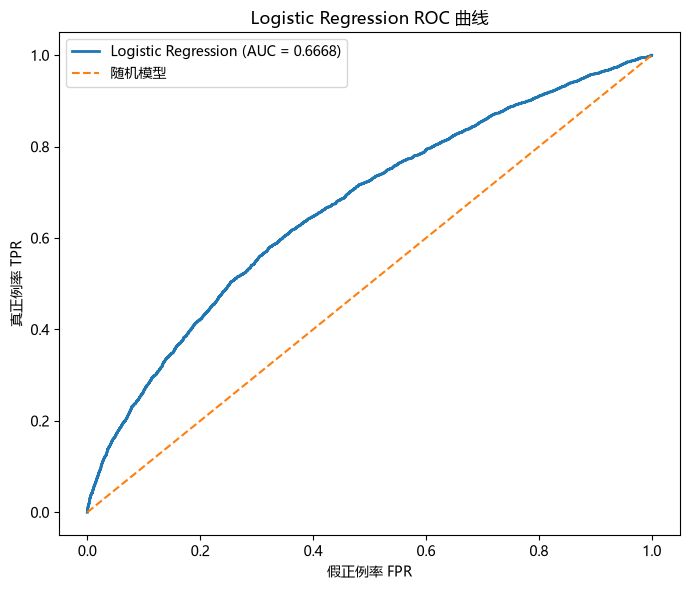

In [92]:
# ============================================================
# 88. Logistic Regression ROC 曲线
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_valid,
    lr_valid_prob
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.4f})"
)

# 随机模型参考线
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="随机模型"
)

ax.set_title(
    "Logistic Regression ROC 曲线"
)

ax.set_xlabel(
    "假正例率 FPR"
)

ax.set_ylabel(
    "真正例率 TPR"
)

ax.legend()

plt.tight_layout()
plt.show()

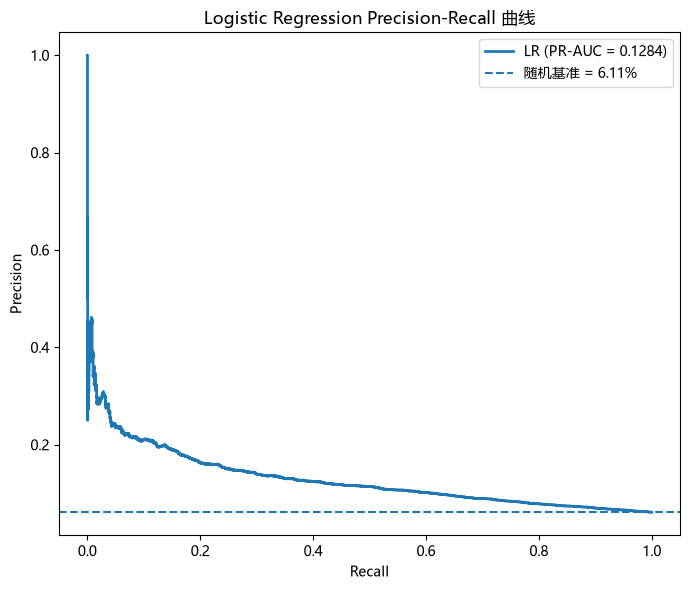

In [93]:
# ============================================================
# 89. Logistic Regression Precision-Recall 曲线
# ============================================================

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = (
    precision_recall_curve(
        y_valid,
        lr_valid_prob
    )
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    recall,
    precision,
    linewidth=2,
    label=f"LR (PR-AUC = {lr_pr_auc:.4f})"
)

# 随机模型基准线：
# 等于正样本比例
baseline_pr = y_valid.mean()

ax.axhline(
    baseline_pr,
    linestyle="--",
    linewidth=1.5,
    label=f"随机基准 = {baseline_pr:.2%}"
)

ax.set_title(
    "Logistic Regression Precision-Recall 曲线"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.legend()

plt.tight_layout()
plt.show()

In [94]:
# ============================================================
# 90. 建立模型效果对比表
# ============================================================

model_results = pd.DataFrame([
    {
        "模型": "Logistic Regression",
        "Accuracy": lr_accuracy,
        "Precision": lr_precision,
        "Recall": lr_recall,
        "F1": lr_f1,
        "ROC_AUC": lr_roc_auc,
        "PR_AUC": lr_pr_auc
    }
])

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

,模型,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9387,0.3871,0.0038,0.0075,0.6668,0.1284


In [95]:
# ============================================================
# 91. Balanced Logistic Regression
#
# 与普通 LR 的区别：
# class_weight="balanced"
#
# 模型会根据类别频率自动提高少数类（复购）的权重，
# 避免训练过程过度偏向占93.88%的未复购样本。
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_balanced_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                solver="lbfgs",

                # 核心区别
                class_weight="balanced",

                random_state=42
            )
        )
    ]
)

print("开始训练 Balanced Logistic Regression...")

lr_balanced_model.fit(
    X_train,
    y_train
)

print("✅ Balanced Logistic Regression 训练完成")

开始训练 Balanced Logistic Regression...
✅ Balanced Logistic Regression 训练完成


In [96]:
# ============================================================
# 92. Balanced Logistic Regression 评估
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# 预测概率
lr_balanced_prob = (
    lr_balanced_model
    .predict_proba(X_valid)[:, 1]
)

# 默认阈值0.5
lr_balanced_pred = (
    lr_balanced_prob >= 0.5
).astype(int)

# 各指标
balanced_accuracy = accuracy_score(
    y_valid,
    lr_balanced_pred
)

balanced_precision = precision_score(
    y_valid,
    lr_balanced_pred,
    zero_division=0
)

balanced_recall = recall_score(
    y_valid,
    lr_balanced_pred,
    zero_division=0
)

balanced_f1 = f1_score(
    y_valid,
    lr_balanced_pred,
    zero_division=0
)

balanced_roc_auc = roc_auc_score(
    y_valid,
    lr_balanced_prob
)

balanced_pr_auc = average_precision_score(
    y_valid,
    lr_balanced_prob
)

balanced_cm = confusion_matrix(
    y_valid,
    lr_balanced_pred
)


print("=" * 60)
print("Balanced Logistic Regression 验证集结果")
print("=" * 60)

print(f"Accuracy ：{balanced_accuracy:.4f}")
print(f"Precision：{balanced_precision:.4f}")
print(f"Recall   ：{balanced_recall:.4f}")
print(f"F1       ：{balanced_f1:.4f}")
print()
print(f"ROC-AUC  ：{balanced_roc_auc:.4f}")
print(f"PR-AUC   ：{balanced_pr_auc:.4f}")

print("\n混淆矩阵：")
print(balanced_cm)

Balanced Logistic Regression 验证集结果
Accuracy ：0.6837
Precision：0.1066
Recall   ：0.5655
F1       ：0.1794

ROC-AUC  ：0.6684
PR-AUC   ：0.1290

混淆矩阵：
[[33867 15116]
 [ 1386  1804]]


In [97]:
# ============================================================
# 93. 普通 LR vs Balanced LR
# ============================================================

balanced_result = pd.DataFrame([
    {
        "模型": "Balanced Logistic Regression",
        "Accuracy": balanced_accuracy,
        "Precision": balanced_precision,
        "Recall": balanced_recall,
        "F1": balanced_f1,
        "ROC_AUC": balanced_roc_auc,
        "PR_AUC": balanced_pr_auc
    }
])

model_results = pd.concat(
    [
        model_results,
        balanced_result
    ],
    ignore_index=True
)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

,模型,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9387,0.3871,0.0038,0.0075,0.6668,0.1284
1,Balanced Logistic Regression,0.6837,0.1066,0.5655,0.1794,0.6684,0.1290


In [98]:
model_results.to_csv(
    "model/model_results_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ LR 对比结果已保存")

✅ LR 对比结果已保存


In [99]:
# ============================================================
# 94. 清理模型结果表中的重复模型
# ============================================================

model_results = (
    model_results
    .drop_duplicates(
        subset=["模型"],
        keep="last"
    )
    .reset_index(drop=True)
)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

# 覆盖保存
model_results.to_csv(
    "model/model_results_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

,模型,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9387,0.3871,0.0038,0.0075,0.6668,0.1284
1,Balanced Logistic Regression,0.6837,0.1066,0.5655,0.1794,0.6684,0.1290


In [100]:
# ============================================================
# 95. Random Forest Baseline
#
# 目的：
# 使用树模型捕捉 Logistic Regression 无法表达的：
#
# - 非线性关系
# - 特征之间的交互作用
#
# 第一版使用较保守的参数：
# n_estimators = 100
# max_depth = 8
#
# 先建立基准，再决定是否需要继续调参。
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    # 100棵决策树
    n_estimators=100,

    # 限制树深，避免单棵树过度拟合
    max_depth=8,

    # 使用全部CPU核心并行训练
    n_jobs=-1,

    # 固定随机种子
    random_state=42,

    # 显示训练进度
    verbose=1
)

print("开始训练 Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("✅ Random Forest 训练完成")

开始训练 Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.7s


✅ Random Forest 训练完成


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.7s finished


In [101]:
# ============================================================
# 96. Random Forest 模型评估
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. 预测复购概率
# ------------------------------------------------------------

rf_valid_prob = rf_model.predict_proba(
    X_valid
)[:, 1]


# ------------------------------------------------------------
# 2. 默认0.5阈值预测类别
# ------------------------------------------------------------

rf_valid_pred = (
    rf_valid_prob >= 0.5
).astype(int)


# ------------------------------------------------------------
# 3. 各项指标
# ------------------------------------------------------------

rf_accuracy = accuracy_score(
    y_valid,
    rf_valid_pred
)

rf_precision = precision_score(
    y_valid,
    rf_valid_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_valid,
    rf_valid_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_valid,
    rf_valid_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_valid,
    rf_valid_prob
)

rf_pr_auc = average_precision_score(
    y_valid,
    rf_valid_prob
)

rf_cm = confusion_matrix(
    y_valid,
    rf_valid_pred
)


# ------------------------------------------------------------
# 4. 输出结果
# ------------------------------------------------------------

print("=" * 60)
print("Random Forest 验证集结果")
print("=" * 60)

print(f"Accuracy ：{rf_accuracy:.4f}")
print(f"Precision：{rf_precision:.4f}")
print(f"Recall   ：{rf_recall:.4f}")
print(f"F1       ：{rf_f1:.4f}")

print()

print(f"ROC-AUC  ：{rf_roc_auc:.4f}")
print(f"PR-AUC   ：{rf_pr_auc:.4f}")

print("\n混淆矩阵：")
print(rf_cm)

Random Forest 验证集结果
Accuracy ：0.9389
Precision：0.0000
Recall   ：0.0000
F1       ：0.0000

ROC-AUC  ：0.6647
PR-AUC   ：0.1303

混淆矩阵：
[[48983     0]
 [ 3190     0]]


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


In [102]:
# ============================================================
# 97. 将 Random Forest 加入模型结果表
# ============================================================

rf_result = pd.DataFrame([
    {
        "模型": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1": rf_f1,
        "ROC_AUC": rf_roc_auc,
        "PR_AUC": rf_pr_auc
    }
])

model_results = pd.concat(
    [
        model_results,
        rf_result
    ],
    ignore_index=True
)

# 防止某个 Cell 被重复执行导致模型重复
model_results = (
    model_results
    .drop_duplicates(
        subset=["模型"],
        keep="last"
    )
    .reset_index(drop=True)
)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

model_results.to_csv(
    "model/model_results_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

,模型,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9387,0.3871,0.0038,0.0075,0.6668,0.1284
1,Balanced Logistic Regression,0.6837,0.1066,0.5655,0.1794,0.6684,0.1290
2,Random Forest,0.9389,0.0000,0.0000,0.0000,0.6647,0.1303


In [103]:
# ============================================================
# 98. Random Forest 特征重要性
# ============================================================

rf_feature_importance = pd.DataFrame({
    "特征": final_feature_names,
    "重要性": rf_model.feature_importances_
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        "重要性",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Random Forest 最重要的前20个特征：")

display(
    rf_feature_importance.head(20)
)

Random Forest 最重要的前20个特征：


,特征,重要性
0,merchant_repeat_buyer_rate,0.086757
1,um_cat_count,0.034923
2,um_item_count,0.033233
3,um_click_item_count,0.030510
4,merchant_repeat_buyer_count,0.030445
5,um_total_action_count,0.028180
6,um_cart_to_buy_logratio,0.024442
7,um_buy_count,0.023147
8,um_buy_item_count,0.021942
9,um_click_count,0.020882


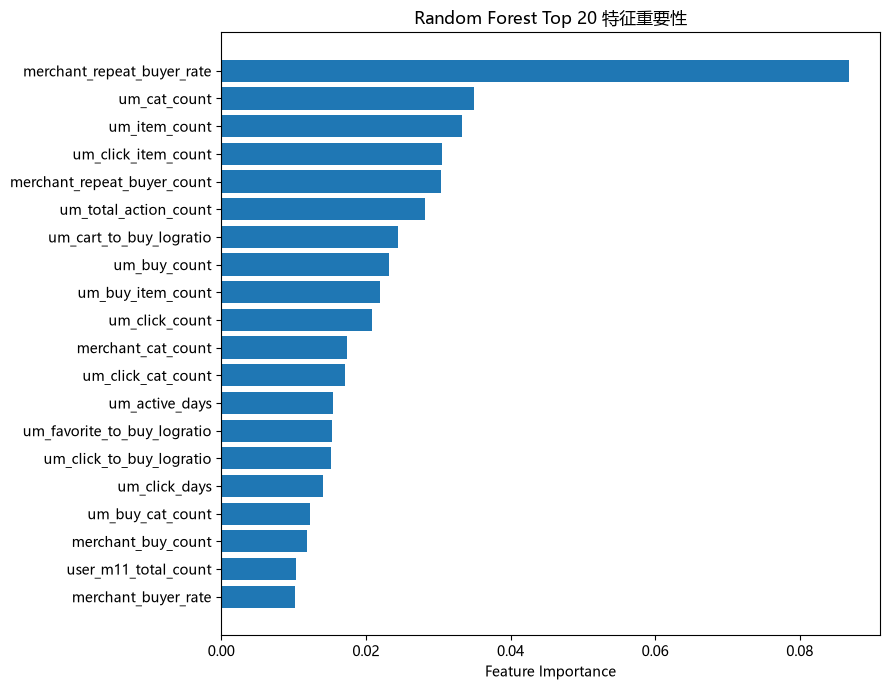

In [104]:
# ============================================================
# 99. Random Forest Top 20 特征重要性
# ============================================================

import matplotlib.pyplot as plt

top20 = rf_feature_importance.head(20).sort_values(
    "重要性",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.barh(
    top20["特征"],
    top20["重要性"]
)

ax.set_title(
    "Random Forest Top 20 特征重要性"
)

ax.set_xlabel(
    "Feature Importance"
)

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# 100. AdaBoost Baseline
#
# 原理：
# 多个弱分类器依次训练，
# 后续模型更加关注前面预测错误的样本。
#
# 第一版使用：
# n_estimators = 50
# learning_rate = 1.0
#
# 先复刻基础版本，不急着调参。
# ============================================================

from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    # 弱分类器数量
    n_estimators=50,

    # 每一轮模型贡献的学习率
    learning_rate=1.0,

    # 固定随机种子
    random_state=42
)

print("开始训练 AdaBoost...")

ada_model.fit(
    X_train,
    y_train
)

print("✅ AdaBoost 训练完成")

开始训练 AdaBoost...
✅ AdaBoost 训练完成


In [106]:
# ============================================================
# 101. AdaBoost 模型评估
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. 预测复购概率
# ------------------------------------------------------------

ada_valid_prob = ada_model.predict_proba(
    X_valid
)[:, 1]


# ------------------------------------------------------------
# 2. 默认0.5阈值
# ------------------------------------------------------------

ada_valid_pred = (
    ada_valid_prob >= 0.5
).astype(int)


# ------------------------------------------------------------
# 3. 计算指标
# ------------------------------------------------------------

ada_accuracy = accuracy_score(
    y_valid,
    ada_valid_pred
)

ada_precision = precision_score(
    y_valid,
    ada_valid_pred,
    zero_division=0
)

ada_recall = recall_score(
    y_valid,
    ada_valid_pred,
    zero_division=0
)

ada_f1 = f1_score(
    y_valid,
    ada_valid_pred,
    zero_division=0
)

ada_roc_auc = roc_auc_score(
    y_valid,
    ada_valid_prob
)

ada_pr_auc = average_precision_score(
    y_valid,
    ada_valid_prob
)

ada_cm = confusion_matrix(
    y_valid,
    ada_valid_pred
)


# ------------------------------------------------------------
# 4. 输出结果
# ------------------------------------------------------------

print("=" * 60)
print("AdaBoost 验证集结果")
print("=" * 60)

print(f"Accuracy ：{ada_accuracy:.4f}")
print(f"Precision：{ada_precision:.4f}")
print(f"Recall   ：{ada_recall:.4f}")
print(f"F1       ：{ada_f1:.4f}")

print()

print(f"ROC-AUC  ：{ada_roc_auc:.4f}")
print(f"PR-AUC   ：{ada_pr_auc:.4f}")

print("\n混淆矩阵：")
print(ada_cm)

AdaBoost 验证集结果
Accuracy ：0.9389
Precision：0.0000
Recall   ：0.0000
F1       ：0.0000

ROC-AUC  ：0.6655
PR-AUC   ：0.1248

混淆矩阵：
[[48983     0]
 [ 3190     0]]


In [107]:
# ============================================================
# 102. 将 AdaBoost 加入模型结果表
# ============================================================

ada_result = pd.DataFrame([
    {
        "模型": "AdaBoost",
        "Accuracy": ada_accuracy,
        "Precision": ada_precision,
        "Recall": ada_recall,
        "F1": ada_f1,
        "ROC_AUC": ada_roc_auc,
        "PR_AUC": ada_pr_auc
    }
])

model_results = pd.concat(
    [
        model_results,
        ada_result
    ],
    ignore_index=True
)

# 防止重复运行 Cell 产生重复模型
model_results = (
    model_results
    .drop_duplicates(
        subset=["模型"],
        keep="last"
    )
    .reset_index(drop=True)
)

# 按 ROC-AUC 从高到低排序
model_results = (
    model_results
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

model_results.to_csv(
    "model/model_results_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

,模型,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Balanced Logistic Regression,0.6837,0.1066,0.5655,0.1794,0.6684,0.1290
1,Logistic Regression,0.9387,0.3871,0.0038,0.0075,0.6668,0.1284
2,AdaBoost,0.9389,0.0000,0.0000,0.0000,0.6655,0.1248
3,Random Forest,0.9389,0.0000,0.0000,0.0000,0.6647,0.1303


In [109]:
# ============================================================
# 103. AdaBoost 特征重要性
# ============================================================

ada_feature_importance = pd.DataFrame({
    "特征": final_feature_names,
    "重要性": ada_model.feature_importances_
})

ada_feature_importance = (
    ada_feature_importance
    .sort_values(
        "重要性",
        ascending=False
    )
    .reset_index(drop=True)
)

print("AdaBoost 最重要的前20个特征：")

display(
    ada_feature_importance.head(20)
)

AdaBoost 最重要的前20个特征：


,特征,重要性
0,merchant_repeat_buyer_rate,0.626567
1,um_item_count,0.117743
2,user_repeat_merchant_rate,0.034902
3,um_cart_to_buy_logratio,0.031218
4,merchant_click_to_buy,0.025877
5,um_cat_count,0.024354
6,merchant_item_count,0.019603
7,um_active_days,0.016860
8,user_pre11_buy_merchant_count,0.014457
9,merchant_cat_count,0.013755


In [110]:
# ============================================================
# 104. Linear SVM
#
# 对应原教程：
# - Linear Kernel
# - L2 penalty
# - max_iter = 1000
#
# 使用 LinearSVC 更适合当前 20 万+ 样本规模。
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

svm_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LinearSVC(
                penalty="l2",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("开始训练 Linear SVM...")

svm_model.fit(
    X_train,
    y_train
)

print("✅ Linear SVM 训练完成")

开始训练 Linear SVM...
✅ Linear SVM 训练完成


In [111]:
# ============================================================
# 105. Linear SVM 评估
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. SVM 决策分数
# ------------------------------------------------------------

svm_valid_score = svm_model.decision_function(
    X_valid
)

# LinearSVC 默认以0作为分类边界
svm_valid_pred = svm_model.predict(
    X_valid
)


# ------------------------------------------------------------
# 2. 计算指标
# ------------------------------------------------------------

svm_accuracy = accuracy_score(
    y_valid,
    svm_valid_pred
)

svm_precision = precision_score(
    y_valid,
    svm_valid_pred,
    zero_division=0
)

svm_recall = recall_score(
    y_valid,
    svm_valid_pred,
    zero_division=0
)

svm_f1 = f1_score(
    y_valid,
    svm_valid_pred,
    zero_division=0
)

svm_roc_auc = roc_auc_score(
    y_valid,
    svm_valid_score
)

svm_pr_auc = average_precision_score(
    y_valid,
    svm_valid_score
)

svm_cm = confusion_matrix(
    y_valid,
    svm_valid_pred
)


print("=" * 60)
print("Linear SVM 验证集结果")
print("=" * 60)

print(f"Accuracy ：{svm_accuracy:.4f}")
print(f"Precision：{svm_precision:.4f}")
print(f"Recall   ：{svm_recall:.4f}")
print(f"F1       ：{svm_f1:.4f}")
print()
print(f"ROC-AUC  ：{svm_roc_auc:.4f}")
print(f"PR-AUC   ：{svm_pr_auc:.4f}")

print("\n混淆矩阵：")
print(svm_cm)

Linear SVM 验证集结果
Accuracy ：0.9389
Precision：0.5000
Recall   ：0.0009
F1       ：0.0019

ROC-AUC  ：0.6680
PR-AUC   ：0.1301

混淆矩阵：
[[48980     3]
 [ 3187     3]]


In [112]:
# ============================================================
# 106. Linear SVM 加入模型结果表
# ============================================================

svm_result = pd.DataFrame([
    {
        "模型": "Linear SVM",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1": svm_f1,
        "ROC_AUC": svm_roc_auc,
        "PR_AUC": svm_pr_auc
    }
])

model_results = pd.concat(
    [
        model_results,
        svm_result
    ],
    ignore_index=True
)

model_results = (
    model_results
    .drop_duplicates(
        subset=["模型"],
        keep="last"
    )
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

model_results.to_csv(
    "model/model_results_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

,模型,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Balanced Logistic Regression,0.6837,0.1066,0.5655,0.1794,0.6684,0.1290
1,Linear SVM,0.9389,0.5000,0.0009,0.0019,0.6680,0.1301
2,Logistic Regression,0.9387,0.3871,0.0038,0.0075,0.6668,0.1284
3,AdaBoost,0.9389,0.0000,0.0000,0.0000,0.6655,0.1248
4,Random Forest,0.9389,0.0000,0.0000,0.0000,0.6647,0.1303


In [113]:
# ============================================================
# 107. MLP 神经网络 - Adam
#
# 结构：
# 输入层：143个特征
# 隐藏层：700个神经元
# 激活函数：ReLU
# 优化器：Adam
# 初始学习率：0.001
# 最大迭代次数：200
#
# MLP 对特征量纲敏感，因此必须标准化。
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

mlp_adam_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(700,),
                activation="relu",
                solver="adam",
                learning_rate_init=0.001,
                max_iter=200,
                random_state=42,

                # 不打印每一轮训练日志，避免输出太长
                verbose=False
            )
        )
    ]
)

print("开始训练 MLP - Adam...")

mlp_adam_model.fit(
    X_train,
    y_train
)

print("✅ MLP - Adam 训练完成")

开始训练 MLP - Adam...
✅ MLP - Adam 训练完成


d:\桌面\天猫复购预测\TMALL_Repurchase\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [114]:
# ============================================================
# 108. MLP - Adam 模型评估
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. 预测复购概率
# ------------------------------------------------------------

mlp_adam_prob = (
    mlp_adam_model
    .predict_proba(X_valid)[:, 1]
)

# 默认0.5阈值
mlp_adam_pred = (
    mlp_adam_prob >= 0.5
).astype(int)


# ------------------------------------------------------------
# 2. 指标
# ------------------------------------------------------------

mlp_adam_accuracy = accuracy_score(
    y_valid,
    mlp_adam_pred
)

mlp_adam_precision = precision_score(
    y_valid,
    mlp_adam_pred,
    zero_division=0
)

mlp_adam_recall = recall_score(
    y_valid,
    mlp_adam_pred,
    zero_division=0
)

mlp_adam_f1 = f1_score(
    y_valid,
    mlp_adam_pred,
    zero_division=0
)

mlp_adam_roc_auc = roc_auc_score(
    y_valid,
    mlp_adam_prob
)

mlp_adam_pr_auc = average_precision_score(
    y_valid,
    mlp_adam_prob
)

mlp_adam_cm = confusion_matrix(
    y_valid,
    mlp_adam_pred
)


# ------------------------------------------------------------
# 3. 输出
# ------------------------------------------------------------

print("=" * 60)
print("MLP - Adam 验证集结果")
print("=" * 60)

print(f"Accuracy ：{mlp_adam_accuracy:.4f}")
print(f"Precision：{mlp_adam_precision:.4f}")
print(f"Recall   ：{mlp_adam_recall:.4f}")
print(f"F1       ：{mlp_adam_f1:.4f}")
print()
print(f"ROC-AUC  ：{mlp_adam_roc_auc:.4f}")
print(f"PR-AUC   ：{mlp_adam_pr_auc:.4f}")

print("\n混淆矩阵：")
print(mlp_adam_cm)

MLP - Adam 验证集结果
Accuracy ：0.9096
Precision：0.1226
Recall   ：0.0777
F1       ：0.0951

ROC-AUC  ：0.5592
PR-AUC   ：0.0819

混淆矩阵：
[[47208  1775]
 [ 2942   248]]


In [115]:
# ============================================================
# 109. MLP - Adam 加入模型对比表
# ============================================================

mlp_adam_result = pd.DataFrame([
    {
        "模型": "MLP - Adam",
        "Accuracy": mlp_adam_accuracy,
        "Precision": mlp_adam_precision,
        "Recall": mlp_adam_recall,
        "F1": mlp_adam_f1,
        "ROC_AUC": mlp_adam_roc_auc,
        "PR_AUC": mlp_adam_pr_auc
    }
])

model_results = pd.concat(
    [
        model_results,
        mlp_adam_result
    ],
    ignore_index=True
)

model_results = (
    model_results
    .drop_duplicates(
        subset=["模型"],
        keep="last"
    )
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

,模型,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Balanced Logistic Regression,0.6837,0.1066,0.5655,0.1794,0.6684,0.1290
1,Linear SVM,0.9389,0.5000,0.0009,0.0019,0.6680,0.1301
2,Logistic Regression,0.9387,0.3871,0.0038,0.0075,0.6668,0.1284
3,AdaBoost,0.9389,0.0000,0.0000,0.0000,0.6655,0.1248
4,Random Forest,0.9389,0.0000,0.0000,0.0000,0.6647,0.1303
5,MLP - Adam,0.9096,0.1226,0.0777,0.0951,0.5592,0.0819


In [116]:
# ============================================================
# 110. MLP 神经网络 - SGD
#
# 与 Adam 版保持相同网络结构：
# - 700个隐藏神经元
# - ReLU
# - learning_rate_init = 0.001
# - max_iter = 200
#
# 唯一区别：
# solver = "sgd"
# ============================================================

mlp_sgd_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(700,),
                activation="relu",
                solver="sgd",
                learning_rate_init=0.001,
                max_iter=200,
                random_state=42,
                verbose=False
            )
        )
    ]
)

print("开始训练 MLP - SGD...")

mlp_sgd_model.fit(
    X_train,
    y_train
)

print("✅ MLP - SGD 训练完成")

开始训练 MLP - SGD...
✅ MLP - SGD 训练完成


d:\桌面\天猫复购预测\TMALL_Repurchase\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [117]:
# ============================================================
# 111. MLP - SGD 模型评估
# ============================================================

mlp_sgd_prob = (
    mlp_sgd_model
    .predict_proba(X_valid)[:, 1]
)

mlp_sgd_pred = (
    mlp_sgd_prob >= 0.5
).astype(int)

mlp_sgd_accuracy = accuracy_score(
    y_valid,
    mlp_sgd_pred
)

mlp_sgd_precision = precision_score(
    y_valid,
    mlp_sgd_pred,
    zero_division=0
)

mlp_sgd_recall = recall_score(
    y_valid,
    mlp_sgd_pred,
    zero_division=0
)

mlp_sgd_f1 = f1_score(
    y_valid,
    mlp_sgd_pred,
    zero_division=0
)

mlp_sgd_roc_auc = roc_auc_score(
    y_valid,
    mlp_sgd_prob
)

mlp_sgd_pr_auc = average_precision_score(
    y_valid,
    mlp_sgd_prob
)

mlp_sgd_cm = confusion_matrix(
    y_valid,
    mlp_sgd_pred
)


print("=" * 60)
print("MLP - SGD 验证集结果")
print("=" * 60)

print(f"Accuracy ：{mlp_sgd_accuracy:.4f}")
print(f"Precision：{mlp_sgd_precision:.4f}")
print(f"Recall   ：{mlp_sgd_recall:.4f}")
print(f"F1       ：{mlp_sgd_f1:.4f}")
print()
print(f"ROC-AUC  ：{mlp_sgd_roc_auc:.4f}")
print(f"PR-AUC   ：{mlp_sgd_pr_auc:.4f}")

print("\n混淆矩阵：")
print(mlp_sgd_cm)

MLP - SGD 验证集结果
Accuracy ：0.9378
Precision：0.2891
Recall   ：0.0116
F1       ：0.0223

ROC-AUC  ：0.6525
PR-AUC   ：0.1217

混淆矩阵：
[[48892    91]
 [ 3153    37]]


In [118]:
# ============================================================
# 112. MLP - SGD 加入模型结果表
# ============================================================

mlp_sgd_result = pd.DataFrame([
    {
        "模型": "MLP - SGD",
        "Accuracy": mlp_sgd_accuracy,
        "Precision": mlp_sgd_precision,
        "Recall": mlp_sgd_recall,
        "F1": mlp_sgd_f1,
        "ROC_AUC": mlp_sgd_roc_auc,
        "PR_AUC": mlp_sgd_pr_auc
    }
])

model_results = pd.concat(
    [
        model_results,
        mlp_sgd_result
    ],
    ignore_index=True
)

model_results = (
    model_results
    .drop_duplicates(
        subset=["模型"],
        keep="last"
    )
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

model_results.to_csv(
    "model/model_results_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ MLP 模型结果已保存")

,模型,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Balanced Logistic Regression,0.6837,0.1066,0.5655,0.1794,0.6684,0.1290
1,Linear SVM,0.9389,0.5000,0.0009,0.0019,0.6680,0.1301
2,Logistic Regression,0.9387,0.3871,0.0038,0.0075,0.6668,0.1284
3,AdaBoost,0.9389,0.0000,0.0000,0.0000,0.6655,0.1248
4,Random Forest,0.9389,0.0000,0.0000,0.0000,0.6647,0.1303
5,MLP - SGD,0.9378,0.2891,0.0116,0.0223,0.6525,0.1217
6,MLP - Adam,0.9096,0.1226,0.0777,0.0951,0.5592,0.0819


✅ MLP 模型结果已保存


In [119]:
# ============================================================
# 113. 检查 XGBoost 环境
# ============================================================

try:
    import xgboost as xgb

    print("✅ XGBoost 已安装")
    print("XGBoost 版本：", xgb.__version__)

except ModuleNotFoundError:
    print("❌ 当前环境还没有安装 XGBoost")

✅ XGBoost 已安装
XGBoost 版本： 3.4.1


In [120]:
# ============================================================
# 114. XGBoost Baseline
#
# 主要按照原教程参数：
# n_estimators = 300
# max_depth = 8
# learning_rate = 0.1
#
# tree_method="hist"：
# 使用现代直方图算法，提高CPU训练速度。
#
# 本轮先不处理类别权重，
# 目的是得到和原教程思路一致的基础 XGBoost。
# ============================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    # 树的数量
    n_estimators=300,

    # 每棵树最大深度
    max_depth=8,

    # 学习率
    learning_rate=0.1,

    # 二分类概率输出
    objective="binary:logistic",

    # 训练过程中使用AUC作为评估指标
    eval_metric="auc",

    # 更适合当前数据量的快速树构建方式
    tree_method="hist",

    # 使用全部CPU核心
    n_jobs=-1,

    # 固定随机种子
    random_state=42
)

print("开始训练 XGBoost...")

xgb_model.fit(
    X_train,
    y_train,

    # 让模型同时计算训练集和验证集表现
    eval_set=[
        (X_train, y_train),
        (X_valid, y_valid)
    ],

    # 不逐轮打印300行日志
    verbose=False
)

print("✅ XGBoost 训练完成")

开始训练 XGBoost...
✅ XGBoost 训练完成


In [121]:
# ============================================================
# 115. XGBoost 验证集评估
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. 预测复购概率
# ------------------------------------------------------------

xgb_valid_prob = (
    xgb_model
    .predict_proba(X_valid)[:, 1]
)

# 默认0.5阈值
xgb_valid_pred = (
    xgb_valid_prob >= 0.5
).astype(int)


# ------------------------------------------------------------
# 2. 计算指标
# ------------------------------------------------------------

xgb_accuracy = accuracy_score(
    y_valid,
    xgb_valid_pred
)

xgb_precision = precision_score(
    y_valid,
    xgb_valid_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_valid,
    xgb_valid_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_valid,
    xgb_valid_pred,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_valid,
    xgb_valid_prob
)

xgb_pr_auc = average_precision_score(
    y_valid,
    xgb_valid_prob
)

xgb_cm = confusion_matrix(
    y_valid,
    xgb_valid_pred
)


# ------------------------------------------------------------
# 3. 输出
# ------------------------------------------------------------

print("=" * 60)
print("XGBoost 验证集结果")
print("=" * 60)

print(f"Accuracy ：{xgb_accuracy:.4f}")
print(f"Precision：{xgb_precision:.4f}")
print(f"Recall   ：{xgb_recall:.4f}")
print(f"F1       ：{xgb_f1:.4f}")

print()

print(f"ROC-AUC  ：{xgb_roc_auc:.4f}")
print(f"PR-AUC   ：{xgb_pr_auc:.4f}")

print("\n混淆矩阵：")
print(xgb_cm)

XGBoost 验证集结果
Accuracy ：0.9387
Precision：0.3750
Recall   ：0.0038
F1       ：0.0074

ROC-AUC  ：0.6632
PR-AUC   ：0.1261

混淆矩阵：
[[48963    20]
 [ 3178    12]]


In [122]:
# ============================================================
# 116. XGBoost 加入模型结果表
# ============================================================

xgb_result = pd.DataFrame([
    {
        "模型": "XGBoost",
        "Accuracy": xgb_accuracy,
        "Precision": xgb_precision,
        "Recall": xgb_recall,
        "F1": xgb_f1,
        "ROC_AUC": xgb_roc_auc,
        "PR_AUC": xgb_pr_auc
    }
])

model_results = pd.concat(
    [
        model_results,
        xgb_result
    ],
    ignore_index=True
)

# 防止重复运行
model_results = (
    model_results
    .drop_duplicates(
        subset=["模型"],
        keep="last"
    )
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

model_results.to_csv(
    "model/model_results_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ XGBoost 结果已保存")

,模型,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Balanced Logistic Regression,0.6837,0.1066,0.5655,0.1794,0.6684,0.1290
1,Linear SVM,0.9389,0.5000,0.0009,0.0019,0.6680,0.1301
2,Logistic Regression,0.9387,0.3871,0.0038,0.0075,0.6668,0.1284
3,AdaBoost,0.9389,0.0000,0.0000,0.0000,0.6655,0.1248
4,Random Forest,0.9389,0.0000,0.0000,0.0000,0.6647,0.1303
5,XGBoost,0.9387,0.3750,0.0038,0.0074,0.6632,0.1261
6,MLP - SGD,0.9378,0.2891,0.0116,0.0223,0.6525,0.1217
7,MLP - Adam,0.9096,0.1226,0.0777,0.0951,0.5592,0.0819


✅ XGBoost 结果已保存


In [123]:
# ============================================================
# 117. XGBoost Top 20 特征重要性
# ============================================================

xgb_feature_importance = pd.DataFrame({
    "特征": final_feature_names,
    "重要性": xgb_model.feature_importances_
})

xgb_feature_importance = (
    xgb_feature_importance
    .sort_values(
        "重要性",
        ascending=False
    )
    .reset_index(drop=True)
)

print("XGBoost 最重要的前20个特征：")

display(
    xgb_feature_importance.head(20)
)

XGBoost 最重要的前20个特征：


,特征,重要性
0,um_cart_to_buy_logratio,0.054964
1,merchant_repeat_buyer_rate,0.024027
2,um_item_count,0.016098
3,um_cat_count,0.015901
4,um_buy_item_count,0.012846
5,um_favorite_brand_count,0.010130
6,um_active_days,0.010108
7,merchant_cat_count,0.009860
8,age_8,0.009381
9,merchant_buy_action_ratio,0.009325


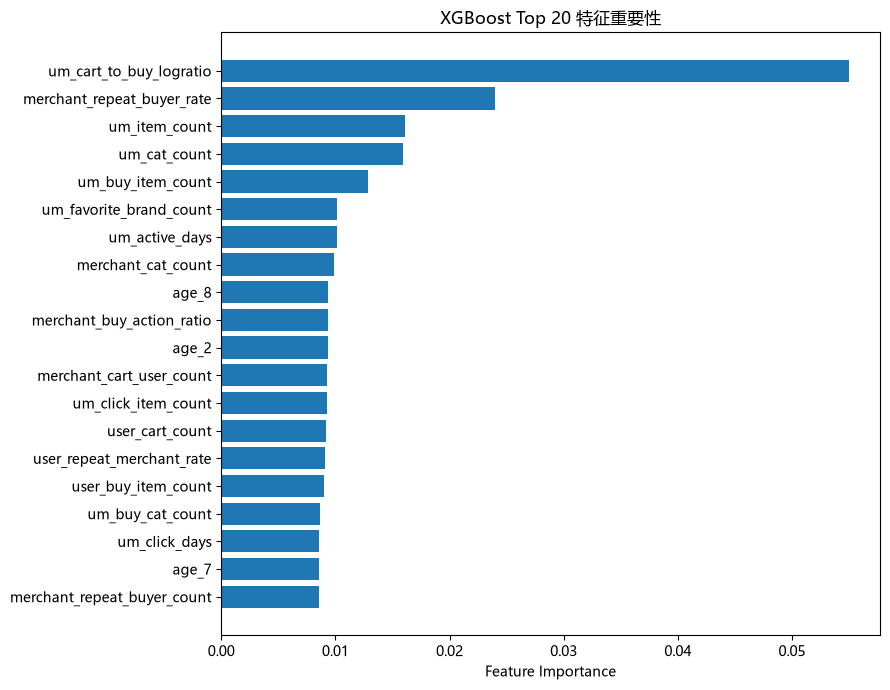

In [124]:
# ============================================================
# 118. XGBoost Top 20 特征重要性图
# ============================================================

import matplotlib.pyplot as plt

top20_xgb = (
    xgb_feature_importance
    .head(20)
    .sort_values(
        "重要性",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.barh(
    top20_xgb["特征"],
    top20_xgb["重要性"]
)

ax.set_title(
    "XGBoost Top 20 特征重要性"
)

ax.set_xlabel(
    "Feature Importance"
)

plt.tight_layout()
plt.show()